In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import json

motivational = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/motivational_results.xlsx", sheet_name=0)
motivational_v3 = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/motivational_results-v3.xlsx", sheet_name=0)
max_iops = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/all_top1_libaio_iops_results.xlsx", sheet_name=0)

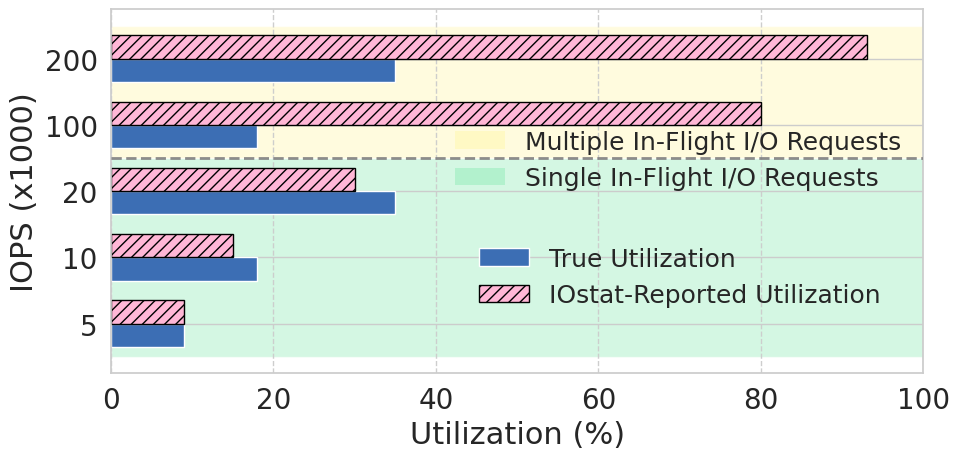

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -------------------------------------------------
# FONT SIZE OPTIONS
# -------------------------------------------------
X_LABEL_FONTSIZE = 22
Y_LABEL_FONTSIZE = 22
X_TICK_FONTSIZE = 20
Y_TICK_FONTSIZE = 20
LEGEND_FONTSIZE = 18

# -------------------------------------------------
# LEGEND POSITION OPTIONS
# -------------------------------------------------
# Legend 1 (True vs Iostat)
LEGEND1_LOC = "lower center"
LEGEND1_BBOX = (0.7, 0.12)     # move below plot

# Legend 2 (Single vs Multi background bands)
LEGEND2_LOC = "upper right"
LEGEND2_BBOX = (1.0, 0.73)      # move outside right side

# -------------------------------------------------
# BACKGROUND COLORS (CUSTOMIZABLE)
# -------------------------------------------------
SINGLE_BG_COLOR = "#b2f1cd"   # light blue background
MULTI_BG_COLOR  = "#fff9c4"   # light orange background

# -------------------------------------------------
# AXIS RANGE OPTIONS
# -------------------------------------------------
X_MIN = 0
X_MAX = 100
X_TICKS = [0, 20, 40, 60, 80, 100]
Y_LABELS = None   # default uses the IOPS labels

# -------------------------------------------------
# INPUT DATA
# -------------------------------------------------
iops_levels_single = ["5", "10", "20"]
true_single = [9, 18, 35]
iostat_single = [9, 15, 30]

iops_levels_multi = ["100", "200"]
true_multi = [18, 35]
iostat_multi = [80, 93]

labels = iops_levels_single + iops_levels_multi
true_vals = true_single + true_multi
iostat_vals = iostat_single + iostat_multi

n_single = len(iops_levels_single)
n_total = len(labels)

# -------------------------------------------------
# FIGURE SETUP
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
plt.rcParams.update({"font.size": 20})

index = np.arange(n_total)
bar_height = 0.35

# -------------------------------------------------
# COLORS
# -------------------------------------------------
true_color = "#3C6EB4"
iostat_color = "#ffb7d6"

# -------------------------------------------------
# BACKGROUND SHADING
# -------------------------------------------------
ax.axhspan(-0.5, n_single - 0.5,
           facecolor=SINGLE_BG_COLOR, alpha=0.55, zorder=0)

ax.axhspan(n_single - 0.5, n_total - 0.5,
           facecolor=MULTI_BG_COLOR, alpha=0.55, zorder=0)

# -------------------------------------------------
# DOTTED LINE BETWEEN 20k AND 100k ROWS
# -------------------------------------------------
separator_y = n_single - 0.5   # = 2.5
ax.axhline(separator_y, color="gray", linestyle="--",
           linewidth=2, alpha=0.9, zorder=10)

# -------------------------------------------------
# DRAW BARS
# -------------------------------------------------
ax.barh(index - bar_height/2, true_vals, height=bar_height,
        label="True Utilization", color=true_color, zorder=2)

ax.barh(index + bar_height/2, iostat_vals, height=bar_height,
        label="IOstat-Reported Utilization",
        color=iostat_color, edgecolor="black", hatch="///", zorder=2)

# -------------------------------------------------
# LEGEND 1: True vs Iostat
# -------------------------------------------------
leg1 = ax.legend(
    ncol=1, loc=LEGEND1_LOC,
    bbox_to_anchor=LEGEND1_BBOX,
    fontsize=LEGEND_FONTSIZE,
    frameon=False
)

# -------------------------------------------------
# LEGEND 2: Single vs Multi (background legend)
# -------------------------------------------------
single_patch = Patch(facecolor=SINGLE_BG_COLOR, edgecolor="none",
                     label="Single In-Flight I/O Requests")
multi_patch = Patch(facecolor=MULTI_BG_COLOR, edgecolor="none",
                    label="Multiple In-Flight I/O Requests")

leg2 = ax.legend(
    ncol=1, handles=[multi_patch, single_patch],
    loc=LEGEND2_LOC,
    bbox_to_anchor=LEGEND2_BBOX,
    fontsize=LEGEND_FONTSIZE,
    frameon=False
)

ax.add_artist(leg1)  # keep both legends

# -------------------------------------------------
# AXES & LABELS
# -------------------------------------------------
ax.set_xlabel("Utilization (%)", fontsize=X_LABEL_FONTSIZE)
ax.set_ylabel("IOPS (x1000)", fontsize=Y_LABEL_FONTSIZE)

ax.set_xticks(X_TICKS)
ax.set_xticklabels(X_TICKS, fontsize=X_TICK_FONTSIZE)

ax.set_yticks(index)
ax.set_yticklabels(Y_LABELS if Y_LABELS else labels, fontsize=Y_TICK_FONTSIZE)

ax.set_xlim(X_MIN, X_MAX)

ax.grid(axis="x", linestyle="--", alpha=0.95, zorder=5)

plt.tight_layout()

# -------------------------------------------------
# SAVE PDF OUTPUT
# -------------------------------------------------
fig.savefig("summarized_motiv.pdf", format="pdf", bbox_inches="tight")

plt.show()


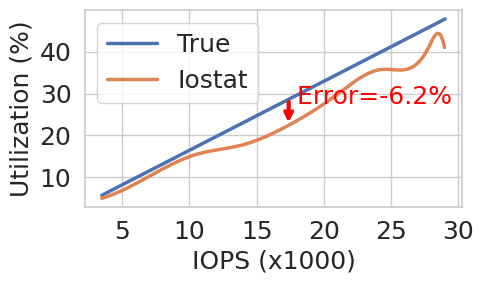

PDF saved as: motivational_results_optane_4k_randread.pdf


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages

# -------------------------------------------------------------
# SIMPLE BEAUTIFUL STYLE (no latex at all)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZE CONFIGURATION (CHANGE THESE)
# -------------------------------------------------------------
TITLE_FONTSIZE = 20
AXIS_LABEL_FONTSIZE = 18
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 18
ERROR_TEXT_FONTSIZE = 18

# -------------------------------------------------------------
# Choose which point gets the error arrow
# -------------------------------------------------------------
error_point_index = 4

# -------------------------------------------------------------
# Load data
# -------------------------------------------------------------
df = pd.read_excel(
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/motivational_results_optane_4k_randread.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/motivational_results_optane_4k_randwrite.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/motivational_results_optane_4k_randread-v2.xlsx",
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/motivational_results_optane_4k_randwrite-v2.xlsx",
    sheet_name=0,
)

devices = df["job options/filename"].unique()
pdf = PdfPages("motivational_results_optane_4k_randwrite_low.pdf")

# -------------------------------------------------------------
# Smooth curve helper
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.array(x)
    y = np.array(y)
    if len(x) < 4:
        return x, y
    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------------
for device in devices:
    plt.figure(figsize=(5, 3))
    ddf = df[df["job options/filename"] == device]

    for rw in ddf["job options/rw"].unique():
        wdf = ddf[ddf["job options/rw"] == rw].sort_values("limitation")

        fio_iops = (wdf["read/iops"] + wdf["write/iops"]) / 1000
        true_util = wdf["limitation"]

        iostat_iops = (wdf["avg_rps"] + wdf["avg_wps"]) / 1000
        iostat_util = wdf["avg_util"]

        # Smooth curves
        sx1, sy1 = smooth_curve(fio_iops, true_util)
        sx2, sy2 = smooth_curve(iostat_iops, iostat_util)

        plt.plot(sx1, sy1, label="True", linewidth=2.5)
        plt.plot(sx2, sy2, label="Iostat", linewidth=2.5)

        # ---------------------------------------------------------
        # ONE ERROR ARROW
        # ---------------------------------------------------------
        if error_point_index < len(fio_iops):
            x1 = float(fio_iops.iloc[error_point_index])
            y1 = float(true_util.iloc[error_point_index])

            x2 = float(iostat_iops.iloc[error_point_index])
            y2 = float(iostat_util.iloc[error_point_index])

            error_value = y2 - y1

            plt.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=3, color="red"),
            )

            plt.text(
                (x1 + x2) / 2,
                (y1 + y2) / 2 + 2,
                f" Error={error_value:.1f}%",
                color="red",
                fontsize=ERROR_TEXT_FONTSIZE,
                ha="left",
            )

    # -------------------------------------------------------------
    # Labels, ticks, legends
    # -------------------------------------------------------------
    plt.xlabel("IOPS (x1000)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel("Utilization (%)", fontsize=AXIS_LABEL_FONTSIZE)

    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)

    # plt.title(device, fontsize=TITLE_FONTSIZE)

    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.tight_layout()

    pdf.savefig()
    plt.show()

pdf.close()
print("PDF saved as: motivational_results_optane_4k_randread.pdf")

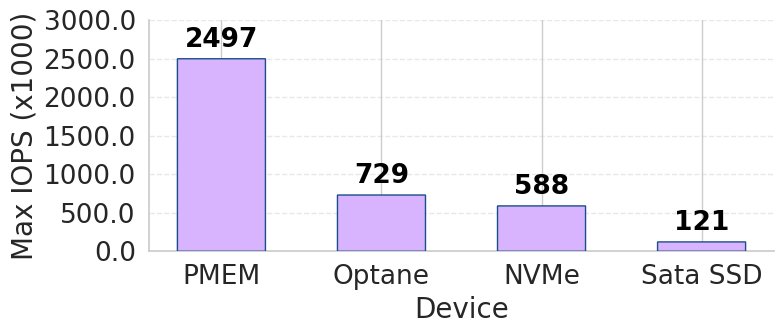

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.patches import FancyBboxPatch


def load_results(path):
    """Reads Excel or CSV performance results."""
    path = Path(path)
    if path.suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    else:
        return pd.read_csv(path)


def plot_max_iops_per_device(
    path,
    workload,
    block_size,
    engine=None,
    poll=None,
    title_fontsize=16,
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    xticks_fontsize=10,
    yticks_fontsize=10,
    xticks_label=None,
    xticks_label_rotation=20,
    save_pdf=False,
    file_name="plot.pdf",
    show_values=True,
    bar_width=0.25        # NEW THINNER BAR WIDTH
):
    """
    Plot: X=device, Y=max IOPS (paper-quality visualization)
    """

    df = load_results(path)

    # -----------------------------
    # Filter dataset
    # -----------------------------
    df_sel = df[(df["workload"] == workload) & (df["block_size"] == block_size)]

    if engine is not None:
        df_sel = df_sel[df_sel["engine"] == engine]
    if poll is not None:
        df_sel = df_sel[df_sel["poll"] == poll]

    if df_sel.empty:
        raise ValueError(
            f"No rows found for workload={workload}, block_size={block_size}, "
            f"engine={engine}, poll={poll}"
        )

    # -----------------------------
    # Extract max IOPS per device
    # -----------------------------
    grouped = (
        df_sel.groupby("device", as_index=False)["iops"]
        .max()
        .rename(columns={"iops": "max_iops"})
        .sort_values("max_iops", ascending=False)
    )

    devices = grouped["device"].tolist()
    max_iops = grouped["max_iops"].values / 1000  # convert to K IOPS

    x = np.arange(len(devices))

    # -----------------------------
    # Improved Figure Style
    # -----------------------------
    plt.figure(figsize=(8, 3.5))
    ax = plt.gca()

    # Color palette (modern)
    base_color = "#d8b4ff"
    edge_color = "#1A4E89"

    # -----------------------------
    # Draw improved thin bars
    # -----------------------------
    bars = []
    for xi, val in zip(x, max_iops):

        # shadow (soft drop shadow behind bar)
        ax.bar(
            xi,
            val,
            width=bar_width,
            color="black",
            alpha=0.08,
            zorder=2
        )

        # main rounded bar
        bar = FancyBboxPatch(
            (xi - bar_width/2, 0),
            bar_width,
            val,
            boxstyle="round,pad=0.15,rounding_size=0.15",
            linewidth=1.0,
            edgecolor=edge_color,
            facecolor=base_color,
            zorder=5
        )
        ax.add_patch(bar)
        bars.append(bar)

    # -----------------------------
    # Optional Value Labels
    # -----------------------------
    if show_values:
        for xi, val in zip(x, max_iops):
            ax.text(
                xi,
                val + max(max_iops) * 0.03,
                f"{val:.0f}",
                ha="center",
                va="bottom",
                fontsize=xticks_fontsize,
                color="black",
                fontweight="bold"
            )

    # -----------------------------
    # Labels & Axes
    # -----------------------------
    ax.set_ylabel("Max IOPS (x1000)", fontsize=ylabel_fontsize)
    ax.set_xlabel("Device", fontsize=xlabel_fontsize)

    if xticks_label is None:
        xticks_label = devices

    ax.set_xticks(x)
    ax.set_xticklabels(
        xticks_label,
        rotation=xticks_label_rotation,
        fontsize=xticks_fontsize
    )

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticks(), fontsize=yticks_fontsize)

    # -----------------------------
    # Clean background & grid
    # -----------------------------
    ax.grid(axis="y", linestyle="--", alpha=0.45, zorder=1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(bottom=0)

    plt.tight_layout()

    # -----------------------------
    # Save PDF
    # -----------------------------
    if save_pdf:
        plt.savefig(file_name, format="pdf", bbox_inches="tight")

    plt.show()



# =============================================================
# USAGE EXAMPLE
# =============================================================
if __name__ == "__main__":
    path = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/all_top1_libaio_iops_results.xlsx"

    plot_max_iops_per_device(
        path,
        workload="randread",
        block_size="2k",
        engine="libaio",
        poll="none",
        xlabel_fontsize=20,
        ylabel_fontsize=20,
        xticks_fontsize=19,
        yticks_fontsize=19,
        xticks_label=["PMEM", "Optane", "NVMe", "Sata SSD"],
        xticks_label_rotation=0,
        save_pdf=True,
        file_name="challenge_max_IOPS_per_dev.pdf",
        show_values=True,
        bar_width=0.25        
    )


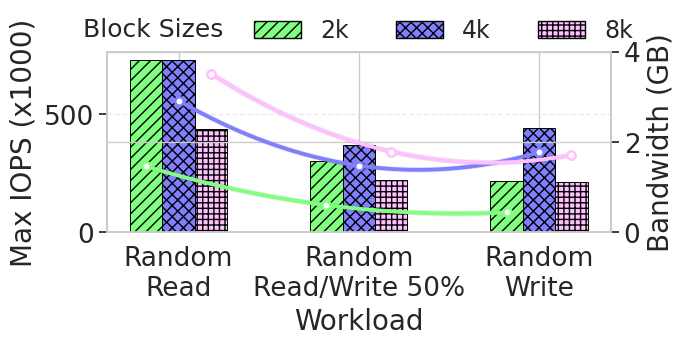

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.interpolate import make_interp_spline
import matplotlib.patches as mpatches


# -------------------------------------------------
# HATCH STYLES (one per block size)
# -------------------------------------------------
HATCHES = ['///', 'xxx', '+++']   # 2k, 4k, 8k


def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    k = min(3, len(x) - 1)
    if k < 2:
        return x, y

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=k)
    y_new = spline(x_new)
    return x_new, y_new


def load_results(path):
    path = Path(path)
    if path.suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    else:
        return pd.read_csv(path)


def plot_iops_and_bandwidth(
    path,
    device,
    workloads=None,
    block_sizes=None,
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    xticks_fontsize=10,
    yticks_fontsize=10,
    xticks_label=None,
    legend_loc="upper right",
    legend_bbox_to_anchor=(1.05, 1),
    save_pdf=False,
    file_name="plot.pdf",
    bw_ymax=3.0,
    bw_divisor=1_000_000,
):

    # -----------------------------
    # Load & filter
    # -----------------------------
    df = load_results(path)
    df_dev = df[df["device"] == device]
    if df_dev.empty:
        raise ValueError(f"No data for device={device}")

    if workloads is not None:
        df_dev = df_dev[df_dev["workload"].isin(workloads)]

    if block_sizes is not None:
        df_dev = df_dev[df_dev["block_size"].isin(block_sizes)]

    # -----------------------------
    # IOPS pivot
    # -----------------------------
    iops_table = (
        df_dev.groupby(["workload", "block_size"])["iops"]
        .max()
        .unstack("block_size")
        .sort_index()
    )

    workloads_order = iops_table.index.tolist()
    block_sizes_order = iops_table.columns.tolist()

    # -----------------------------
    # BW pivot
    # -----------------------------
    bw_table = (
        df_dev.groupby(["workload", "block_size"])["bandwidth_kbps"]
        .max()
        .unstack("block_size")
        .reindex(index=workloads_order, columns=block_sizes_order)
    )

    x = np.arange(len(workloads_order))
    bar_width = 0.18

    # -----------------------------
    # Figure & IOPS bars
    # -----------------------------
    fig, ax = plt.subplots(figsize=(7, 4))

    base_colors = ["#80ff80", "#8080ff", "#ffc0ff"]
    colors = [base_colors[i % len(base_colors)] for i in range(len(block_sizes_order))]

    for i, (bs, c) in enumerate(zip(block_sizes_order, colors)):
        ax.bar(
            x + i * bar_width,
            iops_table[bs].values / 1000,
            width=bar_width,
            color=c,
            hatch=HATCHES[i % len(HATCHES)],   # ✅ hatch added
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
        )

    ax.set_ylabel("Max IOPS (x1000)", fontsize=ylabel_fontsize)
    ax.set_xlabel("Workload", fontsize=xlabel_fontsize)

    if xticks_label is None:
        xticks_label = workloads_order

    ax.set_xticks(x + bar_width * (len(block_sizes_order) - 1) / 2)
    ax.set_xticklabels(xticks_label, fontsize=xticks_fontsize)
    ax.tick_params(axis="y", labelsize=yticks_fontsize)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    # -----------------------------
    # Custom legend with hatches
    # -----------------------------
    legend_handles = [
        mpatches.Patch(
            facecolor=colors[i],
            hatch=HATCHES[i % len(HATCHES)],
            edgecolor="black",
            label=bs
        )
        for i, bs in enumerate(block_sizes_order)
    ]

    legend = ax.legend(
        handles=legend_handles,
        fontsize=17,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox_to_anchor,
        ncol=3,
        frameon=False,
    )

    # Left-side legend title
    legend_box = legend.get_window_extent(fig.canvas.get_renderer())
    inv = ax.transAxes.inverted()
    legend_bbox_axes = inv.transform(legend_box)

    ax.text(
        legend_bbox_axes[0][0] - 0.04,
        (legend_bbox_axes[0][1] + legend_bbox_axes[1][1]) / 2,
        "Block Sizes",
        fontsize=18,
        va="top",
        ha="right",
        transform=ax.transAxes,
    )

    # -----------------------------
    # Bandwidth lines (right axis)
    # -----------------------------
    ax2 = ax.twinx()
    ax2.set_ylabel("Bandwidth (GB)", fontsize=ylabel_fontsize)
    ax2.tick_params(axis="y", labelsize=yticks_fontsize)
    ax2.set_ylim(0, bw_ymax)

    ax2.set_zorder(ax.get_zorder() + 1)
    ax.patch.set_visible(False)

    for i, (bs, c) in enumerate(zip(block_sizes_order, colors)):
        bw_raw = bw_table[bs].values / bw_divisor
        x_raw = x + i * bar_width

        x_s, y_s = smooth_curve(x_raw, bw_raw)

        ax2.plot(x_s, y_s, color="black", linewidth=4.0, alpha=0.08, zorder=20)
        ax2.plot(x_s, y_s, color=c, linewidth=2.8, zorder=21)
        ax2.plot(
            x_raw, bw_raw,
            linestyle="none",
            marker="o",
            markersize=6,
            markerfacecolor="white",
            markeredgewidth=1.8,
            color=c,
            zorder=22,
        )

    fig.tight_layout()

    if save_pdf:
        fig.savefig(file_name, format="pdf", bbox_inches="tight")

    plt.show()


# -------------------------------------------------
# MAIN
# -------------------------------------------------
if __name__ == "__main__":
    plot_iops_and_bandwidth(
        path="/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/all_top1_libaio_iops_results.xlsx",
        device="/dev/nvme0n1",
        workloads=["randread", "randwrite", "randrw_50"],
        block_sizes=["2k", "4k", "8k"],
        xlabel_fontsize=20,
        ylabel_fontsize=20,
        xticks_fontsize=19,
        yticks_fontsize=19,
        xticks_label=["Random\nRead", "Random\nRead/Write 50%", "Random\nWrite"],
        legend_loc="upper left",
        legend_bbox_to_anchor=(.25, 1.3),
        save_pdf=True,
        file_name="challenge_max_IOPS_per_workload.pdf",
        bw_ymax=4.0,
        bw_divisor=1_000_000,
    )


# 📊 **Script 1: Deterministic Training & Evaluation**

## 🎯 **Overview**
This script implements the foundational logic of our IOPS prediction project. It operates on a **deterministic** basis, meaning the training and testing datasets are fixed and come from separate files. This allows us to model the "Maximum Theoretical Performance" and test it against "Real-world Limited Scenarios".

## ⚙️ **Methodology**

### 1. Data Source
* **Training Data (`AllDevices.xlsx`):** Contains the results of performance benchmarks. The script aggregates this data to find the **Maximum IOPS** for each configuration (Device, BlockSize, Read%). The model learns the *ceiling* of performance.
* **Testing Data (`limit100.xlsx`):** Contains real-world test runs. The model predicts the IOPS for these configurations, and we compare the prediction against the **Actual IOPS**.

### 2. Models Implemented
We train four distinct regression models to capture different aspects of the data:
* **LINEAR:** Simple Linear Regression (Baseline).
* **LASSO_POLY:** Linear Regression with Polynomial Features (captures non-linear relationships) and Lasso regularization.
* **RANDOM_FOREST:** Ensemble method based on Decision Trees (handles complex interactions well).
* **SVR:** Support Vector Regression (effective in high-dimensional spaces).

### 3. Evaluation Metric
* **MAPE (Mean Absolute Percentage Error):** We use MAPE to evaluate accuracy. It tells us, on average, by what percentage the model's prediction deviates from the actual value.
* **Bar Charts:** Visual comparison of Actual vs. Predicted IOPS for every Device/BlockSize combination.
* **Summary Plot:** A final chart showing the average error for each model across each device.

## 🚀 **How to Use**
1.  Ensure `AllDevices.xlsx` and `limit100.xlsx` are uploaded to the Colab environment.
2.  Run the cell below.
3.  The script will generate:
    * A folder `barcharts_ordinary` containing PDF plots for detailed analysis.
    * An Excel file `predictions_ordinary.xlsx` with raw results.
    * A final summary plot `FINAL_SUMMARY_MAPE.pdf`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import clone
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# --- ⚙️ CONFIGURATION & SETTINGS ---
CONFIG = {
    'font_size_title': 16,
    'font_size_label': 14,
    'font_size_tick': 12,
    'font_size_legend': 12,
    'plot_format': 'pdf',  # Best for papers (vector graphics)
    'plot_dir': 'barcharts_ordinary'
}

# Hyperparameters (Easy to Tune)
HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}
# -------------------------------------

def read_and_prep_data(file_path, is_test_file=False):
    """
    Loads and pre-processes data.
    """
    print(f"Loading data from: {file_path}")

    # Robust loading: Try CSV first, then Excel
    try:
        df = pd.read_csv(file_path, converters={'job options/bs': str}, encoding='latin1')
    except:
        try:
            df = pd.read_excel(file_path, converters={'job options/bs': str})
        except Exception as e:
            print(f"CRITICAL: Could not read file {file_path}. Error: {e}")
            return None

    print("...Load successful.")

    # Basic Cleaning
    df['job options/filename'] = df['job options/filename'].fillna('unknown')

    # Feature Extraction
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)
    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')

    # Fix read_percent logic
    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100.0
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
    df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
    df['read_percent'] = df['read_percent'].fillna(100.0)

    if is_test_file:
        # For Test Data: Calculate 'actual_total_iops'
        df['actual_total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        return df
    else:
        # For Training Data: Aggregate to find MAX IOPS
        print("Aggregating training data (MAX strategy)...")
        agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
        df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()

        # Merge meta-data back
        df_minimal = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates(subset=agg_cols)
        df_final_agg = pd.merge(df_agg, df_minimal, on=agg_cols, how='left')
        return df_final_agg

def engineer_features(df):
    if not isinstance(df, pd.DataFrame): return None
    df_out = df.copy()

    # Device Extraction
    df_out['device'] = df_out['job options/filename'].str.extract(r'/dev/(\w+)')
    df_out['device'] = df_out['device'].str.replace(r'\d+$', '', regex=True)
    df_out['device'] = df_out['device'].str.replace(r'n\d+$', '', regex=True)
    df_out['device'] = df_out['device'].fillna('unknown')

    return df_out

def train_models(df_train, features):
    print("\n--- 🚂 Starting Model Training ---")
    devices = df_train['device'].unique()
    models = {}

    for dev in devices:
        if dev == 'unknown': continue
        print(f"Training models for device: {dev}")

        dev_data = df_train[df_train['device'] == dev].copy()
        if len(dev_data) < 5: continue

        X_train = dev_data[features]
        y_train = dev_data['total_iops'] # Target: Max IOPS

        # --- Define Models ---
        linear_pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

        lasso_pipe = Pipeline([
            ('poly', PolynomialFeatures(degree=HYPERPARAMS['lasso_degree'], include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
        ])

        rf_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(
                n_estimators=HYPERPARAMS['rf_n_estimators'],
                max_depth=HYPERPARAMS['rf_max_depth'],
                min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                random_state=42
            ))
        ])

        svr_pipe = Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=100))])

        dev_models = {
            'LINEAR': clone(linear_pipe),
            'LASSO_POLY': clone(lasso_pipe),
            'RANDOM_FOREST': clone(rf_pipe),
            'SVR': clone(svr_pipe)
        }

        for name, model in dev_models.items():
            model.fit(X_train, y_train)

        models[dev] = dev_models

    return models

def evaluate_and_predict(df_test, models, features):
    print("\n--- 🧪 Starting Prediction on Test Data ---")
    all_results = []

    for dev, dev_models in models.items():
        dev_test_data = df_test[df_test['device'] == dev].copy()
        if dev_test_data.empty: continue

        X_test = dev_test_data[features]
        y_actual = dev_test_data['actual_total_iops']

        dev_results = dev_test_data[['device', 'read_percent', 'block_size_kb']].copy()
        dev_results['Actual'] = y_actual

        for name, model in dev_models.items():
            y_pred = model.predict(X_test)
            if name == 'LINEAR': y_pred[y_pred < 0] = 0
            dev_results[name] = y_pred

        all_results.append(dev_results)

    if not all_results: return None
    return pd.concat(all_results, ignore_index=True)

def create_plots(results_df):
    print("\n--- 📊 Generating Detailed Bar Charts ---")
    if results_df is None or results_df.empty: return

    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    model_cols = [c for c in results_df.columns if c not in ['device', 'block_size_kb', 'read_percent', 'Actual']]
    hue_order = ['Actual'] + model_cols

    # Colors
    colors_list = ['#33a02c', '#1f78b4', '#a6cee3', '#e31a1c', '#fdbf6f', '#6a3d9a']
    model_colors = {m: colors_list[i % len(colors_list)] for i, m in enumerate(hue_order)}

    for (dev, bs), group_data in results_df.groupby(['device', 'block_size_kb']):

        # --- Calculate MAPE for Title (2 decimal precision) ---
        mape_strs = []
        for m in model_cols:
            y_true = group_data['Actual']
            y_pred = group_data[m]
            mask = y_true > 0
            if mask.any():
                mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
                mape_strs.append(f"{m}: {mape:.2f}%") # 2 decimals
            else:
                mape_strs.append(f"{m}: N/A")
        title_mape = " | ".join(mape_strs)

        # Plotting
        data_long = group_data.melt(id_vars=['read_percent'], value_vars=hue_order, var_name='Model', value_name='IOPS')

        plt.figure(figsize=(14, 8))
        ax = sns.barplot(data=data_long, x='read_percent', y='IOPS', hue='Model', palette=model_colors)

        # Y-Axis padding
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.25) # More space for labels

        # Annotations (2 decimal precision)
        actual_lookup = group_data.set_index('read_percent')['Actual'].to_dict()
        sorted_read_percents = sorted(group_data['read_percent'].unique())
        n_groups = len(sorted_read_percents)

        for i, bar in enumerate(ax.patches):
            model_idx = i // n_groups
            group_idx = i % n_groups

            if model_idx >= len(hue_order): continue
            model_name = hue_order[model_idx]

            if model_name == 'Actual': continue

            current_read_pct = sorted_read_percents[group_idx]
            actual_val = actual_lookup.get(current_read_pct, 0)
            pred_val = bar.get_height()

            if actual_val > 0:
                err = (pred_val - actual_val) / actual_val * 100
                lbl = f"{err:+.2f}%" # 2 decimals
            else:
                lbl = "N/A"

            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (ymax*0.02),
                    lbl, ha='center', va='bottom', fontsize=8, rotation=90)

        # Styling
        plt.title(f"Device: {dev} | BS: {bs}k\nMAPE: {title_mape}", fontsize=CONFIG['font_size_title'])
        plt.xlabel("Read %", fontsize=CONFIG['font_size_label'])
        plt.ylabel("IOPS", fontsize=CONFIG['font_size_label'])
        plt.tick_params(labelsize=CONFIG['font_size_tick'])
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=CONFIG['font_size_legend'])
        plt.tight_layout()

        # Save as PDF
        fname = f"{CONFIG['plot_dir']}/bar_{dev}_{bs}k.{CONFIG['plot_format']}"
        plt.savefig(fname, bbox_inches='tight')
        plt.close()

def create_summary_plot(results_df):
    """
    Final summary plot of Average MAPE.
    """
    print("\n--- 📊 Generating Final Summary Plot ---")
    if results_df is None or results_df.empty: return

    model_cols = [c for c in results_df.columns if c not in ['device', 'block_size_kb', 'read_percent', 'Actual']]

    summary_data = []
    for m in model_cols:
        valid_rows = results_df[results_df['Actual'] > 0].copy()
        valid_rows['APE'] = np.abs((valid_rows[m] - valid_rows['Actual']) / valid_rows['Actual']) * 100

        device_mape = valid_rows.groupby('device')['APE'].mean().reset_index()
        device_mape['Model'] = m
        summary_data.append(device_mape)

    if not summary_data: return

    plot_df = pd.concat(summary_data, ignore_index=True)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x='device', y='APE', hue='Model', palette='viridis')

    plt.title("Final Summary: Average MAPE by Device", fontsize=CONFIG['font_size_title'])
    plt.ylabel("Mean Absolute Percentage Error (%)", fontsize=CONFIG['font_size_label'])
    plt.xlabel("Device", fontsize=CONFIG['font_size_label'])
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=CONFIG['font_size_legend'])
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Annotation (2 decimal precision)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}%', # 2 decimals
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

    fname = f"{CONFIG['plot_dir']}/FINAL_SUMMARY_MAPE.{CONFIG['plot_format']}"
    plt.savefig(fname, bbox_inches='tight')
    plt.close()
    print(f"Summary plot saved to {fname}")

def main():
    # Paths
    TRAIN_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices.xlsx"
    TEST_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/limit100.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']

    # 1. Load
    train_df = read_and_prep_data(TRAIN_PATH, is_test_file=False)
    test_df = read_and_prep_data(TEST_PATH, is_test_file=True)

    if train_df is None or test_df is None: return

    # 2. Feature Eng
    df_train_eng = engineer_features(train_df)
    df_test_eng = engineer_features(test_df)

    # 3. Train
    models = train_models(df_train_eng, FEATURES)

    # 4. Predict
    results = evaluate_and_predict(df_test_eng, models, FEATURES)

    if results is not None:
        # Aggregate duplicates
        agg_results = results.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

        # Output
        agg_results.to_excel("predictions_ordinary.xlsx", index=False)
        create_plots(agg_results)
        create_summary_plot(agg_results)
        print("\n✅ Script Completed Successfully!")

if __name__ == "__main__":
    main()

Loading data from: /Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices.xlsx
...Load successful.
Aggregating training data (MAX strategy)...
Loading data from: /Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/limit100.xlsx
...Load successful.

--- 🚂 Starting Model Training ---
Training models for device: nvme0n
Training models for device: nvme1n
Training models for device: pmem
Training models for device: sda

--- 🧪 Starting Prediction on Test Data ---

--- 📊 Generating Detailed Bar Charts ---

--- 📊 Generating Final Summary Plot ---
Summary plot saved to barcharts_ordinary/FINAL_SUMMARY_MAPE.pdf

✅ Script Completed Successfully!


# 📈 **Script: Block-Size Generalization Analysis**

## 🎯 **Overview**
This script evaluates the models' ability to **generalize across different block sizes**. Instead of a random split, the data is split deterministically based on the `block_size_kb` feature.

## ⚙️ **Methodology**
1.  **Data Source:** A single consolidated file (`AllDevices2.xlsx`).
2.  **Exclusion:** The `sata` device is explicitly excluded from this analysis.
3.  **Train/Test Split Logic:**
    * **Training Set:** Block sizes that are powers of 2 (`2, 4, 8, 16, 32, 64, 128` KB). This simulates standard benchmark conditions.
    * **Testing Set:** All other block sizes (e.g., `3, 5, 12, 48` KB, etc.). This tests whether the models can accurately interpolate/extrapolate performance for non-standard, real-world workloads.
4.  **Target Aggregation:** To ensure stable training, the script groups identical configurations and trains the model on the **Maximum IOPS** observed.

## 📊 **Outputs**
* **PDF Barcharts:** Actual vs. Predicted IOPS for testing configurations.
* **Summary Plot:** Average MAPE per device across all models.
* **Excel Export:** Raw prediction values for further analysis.

In [ ]:
# New Script Added


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import clone
import matplotlib.patches as mpatches
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_title': 16,
    'font_size_label': 14,
    'font_size_tick': 12,
    'font_size_legend': 12,
    'plot_ext': 'pdf',
    'plot_dir': 'barcharts_regime_based4' # Changed directory name
}

ERROR_PANEL_RATIO = 1.0
EXPORT_PDF = True

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# MODELS / STYLES
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5'
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR'
}

# -------------------------------------------------
# DATA LOADING
# -------------------------------------------------
def read_and_prep_data(file_path, is_test_file=False):
    print(f"Loading data from: {file_path}")

    try:
        df = pd.read_csv(file_path, converters={'job options/bs': str}, encoding='latin1')
    except:
        try:
            df = pd.read_excel(file_path, converters={'job options/bs': str})
        except Exception as e:
            print(f"CRITICAL: Could not read file {file_path}. Error: {e}")
            return None

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)
    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')

    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100.0
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
    df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
    df['read_percent'] = df['read_percent'].fillna(100.0)

    if is_test_file:
        df['actual_total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        return df
    else:
        print("Aggregating training data (MAX strategy)...")
        df['total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
        df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()

        df_minimal = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates(subset=agg_cols)
        df_final_agg = pd.merge(df_agg, df_minimal, on=agg_cols, how='left')
        return df_final_agg

def engineer_features(df):
    if not isinstance(df, pd.DataFrame): return None
    df_out = df.copy()

    df_out['device'] = df_out['job options/filename'].str.extract(r'/dev/(\w+)')
    df_out['device'] = df_out['device'].str.replace(r'\d+$', '', regex=True)
    df_out['device'] = df_out['device'].str.replace(r'n\d+$', '', regex=True)
    df_out['device'] = df_out['device'].fillna('unknown')

    return df_out

# -------------------------------------------------
# 🔥 NEW: REGIME-BASED TRAINING
# -------------------------------------------------
def get_base_pipelines():
    return {
        'LINEAR': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'LASSO_POLY': Pipeline([
            ('poly', PolynomialFeatures(degree=HYPERPARAMS['lasso_degree'], include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
        ]),
        'RANDOM_FOREST': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(
                n_estimators=HYPERPARAMS['rf_n_estimators'],
                max_depth=HYPERPARAMS['rf_max_depth'],
                min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                random_state=42
            ))
        ]),
        'SVR': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=100))])
    }

def train_models(df_train, features):
    print("\n--- 🚂 Starting Regime-Based Model Training ---")
    devices = df_train['device'].unique()
    models = {}

    for dev in devices:
        if dev == 'unknown': continue
        print(f"Training models for device: {dev}")

        dev_data = df_train[df_train['device'] == dev].copy()

        # Split Train Data into Regimes
        dev_data_small = dev_data[dev_data['block_size_kb'] <= 16]
        dev_data_large = dev_data[dev_data['block_size_kb'] > 16]

        models[dev] = {'small': {}, 'large': {}}

        # Train Small BS Models
        if len(dev_data_small) >= 3:
            pipes_small = get_base_pipelines()
            X_small = dev_data_small[features]
            y_small = dev_data_small['total_iops']
            for name, model in pipes_small.items():
                model.fit(X_small, y_small)
            models[dev]['small'] = pipes_small
            print(f"  -> Small Regime trained on {len(dev_data_small)} samples.")
        else:
            print(f"  -> Skipped Small Regime (Not enough data)")

        # Train Large BS Models
        if len(dev_data_large) >= 3:
            pipes_large = get_base_pipelines()
            X_large = dev_data_large[features]
            y_large = dev_data_large['total_iops']
            for name, model in pipes_large.items():
                model.fit(X_large, y_large)
            models[dev]['large'] = pipes_large
            print(f"  -> Large Regime trained on {len(dev_data_large)} samples.")
        else:
            print(f"  -> Skipped Large Regime (Not enough data)")

    return models

# -------------------------------------------------
# 🔥 NEW: REGIME-BASED PREDICTION
# -------------------------------------------------
def evaluate_and_predict(df_test, models, features):
    print("\n--- 🧪 Starting Regime-Based Prediction on Test Data ---")
    all_results = []

    for dev, dev_regimes in models.items():
        dev_test_data = df_test[df_test['device'] == dev].copy()
        if dev_test_data.empty: continue

        # Initialize Results DataFrame
        dev_results = dev_test_data[['device', 'read_percent', 'block_size_kb']].copy()
        if 'actual_total_iops' in dev_test_data.columns:
            dev_results['Actual'] = dev_test_data['actual_total_iops']
        else:
            dev_results['Actual'] = dev_test_data['total_iops']

        for m in ['LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']:
            dev_results[m] = np.nan # Pre-fill with NaN

        # Masks for Regimes
        mask_small = dev_test_data['block_size_kb'] <= 16
        mask_large = dev_test_data['block_size_kb'] > 16

        # Predict Small
        if mask_small.any() and dev_regimes['small']:
            X_small = dev_test_data[mask_small][features]
            for name, model in dev_regimes['small'].items():
                preds = model.predict(X_small)
                preds[preds < 0] = 0
                dev_results.loc[mask_small, name] = preds

        # Predict Large
        if mask_large.any() and dev_regimes['large']:
            X_large = dev_test_data[mask_large][features]
            for name, model in dev_regimes['large'].items():
                preds = model.predict(X_large)
                preds[preds < 0] = 0
                dev_results.loc[mask_large, name] = preds

        all_results.append(dev_results)

    if not all_results: return None
    return pd.concat(all_results, ignore_index=True)


# -------------------------------------------------
# PLOTTING (2×1 GRID) - Unchanged (NaN Safe)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):

    print("\n--- 📊 Generating Detailed Grid Plots ---")
    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(10, 4),
            sharex=True,
            gridspec_kw={
                'height_ratios': [ERROR_PANEL_RATIO, 2.0]
            }
        )

        bar_w = 0.18
        offsets = (np.arange(len(MODEL_ORDER)) - 2) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    if pd.isna(p):
                        errors.append(np.nan)
                    else:
                        errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].fillna(0).values / 1000, # Handle NaNs safely
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.53, 1.06),
            ncol=5,
            fontsize=CONFIG['font_size_legend'],
            frameon=True,
            handlelength=1.4,
            handletextpad=0.4,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3
        )

        plt.tight_layout(rect=[0, 0, 1, 0.94])

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.close()


# -------------------------------------------------
# SUMMARY PLOT
# -------------------------------------------------
def create_summary_plot(results_df, bar_width=0.24):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem'
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        # Filter out NaNs if a regime was missing
        tmp = tmp.dropna(subset=[m])
        if tmp.empty: continue

        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    if not summary: return
    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals_series = plot_df[plot_df['Model'] == m].set_index('device')['APE']
        # Map values properly ensuring correct device order
        vals = [vals_series.get(d, 0) for d in devices]

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    h + ax.get_ylim()[1] * 0.015,
                    f"{h:.0f}%",
                    ha='center',
                    va='bottom',
                    fontsize=CONFIG['font_size_tick'] - 4
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.28),
        ncol=4,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    if EXPORT_PDF:
        plt.savefig(fname, bbox_inches='tight')
    plt.close()

    print(f"✅ Summary plot saved to {fname}")

# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    # File Path
    FILE_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']

    # 1. Load Data
    # Use read_and_prep_data (works fine since we calculate total_iops inside it)
    df_raw = read_and_prep_data(FILE_PATH, is_test_file=False)
    if df_raw is None: return

    # 2. Feature Engineering & Filtering
    df_eng = engineer_features(df_raw)

    print("Filtering out 'sda' devices...")
    df_eng = df_eng[df_eng['device'].str.lower() != 'sda']

    # 3. Train / Test Split Logic
    print("Splitting Data based on Block Size (Test=Powers of 2, Train=Others)...")
    powers_of_2 = [2, 4, 8, 16, 32, 64, 128]

    # Train = Non-powers of 2
    train_df = df_eng[df_eng['block_size_kb'].isin(powers_of_2)].copy()
    # Test = Powers of 2
    test_df = df_eng[~df_eng['block_size_kb'].isin(powers_of_2)].copy()

    print(f"  - Train Data Shape: {train_df.shape}")
    print(f"  - Test Data Shape: {test_df.shape}")

    if test_df.empty:
        print("CRITICAL: No testing data found. Exiting.")
        return

    # Prepare Target column for evaluation logic
    test_df['actual_total_iops'] = test_df['total_iops']

    # 4. Train Models
    models = train_models(train_df, FEATURES)

    # 5. Predict on Test
    res = evaluate_and_predict(test_df, models, FEATURES)

    if res is not None:
        agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

        agg.to_excel("predictions_regime_based.xlsx", index=False)
        create_plots(agg)
        create_summary_plot(agg)
        print("\n✅ Script Completed Successfully!")

if __name__ == "__main__":
    main()

Loading data from: drive/MyDrive/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx
Aggregating training data (MAX strategy)...
Filtering out 'sda' devices...
Splitting Data based on Block Size (Test=Powers of 2, Train=Others)...
  - Train Data Shape: (197, 7)
  - Test Data Shape: (3926, 7)

--- 🚂 Starting Regime-Based Model Training ---
Training models for device: nvme0n
  -> Small Regime trained on 32 samples.
  -> Large Regime trained on 33 samples.
Training models for device: nvme1n
  -> Small Regime trained on 33 samples.
  -> Large Regime trained on 33 samples.
Training models for device: pmem
  -> Small Regime trained on 33 samples.
  -> Large Regime trained on 33 samples.

--- 🧪 Starting Regime-Based Prediction on Test Data ---

--- 📊 Generating Detailed Grid Plots ---

--- 📊 Generating Final Summary Plot ---
✅ Summary plot saved to barcharts_regime_based4/Overall_Error.pdf

✅ Script Completed Successfully!


# 🧠 **Script: Hardware-Aware Smart Hybrid Model**

## 🎯 **Overview**
Based on our comprehensive analysis of storage device physics and ML algorithm behaviors, we observed that no single model rules them all:
* **Small Block Sizes ($\le$ 8KB):** Are IOPS-bound and highly non-linear, favoring polynomial regressions like `LASSO_POLY`.
* **Transition Zone (8KB - 16KB):** Contains high noise and jitter, where `SVR` acts as a robust margin-based predictor.
* **Large Block Sizes ($>$ 16KB):** Hit the PCIe bandwidth ceiling (step-wise limits), where tree-based models like `RANDOM_FOREST` excel.

To address this, we introduce a **`SMART_HYBRID`** meta-estimator. This model dynamically routes the prediction task to the most suitable underlying algorithm based on the requested block size.

## ⚙️ **Methodology**
1.  **Data Split:** Train on standard powers of 2 (2, 4, 8, 16, 32, 64, 128), Test on the rest.
2.  **Smart Routing:** The `SmartHybridRegressor` acts as an intelligent router during both training and prediction.
3.  **Visualization:** Added the new `SMART_HYBRID` model to the mentor's 2-panel chart layout (Gold color with star hatching) to prove its superior generalization.

In [ ]:
# New Script Added

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, RegressorMixin, clone
import matplotlib.patches as mpatches
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_title': 16, # Adjusted slightly to fit new legend
    'font_size_label': 18,
    'font_size_tick': 16,
    'font_size_legend': 14,
    'plot_dir': 'barcharts_smart_hybrid',
    'plot_ext': 'pdf',
}

ERROR_PANEL_RATIO = 1.0
EXPORT_PDF = True

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# 🔥 NEW: SMART HYBRID META-MODEL
# -------------------------------------------------
class SmartHybridRegressor(BaseEstimator, RegressorMixin):
    """
    A hardware-aware ensemble model that routes predictions
    based on the block size.
    """
    def __init__(self, lasso_pipe, svr_pipe, rf_pipe):
        self.lasso_pipe = clone(lasso_pipe)
        self.svr_pipe = clone(svr_pipe)
        self.rf_pipe = clone(rf_pipe)

    def fit(self, X, y):
        # Train all internal models on the full training data
        self.lasso_pipe.fit(X, y)
        self.svr_pipe.fit(X, y)
        self.rf_pipe.fit(X, y)
        return self

    def predict(self, X):
        # X must be a pandas DataFrame containing 'block_size_kb'
        preds = np.zeros(len(X))

        mask_small = X['block_size_kb'] <= 8
        mask_mid = (X['block_size_kb'] > 8) & (X['block_size_kb'] <= 16)
        mask_large = X['block_size_kb'] > 16

        if mask_small.any():
            preds[mask_small] = self.svr_pipe.predict(X[mask_small])
        if mask_mid.any():
            preds[mask_mid] = self.rf_pipe.predict(X[mask_mid])
        if mask_large.any():
            preds[mask_large] = self.rf_pipe.predict(X[mask_large])

        return preds

# -------------------------------------------------
# MODELS / STYLES (Added SMART_HYBRID)
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR', 'SMART_HYBRID']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
    'SMART_HYBRID': '**' # Star hatch for the smart model
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5',
    'SMART_HYBRID': '#ffd700' # Gold color to stand out
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR',
    'SMART_HYBRID': 'Smart Hybrid'
}

# -------------------------------------------------
# DATA LOADING
# -------------------------------------------------
def load_unified_data(path):
    print(f"Loading data from: {path}")
    try:
        df = pd.read_csv(path, converters={'job options/bs': str}, encoding='latin1')
    except:
        df = pd.read_excel(path, converters={'job options/bs': str})

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)

    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0
    df.loc[(df['job options/rw'] == 'randrw') & df['read_percent'].isna(), 'read_percent'] = 50
    df['read_percent'] = df['read_percent'].fillna(100)

    df['total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)

    print("Aggregating data (MAX strategy per config)...")
    agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
    df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()
    meta = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates()

    return pd.merge(df_agg, meta, on=agg_cols, how='left')

def engineer_features(df):
    df = df.copy()
    df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
    df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
    df['device'] = df['device'].fillna('unknown')

    # Exclude sata
    df = df[df['device'].str.lower() != 'sata']
    return df

# -------------------------------------------------
# TRAIN / PREDICT
# -------------------------------------------------
def train_models(df, features):
    print("\n--- 🚂 Starting Model Training ---")
    models = {}
    for dev in df['device'].unique():
        if dev == 'unknown':
            continue

        sub = df[df['device'] == dev]
        if len(sub) < 3:
            continue

        X = sub[features]
        y = sub['total_iops']

        linear_pipe = Pipeline([('s', StandardScaler()), ('m', LinearRegression())])
        lasso_pipe = Pipeline([
            ('p', PolynomialFeatures(HYPERPARAMS['lasso_degree'], include_bias=False)),
            ('s', StandardScaler()),
            ('m', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
        ])
        rf_pipe = Pipeline([
            ('s', StandardScaler()),
            ('m', RandomForestRegressor(
                n_estimators=HYPERPARAMS['rf_n_estimators'],
                max_depth=HYPERPARAMS['rf_max_depth'],
                min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                random_state=42))
        ])
        svr_pipe = Pipeline([('s', StandardScaler()), ('m', SVR(C=100))])

        # Initialize the Smart Hybrid Model
        smart_hybrid = SmartHybridRegressor(lasso_pipe, svr_pipe, rf_pipe)

        models[dev] = {
            'LINEAR': clone(linear_pipe),
            'LASSO_POLY': clone(lasso_pipe),
            'RANDOM_FOREST': clone(rf_pipe),
            'SVR': clone(svr_pipe),
            'SMART_HYBRID': smart_hybrid
        }

        for m in models[dev].values():
            m.fit(X, y)

    return models

def evaluate_and_predict(df, models, features):
    print("\n--- 🧪 Starting Prediction on Test Data ---")
    out = []
    for dev, dev_models in models.items():
        sub = df[df['device'] == dev]
        if sub.empty:
            continue

        X = sub[features]
        res = sub[['device', 'read_percent', 'block_size_kb']].copy()
        res['Actual'] = sub['total_iops']

        for name, model in dev_models.items():
            pred = model.predict(X)
            pred[pred < 0] = 0
            res[name] = pred

        out.append(res)

    return pd.concat(out, ignore_index=True) if out else None

# -------------------------------------------------
# PLOTTING (2×1 GRID)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):
    print("\n--- 📊 Generating Detailed Grid Plots ---")
    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(12, 5), # Made slightly wider to fit 6 bars
            sharex=True,
            gridspec_kw={
                'height_ratios': [ERROR_PANEL_RATIO, 2.0]
            }
        )

        bar_w = 0.14 # Thinner bars to fit the new model
        offsets = (np.arange(len(MODEL_ORDER)) - 2.5) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].values / 1000,
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.53, 1.08),
            ncol=3, # 2 rows of 3 to fit neatly
            fontsize=CONFIG['font_size_legend'],
            frameon=True,
            handlelength=1.4,
            handletextpad=0.4,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3
        )

        plt.tight_layout(rect=[0, 0, 1, 0.90]) # Adjusted rect for 2-row legend

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.close()

# -------------------------------------------------
# SUMMARY PLOT
# -------------------------------------------------
def create_summary_plot(results_df, bar_width=0.16):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem'
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals = plot_df[plot_df['Model'] == m]['APE'].values

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + ax.get_ylim()[1] * 0.015,
                f"{h:.0f}%",
                ha='center',
                va='bottom',
                fontsize=CONFIG['font_size_tick'] - 4
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.25),
        ncol=5,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    if EXPORT_PDF:
        plt.savefig(fname, bbox_inches='tight')
    plt.close()

    print(f"✅ Summary plot saved to {fname}")

# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    FILE_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']

    df_raw = load_unified_data(FILE_PATH)
    if df_raw is None: return

    df_eng = engineer_features(df_raw)

    print("Splitting Data based on Block Size (Train=Powers of 2, Test=Others)...")
    powers_of_2 = [2, 4, 8, 16, 32, 64, 128]

    train_df = df_eng[df_eng['block_size_kb'].isin(powers_of_2)].copy()
    test_df = df_eng[~df_eng['block_size_kb'].isin(powers_of_2)].copy()

    if test_df.empty:
        print("CRITICAL: No testing data found. Exiting.")
        return

    models = train_models(train_df, FEATURES)
    res = evaluate_and_predict(test_df, models, FEATURES)

    if res is not None:
        agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

        agg.to_excel("predictions_smart_hybrid.xlsx", index=False)
        create_plots(agg)
        create_summary_plot(agg)
        print("\n✅ Script Completed Successfully!")

if __name__ == "__main__":
    main()

Loading data from: drive/MyDrive/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx
Aggregating data (MAX strategy per config)...
Splitting Data based on Block Size (Train=Powers of 2, Test=Others)...

--- 🚂 Starting Model Training ---

--- 🧪 Starting Prediction on Test Data ---

--- 📊 Generating Detailed Grid Plots ---

--- 📊 Generating Final Summary Plot ---
✅ Summary plot saved to barcharts_smart_hybrid/Overall_Error.pdf

✅ Script Completed Successfully!


# 🎲 **Script: Randomized Train/Test Split Analysis**

## 🎯 **Overview**
In this script, we shift from deterministic feature-based splitting (e.g., powers of 2) to a purely **randomized statistical split**. This helps us evaluate the models' overall interpolation capabilities when exposed to a random subset of the complete workload parameter space (Block Size $\times$ Read Percentage).

## ⚙️ **Methodology**
1.  **Unified Model:** We reverted from the piece-wise (regime-based) architecture back to a single unified model per device to see how well standard algorithms handle the full spectrum of data when given a random sample.
2.  **Stratified Random Split:** For *each individual device*, the parameter space is randomly shuffled and divided.
    * To ensure reproducibility, a fixed random seed (`SEED=42`) is used.
3.  **Dual Scenarios:** The script automatically runs the entire pipeline twice:
    * **Scenario 1:** 60% Training Data / 40% Testing Data
    * **Scenario 2:** 70% Training Data / 30% Testing Data
4.  **Outputs:** Results are dynamically saved into separate folders (`barcharts_random_60_40` and `barcharts_random_70_30`) to prevent overwriting, keeping the exact same high-quality visual layout (Mentor's Style).

In [ ]:
# New Script Added

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import clone
import matplotlib.patches as mpatches
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_title': 16,
    'font_size_label': 14,
    'font_size_tick': 12,
    'font_size_legend': 12,
    'plot_ext': 'pdf',
    'plot_dir': 'barcharts_random_split' # Will be overwritten dynamically
}

ERROR_PANEL_RATIO = 1.0
EXPORT_PDF = True

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# MODELS / STYLES
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5'
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR'
}

# -------------------------------------------------
# DATA LOADING
# -------------------------------------------------
def read_and_prep_data(file_path, is_test_file=False):
    print(f"Loading data from: {file_path}")

    try:
        df = pd.read_csv(file_path, converters={'job options/bs': str}, encoding='latin1')
    except:
        try:
            df = pd.read_excel(file_path, converters={'job options/bs': str})
        except Exception as e:
            print(f"CRITICAL: Could not read file {file_path}. Error: {e}")
            return None

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)
    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')

    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100.0
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
    df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
    df['read_percent'] = df['read_percent'].fillna(100.0)

    if is_test_file:
        df['actual_total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        return df
    else:
        print("Aggregating training data (MAX strategy)...")
        df['total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
        df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()

        df_minimal = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates(subset=agg_cols)
        df_final_agg = pd.merge(df_agg, df_minimal, on=agg_cols, how='left')
        return df_final_agg

def engineer_features(df):
    if not isinstance(df, pd.DataFrame): return None
    df_out = df.copy()

    df_out['device'] = df_out['job options/filename'].str.extract(r'/dev/(\w+)')
    df_out['device'] = df_out['device'].str.replace(r'\d+$', '', regex=True)
    df_out['device'] = df_out['device'].str.replace(r'n\d+$', '', regex=True)
    df_out['device'] = df_out['device'].fillna('unknown')

    return df_out

# -------------------------------------------------
# 🔥 UNIFIED TRAINING (Reverted from Regime-based)
# -------------------------------------------------
def get_base_pipelines():
    return {
        'LINEAR': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'LASSO_POLY': Pipeline([
            ('poly', PolynomialFeatures(degree=HYPERPARAMS['lasso_degree'], include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
        ]),
        'RANDOM_FOREST': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(
                n_estimators=HYPERPARAMS['rf_n_estimators'],
                max_depth=HYPERPARAMS['rf_max_depth'],
                min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                random_state=42
            ))
        ]),
        'SVR': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=100))])
    }

def train_models(df_train, features):
    print("\n--- 🚂 Starting Unified Model Training ---")
    devices = df_train['device'].unique()
    models = {}

    for dev in devices:
        if dev == 'unknown': continue

        dev_data = df_train[df_train['device'] == dev].copy()
        if len(dev_data) < 3:
            print(f"  -> Skipped {dev} (Not enough train data)")
            continue

        print(f"Training models for device: {dev} ({len(dev_data)} samples)")

        pipes = get_base_pipelines()
        X = dev_data[features]
        y = dev_data['total_iops']

        for name, model in pipes.items():
            model.fit(X, y)

        models[dev] = pipes

    return models

# -------------------------------------------------
# 🔥 UNIFIED PREDICTION
# -------------------------------------------------
def evaluate_and_predict(df_test, models, features):
    print("\n--- 🧪 Starting Prediction on Test Data ---")
    all_results = []

    for dev, dev_models in models.items():
        dev_test_data = df_test[df_test['device'] == dev].copy()
        if dev_test_data.empty: continue

        X_test = dev_test_data[features]
        dev_results = dev_test_data[['device', 'read_percent', 'block_size_kb']].copy()

        if 'actual_total_iops' in dev_test_data.columns:
            dev_results['Actual'] = dev_test_data['actual_total_iops']
        else:
            dev_results['Actual'] = dev_test_data['total_iops']

        for name, model in dev_models.items():
            preds = model.predict(X_test)
            preds[preds < 0] = 0
            dev_results[name] = preds

        all_results.append(dev_results)

    if not all_results: return None
    return pd.concat(all_results, ignore_index=True)


# -------------------------------------------------
# PLOTTING (2×1 GRID)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):

    print(f"\n--- 📊 Generating Detailed Grid Plots in: {CONFIG['plot_dir']} ---")
    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(10, 4),
            sharex=True,
            gridspec_kw={'height_ratios': [ERROR_PANEL_RATIO, 2.0]}
        )

        bar_w = 0.18
        offsets = (np.arange(len(MODEL_ORDER)) - 2) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    if pd.isna(p):
                        errors.append(np.nan)
                    else:
                        errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].fillna(0).values / 1000,
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.53, 1.06),
            ncol=5,
            fontsize=CONFIG['font_size_legend'],
            frameon=True,
            handlelength=1.4,
            handletextpad=0.4,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3
        )

        plt.tight_layout(rect=[0, 0, 1, 0.94])

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.close()


# -------------------------------------------------
# SUMMARY PLOT
# -------------------------------------------------
def create_summary_plot(results_df, title_suffix="", bar_width=0.24):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem'
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        tmp = tmp.dropna(subset=[m])
        if tmp.empty: continue

        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    if not summary: return
    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals_series = plot_df[plot_df['Model'] == m].set_index('device')['APE']
        vals = [vals_series.get(d, 0) for d in devices]

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    h + ax.get_ylim()[1] * 0.015,
                    f"{h:.0f}%",
                    ha='center',
                    va='bottom',
                    fontsize=CONFIG['font_size_tick'] - 4
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Dynamic Title
    plt.title(f"Final Summary: Average MAPE by Device\n{title_suffix}", fontsize=CONFIG['font_size_title'])

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.30), # Adjusted slightly for the 2-line title
        ncol=4,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90]) # Adjusted rect for the 2-line title

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    if EXPORT_PDF:
        plt.savefig(fname, bbox_inches='tight')
    plt.close()

    print(f"✅ Summary plot saved to {fname}")


# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    FILE_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']
    RANDOM_SEED = 42 # Fixed seed for reproducibility

    # 1. Load & Engineer Features
    df_raw = read_and_prep_data(FILE_PATH, is_test_file=False)
    if df_raw is None: return

    df_eng = engineer_features(df_raw)

    print("Filtering out 'sda' devices...")
    df_eng = df_eng[df_eng['device'].str.lower() != 'sda']

    # 2. Define Split Ratios to Loop Over
    split_ratios = [0.6, 0.7] # 60% Train, 70% Train

    for train_frac in split_ratios:
        test_frac = 1.0 - train_frac
        ratio_name = f"{int(train_frac*100)}_{int(test_frac*100)}"

        print("\n" + "="*60)
        print(f" 🚀 RUNNING EXPERIMENT: {int(train_frac*100)}% Train / {int(test_frac*100)}% Test")
        print("="*60)

        # Update the Global Config Directory dynamically
        CONFIG['plot_dir'] = f'barcharts_random_{ratio_name}'

        train_list = []
        test_list = []

        # 3. Stratified Random Split per Device
        for dev in df_eng['device'].unique():
            dev_data = df_eng[df_eng['device'] == dev]

            # Sample dynamically based on the fraction
            train_part = dev_data.sample(frac=train_frac, random_state=RANDOM_SEED)
            test_part = dev_data.drop(train_part.index)

            train_list.append(train_part)
            test_list.append(test_part)

        train_df = pd.concat(train_list)
        test_df = pd.concat(test_list)

        print(f"  - Total Train Data Shape: {train_df.shape}")
        print(f"  - Total Test Data Shape: {test_df.shape}")

        if test_df.empty:
            print("CRITICAL: No testing data found. Skipping.")
            continue

        test_df['actual_total_iops'] = test_df['total_iops']

        # 4. Train Models
        models = train_models(train_df, FEATURES)

        if ratio_name == "60_40":
            model_filename = "saved_models_60_40.joblib"
            joblib.dump(models, model_filename)
            print(f"💾 Models saved successfully to {model_filename}")

        # 5. Predict on Test
        res = evaluate_and_predict(test_df, models, FEATURES)

        if res is not None:
            agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

            # Output
            excel_name = f"predictions_random_{ratio_name}.xlsx"
            agg.to_excel(excel_name, index=False)
            create_plots(agg)
            create_summary_plot(agg, title_suffix=f"({int(train_frac*100)}% Train / {int(test_frac*100)}% Test)")

            print(f"✅ {ratio_name} Split Completed Successfully!")

    print("\n🎉 ALL EXPERIMENTS FINISHED!")

if __name__ == "__main__":
    main()

Loading data from: /Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx
Aggregating training data (MAX strategy)...
Filtering out 'sda' devices...

 🚀 RUNNING EXPERIMENT: 60% Train / 40% Test
  - Total Train Data Shape: (2474, 7)
  - Total Test Data Shape: (1649, 7)

--- 🚂 Starting Unified Model Training ---
Training models for device: nvme0n (824 samples)
Training models for device: nvme1n (825 samples)
Training models for device: pmem (825 samples)
💾 Models saved successfully to saved_models_60_40.joblib

--- 🧪 Starting Prediction on Test Data ---

--- 📊 Generating Detailed Grid Plots in: barcharts_random_60_40 ---

--- 📊 Generating Final Summary Plot ---
✅ Summary plot saved to barcharts_random_60_40/Overall_Error.pdf
✅ 60_40 Split Completed Successfully!

 🚀 RUNNING EXPERIMENT: 70% Train / 30% Test
  - Total Train Data Shape: (2885, 7)
  - Total Test Data Shape: (1238, 7)

--- 🚂 Starting Unified Model Training ---
Training models for device: nvme0n (961 sam

# 🧩 **Script: Hybrid Approach (Regime-Based + Stratified Random Split)**

## 🎯 **Overview**
This script combines our two most powerful concepts: **Hardware-Aware Regime Splitting** (Piecewise Modeling) and **Randomized Statistical Validation**.

By splitting the models into "Small" and "Large" block size regimes *before* applying a random train/test split, we ensure that the models learn the distinct physics of each domain (IOPS-bound vs. Bandwidth-bound) while being evaluated on a truly random, unbiased subset of real-world scenarios.

## ⚙️ **Methodology**
1.  **Regime Definition (`BS_THRESHOLD`):** The data for each device is first divided into two distinct operational regimes using a threshold (Default: `16KB`).
    * **Small Regime ($\le 16KB$):** Dominated by controller processing limits and non-linear behaviors.
    * **Large Regime ($> 16KB$):** Dominated by PCIe bandwidth ceilings and step-wise behaviors.
2.  **Stratified Random Split:** Instead of deterministic splitting (e.g., powers of 2), the script randomly selects a fraction (e.g., **60%** or **70%**) of data *from within each regime* for training. This ensures the training set has a balanced representation of both small and large block sizes. A fixed random seed (`SEED=42`) guarantees reproducibility.
3.  **Piecewise Training & Routing:** Two completely separate sets of machine learning pipelines (Linear, Lasso, RF, SVR) are trained. During testing, the script dynamically routes each data point to the appropriate "brain" based on its block size, mimicking our `SMART_HYBRID` logic automatically.
4.  **Automated Multi-Experiment:** The script sequentially runs the 60/40 split and the 70/30 split in a single execution.

## 📊 **Outputs**
* **Segmented Directories:** Results are automatically saved into `barcharts_regime_random_60_40` and `barcharts_regime_random_70_30`.
* **Mentor's Grid Plots:** 2-panel charts showing Percentage Error and Hatched Bar comparisons.
* **Summary Plots:** A final bar chart displaying the overall Average MAPE across all devices for each experiment.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import clone
import matplotlib.patches as mpatches
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_title': 16,
    'font_size_label': 14,
    'font_size_tick': 12,
    'font_size_legend': 12,
    'plot_ext': 'pdf',
    'plot_dir': 'barcharts_regime_random' # Will be overwritten dynamically
}

ERROR_PANEL_RATIO = 1.0
EXPORT_PDF = True

# 🔥 Threshold
BS_THRESHOLD = 32

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# MODELS / STYLES
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5'
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR'
}

# -------------------------------------------------
# DATA LOADING
# -------------------------------------------------
def read_and_prep_data(file_path, is_test_file=False):
    print(f"Loading data from: {file_path}")

    try:
        df = pd.read_csv(file_path, converters={'job options/bs': str}, encoding='latin1')
    except:
        try:
            df = pd.read_excel(file_path, converters={'job options/bs': str})
        except Exception as e:
            print(f"CRITICAL: Could not read file {file_path}. Error: {e}")
            return None

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)
    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')

    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100.0
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
    df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
    df['read_percent'] = df['read_percent'].fillna(100.0)

    if is_test_file:
        df['actual_total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        return df
    else:
        print("Aggregating training data (MAX strategy)...")
        df['total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
        df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()

        df_minimal = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates(subset=agg_cols)
        df_final_agg = pd.merge(df_agg, df_minimal, on=agg_cols, how='left')
        return df_final_agg

def engineer_features(df):
    if not isinstance(df, pd.DataFrame): return None
    df_out = df.copy()

    df_out['device'] = df_out['job options/filename'].str.extract(r'/dev/(\w+)')
    df_out['device'] = df_out['device'].str.replace(r'\d+$', '', regex=True)
    df_out['device'] = df_out['device'].str.replace(r'n\d+$', '', regex=True)
    df_out['device'] = df_out['device'].fillna('unknown')

    return df_out

# -------------------------------------------------
# 🔥 REGIME-BASED TRAINING
# -------------------------------------------------
def get_base_pipelines():
    return {
        'LINEAR': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'LASSO_POLY': Pipeline([
            ('poly', PolynomialFeatures(degree=HYPERPARAMS['lasso_degree'], include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
        ]),
        'RANDOM_FOREST': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(
                n_estimators=HYPERPARAMS['rf_n_estimators'],
                max_depth=HYPERPARAMS['rf_max_depth'],
                min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                random_state=42
            ))
        ]),
        'SVR': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=100))])
    }

def train_models(df_train, features):
    print("\n--- 🚂 Starting Regime-Based Model Training ---")
    devices = df_train['device'].unique()
    models = {}

    for dev in devices:
        if dev == 'unknown': continue

        dev_data = df_train[df_train['device'] == dev].copy()

        # Split into Regimes based on threshold
        dev_data_small = dev_data[dev_data['block_size_kb'] <= BS_THRESHOLD]
        dev_data_large = dev_data[dev_data['block_size_kb'] > BS_THRESHOLD + 1000]

        models[dev] = {'small': {}, 'large': {}}

        print(f"Training models for device: {dev}")

        # Train Small BS Models
        if len(dev_data_small) >= 3:
            pipes_small = get_base_pipelines()
            X_small = dev_data_small[features]
            y_small = dev_data_small['total_iops']
            for name, model in pipes_small.items():
                model.fit(X_small, y_small)
            models[dev]['small'] = pipes_small
            print(f"  -> Small Regime (<= {BS_THRESHOLD}k): {len(dev_data_small)} samples.")
        else:
            print(f"  -> Skipped Small Regime (Not enough data)")

        # Train Large BS Models
        if len(dev_data_large) >= 3:
            pipes_large = get_base_pipelines()
            X_large = dev_data_large[features]
            y_large = dev_data_large['total_iops']
            for name, model in pipes_large.items():
                model.fit(X_large, y_large)
            models[dev]['large'] = pipes_large
            print(f"  -> Large Regime (> {BS_THRESHOLD}k): {len(dev_data_large)} samples.")
        else:
            print(f"  -> Skipped Large Regime (Not enough data)")

    return models

# -------------------------------------------------
# 🔥 REGIME-BASED PREDICTION
# -------------------------------------------------
def evaluate_and_predict(df_test, models, features):
    print("\n--- 🧪 Starting Regime-Based Prediction on Test Data ---")
    all_results = []

    for dev, dev_regimes in models.items():
        dev_test_data = df_test[df_test['device'] == dev].copy()
        if dev_test_data.empty: continue

        # Initialize Results DataFrame
        dev_results = dev_test_data[['device', 'read_percent', 'block_size_kb']].copy()

        if 'actual_total_iops' in dev_test_data.columns:
            dev_results['Actual'] = dev_test_data['actual_total_iops']
        else:
            dev_results['Actual'] = dev_test_data['total_iops']

        for m in ['LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']:
            dev_results[m] = np.nan # Pre-fill with NaN

        # Masks for Regimes
        mask_small = dev_test_data['block_size_kb'] <= BS_THRESHOLD
        mask_large = dev_test_data['block_size_kb'] > BS_THRESHOLD + 1000

        # Predict Small
        if mask_small.any() and dev_regimes['small']:
            X_small = dev_test_data[mask_small][features]
            for name, model in dev_regimes['small'].items():
                preds = model.predict(X_small)
                preds[preds < 0] = 0
                dev_results.loc[mask_small, name] = preds

        # Predict Large
        if mask_large.any() and dev_regimes['large']:
            X_large = dev_test_data[mask_large][features]
            for name, model in dev_regimes['large'].items():
                preds = model.predict(X_large)
                preds[preds < 0] = 0
                dev_results.loc[mask_large, name] = preds

        all_results.append(dev_results)

    if not all_results: return None
    return pd.concat(all_results, ignore_index=True)


# -------------------------------------------------
# PLOTTING (2×1 GRID)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):

    print(f"\n--- 📊 Generating Detailed Grid Plots in: {CONFIG['plot_dir']} ---")
    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(10, 4),
            sharex=True,
            gridspec_kw={'height_ratios': [ERROR_PANEL_RATIO, 2.0]}
        )

        bar_w = 0.18
        offsets = (np.arange(len(MODEL_ORDER)) - 2) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    if pd.isna(p):
                        errors.append(np.nan)
                    else:
                        errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].fillna(0).values / 1000,
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.53, 1.06),
            ncol=5,
            fontsize=CONFIG['font_size_legend'],
            frameon=True,
            handlelength=1.4,
            handletextpad=0.4,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3
        )

        plt.tight_layout(rect=[0, 0, 1, 0.94])

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.close()


# -------------------------------------------------
# SUMMARY PLOT
# -------------------------------------------------
def create_summary_plot(results_df, title_suffix="", bar_width=0.24):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem'
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        tmp = tmp.dropna(subset=[m])
        if tmp.empty: continue

        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    if not summary: return
    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals_series = plot_df[plot_df['Model'] == m].set_index('device')['APE']
        vals = [vals_series.get(d, 0) for d in devices]

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    h + ax.get_ylim()[1] * 0.015,
                    f"{h:.0f}%",
                    ha='center',
                    va='bottom',
                    fontsize=CONFIG['font_size_tick'] - 4
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Dynamic Title
    plt.title(f"Final Summary: Average MAPE by Device\n{title_suffix}", fontsize=CONFIG['font_size_title'])

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.30),
        ncol=4,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    if EXPORT_PDF:
        plt.savefig(fname, bbox_inches='tight')
    plt.close()

    print(f"✅ Summary plot saved to {fname}")


# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    FILE_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']
    RANDOM_SEED = 42

    # 1. Load & Engineer Features
    df_raw = read_and_prep_data(FILE_PATH, is_test_file=False)
    if df_raw is None: return

    df_eng = engineer_features(df_raw)

    print("Filtering out 'sda' devices...")
    df_eng = df_eng[df_eng['device'].str.lower() != 'sda']

    # 2. Define Split Ratios to Loop Over
    split_ratios = [0.6, 0.7] # 60% Train, 70% Train

    for train_frac in split_ratios:
        test_frac = 1.0 - train_frac
        ratio_name = f"{int(train_frac*100)}_{int(test_frac*100)}"

        print("\n" + "="*60)
        print(f" 🚀 RUNNING EXPERIMENT: {int(train_frac*100)}% Train / {int(test_frac*100)}% Test")
        print(f" 🧩 Using Regime Split Threshold: BS = {BS_THRESHOLD}k")
        print("="*60)

        CONFIG['plot_dir'] = f'barcharts_regime_random_{ratio_name}'

        train_list = []
        test_list = []

        # 3. Stratified Random Split per Device AND per Regime
        for dev in df_eng['device'].unique():
            dev_data = df_eng[df_eng['device'] == dev]

            # Split into regimes before sampling to ensure both regimes get 60/40 logic
            dev_small = dev_data[dev_data['block_size_kb'] <= BS_THRESHOLD]
            dev_large = dev_data[dev_data['block_size_kb'] > BS_THRESHOLD]

            # Sample small
            if not dev_small.empty:
                train_small = dev_small.sample(frac=train_frac, random_state=RANDOM_SEED)
                test_small = dev_small.drop(train_small.index)
                train_list.append(train_small)
                test_list.append(test_small)

            # Sample large
            if not dev_large.empty:
                train_large = dev_large.sample(frac=train_frac, random_state=RANDOM_SEED)
                test_large = dev_large.drop(train_large.index)
                train_list.append(train_large)
                test_list.append(test_large)

        train_df = pd.concat(train_list)
        test_df = pd.concat(test_list)

        print(f"  - Total Train Data Shape: {train_df.shape}")
        print(f"  - Total Test Data Shape: {test_df.shape}")

        if test_df.empty:
            print("CRITICAL: No testing data found. Skipping.")
            continue

        test_df['actual_total_iops'] = test_df['total_iops']

        # 4. Train Models (Regime-based)
        models = train_models(train_df, FEATURES)

        # 5. Predict on Test (Regime-based)
        res = evaluate_and_predict(test_df, models, FEATURES)

        if res is not None:
            agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

            # Output
            excel_name = f"predictions_regime_random_{ratio_name}.xlsx"
            agg.to_excel(excel_name, index=False)
            create_plots(agg)

            # Create Summary
            title_text = f"Regime Split (BS Threshold={BS_THRESHOLD}k) | {int(train_frac*100)}% Train / {int(test_frac*100)}% Test"
            create_summary_plot(agg, title_suffix=title_text)

            print(f"✅ {ratio_name} Split Completed Successfully!")

    print("\n🎉 ALL EXPERIMENTS FINISHED!")

if __name__ == "__main__":
    main()

Loading data from: drive/MyDrive/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx
Aggregating training data (MAX strategy)...
Filtering out 'sda' devices...

 🚀 RUNNING EXPERIMENT: 60% Train / 40% Test
 🧩 Using Regime Split Threshold: BS = 32k
  - Total Train Data Shape: (2474, 7)
  - Total Test Data Shape: (1649, 7)

--- 🚂 Starting Regime-Based Model Training ---
Training models for device: nvme0n
  -> Small Regime (<= 32k): 190 samples.
  -> Skipped Large Regime (Not enough data)
Training models for device: nvme1n
  -> Small Regime (<= 32k): 191 samples.
  -> Skipped Large Regime (Not enough data)
Training models for device: pmem
  -> Small Regime (<= 32k): 191 samples.
  -> Skipped Large Regime (Not enough data)

--- 🧪 Starting Regime-Based Prediction on Test Data ---

--- 📊 Generating Detailed Grid Plots in: barcharts_regime_random_60_40salam ---


# 🎯 **Script: Focused Modeling on IOPS-Bound Regime (BS $\le$ 32KB)**

## 🔍 **Overview**
Based on our hardware analysis, block sizes larger than 32KB typically hit the PCIe/Interface bandwidth ceiling, causing IOPS to drop predictably and flatline. Forcing mathematical models (like LASSO or SVR) to learn this flat behavior alongside the highly non-linear, IOPS-bound behavior of small block sizes confuses the models and increases generalization error.

In this script, we take a targeted approach: **We completely filter out data where Block Size > 32KB.** This allows our models to dedicate 100% of their learning capacity to the complex, jitter-heavy, and non-linear dynamics of small-to-medium block sizes.

## ⚙️ **Methodology**
1.  **Data Filtering:** All records with `block_size_kb > 32` are aggressively removed from the dataset before any processing.
2.  **Stratified Random Split:** For the remaining data (1KB to 32KB), we perform a rigorous random split for each device. We test two scenarios automatically:
    * **60% Train / 40% Test**
    * **70% Train / 30% Test**
3.  **Unified Training:** Because we are now operating within a single physical regime (IOPS-bound), we revert to a unified training approach (no need for internal block-size routing).

## 📊 **Outputs**
* **Segmented Directories:** Results are saved in `barcharts_random_leq32k_60_40` and `barcharts_random_leq32k_70_30`.
* **Clean Visuals:** Mentor's dual-panel grid plots comparing Actual vs. Predicted IOPS and Error rates.

In [ ]:
# New Script Added
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import clone
import matplotlib.patches as mpatches
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_title': 16,
    'font_size_label': 14,
    'font_size_tick': 12,
    'font_size_legend': 12,
    'plot_ext': 'pdf',
    'plot_dir': 'barcharts_random_leq32k' # Will be overwritten dynamically
}

ERROR_PANEL_RATIO = 1.0
EXPORT_PDF = True

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# MODELS / STYLES
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5'
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR'
}

# -------------------------------------------------
# DATA LOADING
# -------------------------------------------------
def read_and_prep_data(file_path, is_test_file=False):
    print(f"Loading data from: {file_path}")

    try:
        df = pd.read_csv(file_path, converters={'job options/bs': str}, encoding='latin1')
    except:
        try:
            df = pd.read_excel(file_path, converters={'job options/bs': str})
        except Exception as e:
            print(f"CRITICAL: Could not read file {file_path}. Error: {e}")
            return None

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)
    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')

    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100.0
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
    df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
    df['read_percent'] = df['read_percent'].fillna(100.0)

    if is_test_file:
        df['actual_total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        return df
    else:
        print("Aggregating training data (MAX strategy)...")
        df['total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
        df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()

        df_minimal = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates(subset=agg_cols)
        df_final_agg = pd.merge(df_agg, df_minimal, on=agg_cols, how='left')
        return df_final_agg

def engineer_features(df):
    if not isinstance(df, pd.DataFrame): return None
    df_out = df.copy()

    df_out['device'] = df_out['job options/filename'].str.extract(r'/dev/(\w+)')
    df_out['device'] = df_out['device'].str.replace(r'\d+$', '', regex=True)
    df_out['device'] = df_out['device'].str.replace(r'n\d+$', '', regex=True)
    df_out['device'] = df_out['device'].fillna('unknown')

    return df_out

# -------------------------------------------------
# 🔥 UNIFIED TRAINING
# -------------------------------------------------
def get_base_pipelines():
    return {
        'LINEAR': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'LASSO_POLY': Pipeline([
            ('poly', PolynomialFeatures(degree=HYPERPARAMS['lasso_degree'], include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
        ]),
        'RANDOM_FOREST': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(
                n_estimators=HYPERPARAMS['rf_n_estimators'],
                max_depth=HYPERPARAMS['rf_max_depth'],
                min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                random_state=42
            ))
        ]),
        'SVR': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=100))])
    }

def train_models(df_train, features):
    print("\n--- 🚂 Starting Unified Model Training ---")
    devices = df_train['device'].unique()
    models = {}

    for dev in devices:
        if dev == 'unknown': continue

        dev_data = df_train[df_train['device'] == dev].copy()
        if len(dev_data) < 3:
            print(f"  -> Skipped {dev} (Not enough train data)")
            continue

        print(f"Training models for device: {dev} ({len(dev_data)} samples)")

        pipes = get_base_pipelines()
        X = dev_data[features]
        y = dev_data['total_iops']

        for name, model in pipes.items():
            model.fit(X, y)

        models[dev] = pipes

    return models

# -------------------------------------------------
# 🔥 UNIFIED PREDICTION
# -------------------------------------------------
def evaluate_and_predict(df_test, models, features):
    print("\n--- 🧪 Starting Prediction on Test Data ---")
    all_results = []

    for dev, dev_models in models.items():
        dev_test_data = df_test[df_test['device'] == dev].copy()
        if dev_test_data.empty: continue

        X_test = dev_test_data[features]
        dev_results = dev_test_data[['device', 'read_percent', 'block_size_kb']].copy()

        if 'actual_total_iops' in dev_test_data.columns:
            dev_results['Actual'] = dev_test_data['actual_total_iops']
        else:
            dev_results['Actual'] = dev_test_data['total_iops']

        for name, model in dev_models.items():
            preds = model.predict(X_test)
            preds[preds < 0] = 0
            dev_results[name] = preds

        all_results.append(dev_results)

    if not all_results: return None
    return pd.concat(all_results, ignore_index=True)


# -------------------------------------------------
# PLOTTING (2×1 GRID)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):

    print(f"\n--- 📊 Generating Detailed Grid Plots in: {CONFIG['plot_dir']} ---")
    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(10, 4),
            sharex=True,
            gridspec_kw={'height_ratios': [ERROR_PANEL_RATIO, 2.0]}
        )

        bar_w = 0.18
        offsets = (np.arange(len(MODEL_ORDER)) - 2) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    if pd.isna(p):
                        errors.append(np.nan)
                    else:
                        errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].fillna(0).values / 1000,
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.53, 1.06),
            ncol=5,
            fontsize=CONFIG['font_size_legend'],
            frameon=True,
            handlelength=1.4,
            handletextpad=0.4,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3
        )

        plt.tight_layout(rect=[0, 0, 1, 0.94])

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.close()


# -------------------------------------------------
# SUMMARY PLOT
# -------------------------------------------------
def create_summary_plot(results_df, title_suffix="", bar_width=0.24):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem'
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        tmp = tmp.dropna(subset=[m])
        if tmp.empty: continue

        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    if not summary: return
    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals_series = plot_df[plot_df['Model'] == m].set_index('device')['APE']
        vals = [vals_series.get(d, 0) for d in devices]

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    h + ax.get_ylim()[1] * 0.015,
                    f"{h:.0f}%",
                    ha='center',
                    va='bottom',
                    fontsize=CONFIG['font_size_tick'] - 4
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Dynamic Title
    plt.title(f"Final Summary: Average MAPE by Device\n{title_suffix}", fontsize=CONFIG['font_size_title'])

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.30),
        ncol=4,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    if EXPORT_PDF:
        plt.savefig(fname, bbox_inches='tight')
    plt.close()

    print(f"✅ Summary plot saved to {fname}")


# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    FILE_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']
    RANDOM_SEED = 42

    # 1. Load & Engineer Features
    df_raw = read_and_prep_data(FILE_PATH, is_test_file=False)
    if df_raw is None: return

    df_eng = engineer_features(df_raw)

    print("Filtering out 'sda' devices...")
    df_eng = df_eng[df_eng['device'].str.lower() != 'sda']

    print("Filtering out block sizes > 32KB...")
    df_eng = df_eng[df_eng['block_size_kb'] <= 32]

    if df_eng.empty:
        print("CRITICAL: No data left after filtering BS <= 32KB. Exiting.")
        return

    # 2. Define Split Ratios to Loop Over
    split_ratios = [0.6, 0.7] # 60% Train, 70% Train

    for train_frac in split_ratios:
        test_frac = 1.0 - train_frac
        ratio_name = f"{int(train_frac*100)}_{int(test_frac*100)}"

        print("\n" + "="*60)
        print(f" 🚀 RUNNING EXPERIMENT: {int(train_frac*100)}% Train / {int(test_frac*100)}% Test (BS <= 32KB)")
        print("="*60)

        # Update the Global Config Directory dynamically
        CONFIG['plot_dir'] = f'barcharts_random_leq32k_{ratio_name}'

        train_list = []
        test_list = []

        # 3. Stratified Random Split per Device
        for dev in df_eng['device'].unique():
            dev_data = df_eng[df_eng['device'] == dev]

            # Sample dynamically based on the fraction
            train_part = dev_data.sample(frac=train_frac, random_state=RANDOM_SEED)
            test_part = dev_data.drop(train_part.index)

            train_list.append(train_part)
            test_list.append(test_part)

        train_df = pd.concat(train_list)
        test_df = pd.concat(test_list)

        print(f"  - Total Train Data Shape: {train_df.shape}")
        print(f"  - Total Test Data Shape: {test_df.shape}")

        if test_df.empty:
            print("CRITICAL: No testing data found. Skipping.")
            continue

        test_df['actual_total_iops'] = test_df['total_iops']

        # 4. Train Models
        models = train_models(train_df, FEATURES)

        # 5. Predict on Test
        res = evaluate_and_predict(test_df, models, FEATURES)

        if res is not None:
            agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

            # Output
            excel_name = f"predictions_random_leq32k_{ratio_name}.xlsx"
            agg.to_excel(excel_name, index=False)
            create_plots(agg)

            create_summary_plot(agg, title_suffix=f"BS <= 32k | {int(train_frac*100)}% Train / {int(test_frac*100)}% Test")

            print(f"✅ {ratio_name} Split Completed Successfully!")

    print("\n🎉 ALL EXPERIMENTS FINISHED!")

if __name__ == "__main__":
    main()

Loading data from: drive/MyDrive/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx
Aggregating training data (MAX strategy)...
Filtering out 'sda' devices...
Filtering out block sizes > 32KB...

 🚀 RUNNING EXPERIMENT: 60% Train / 40% Test (BS <= 32KB)
  - Total Train Data Shape: (572, 7)
  - Total Test Data Shape: (383, 7)

--- 🚂 Starting Unified Model Training ---
Training models for device: nvme0n (190 samples)
Training models for device: nvme1n (191 samples)
Training models for device: pmem (191 samples)

--- 🧪 Starting Prediction on Test Data ---

--- 📊 Generating Detailed Grid Plots in: barcharts_random_leq32k_60_40 ---

--- 📊 Generating Final Summary Plot ---
✅ Summary plot saved to barcharts_random_leq32k_60_40/Overall_Error.pdf
✅ 60_40 Split Completed Successfully!

 🚀 RUNNING EXPERIMENT: 70% Train / 30% Test (BS <= 32KB)
  - Total Train Data Shape: (668, 7)
  - Total Test Data Shape: (287, 7)

--- 🚂 Starting Unified Model Training ---
Training models for device: nvme0n (222 samples)


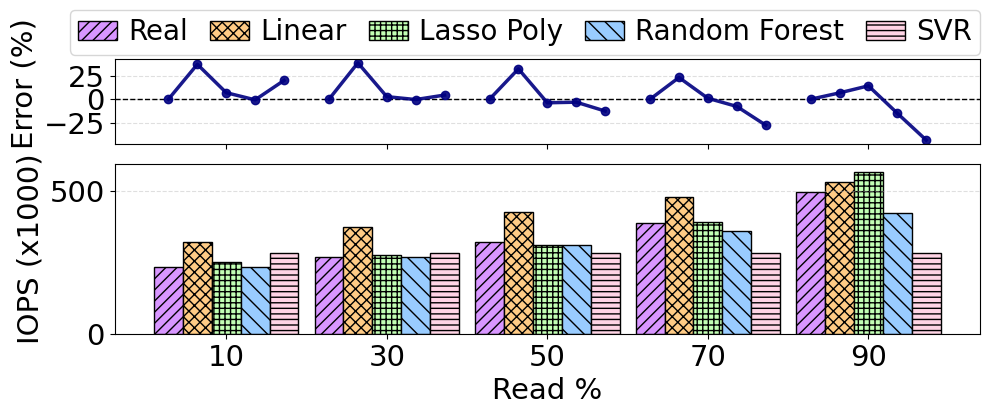

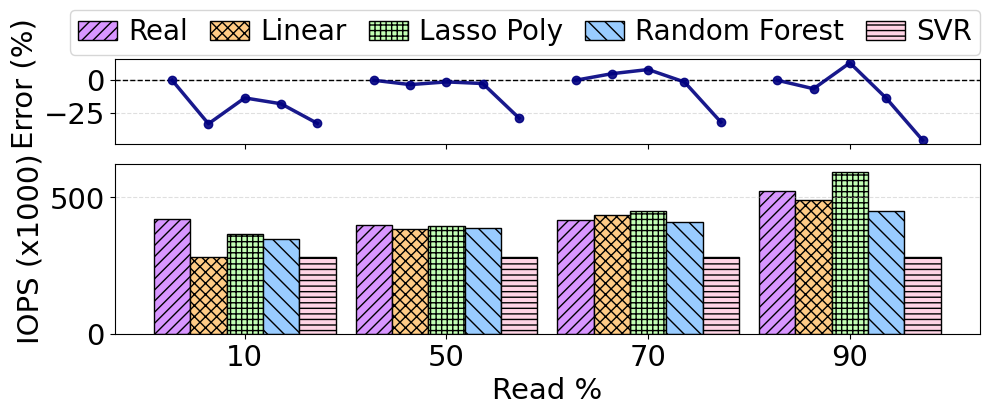

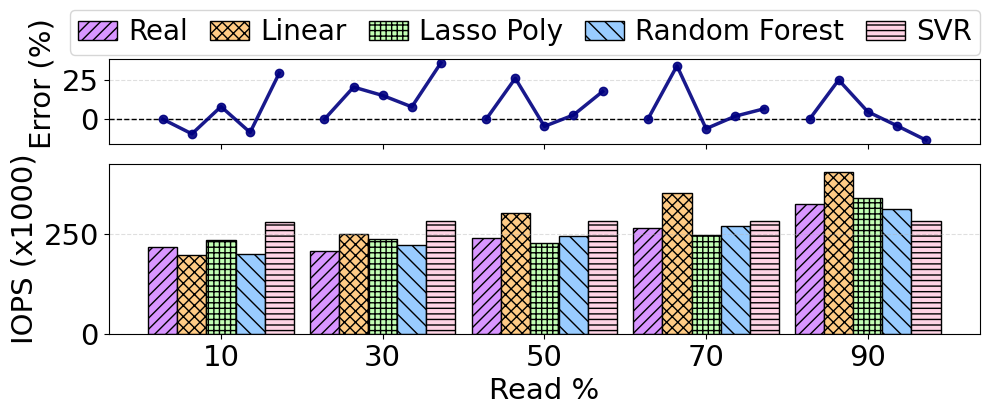

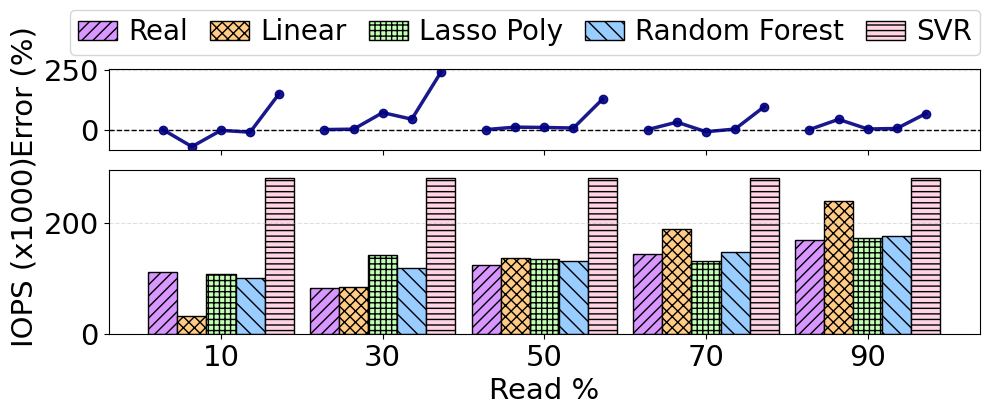

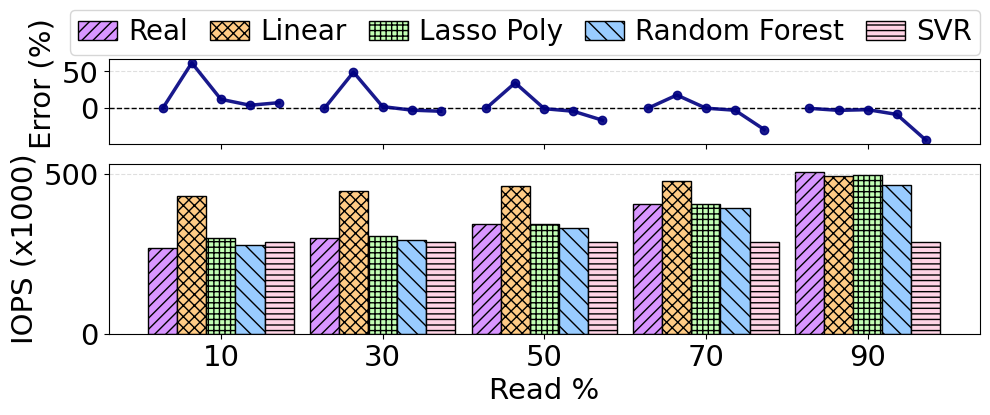

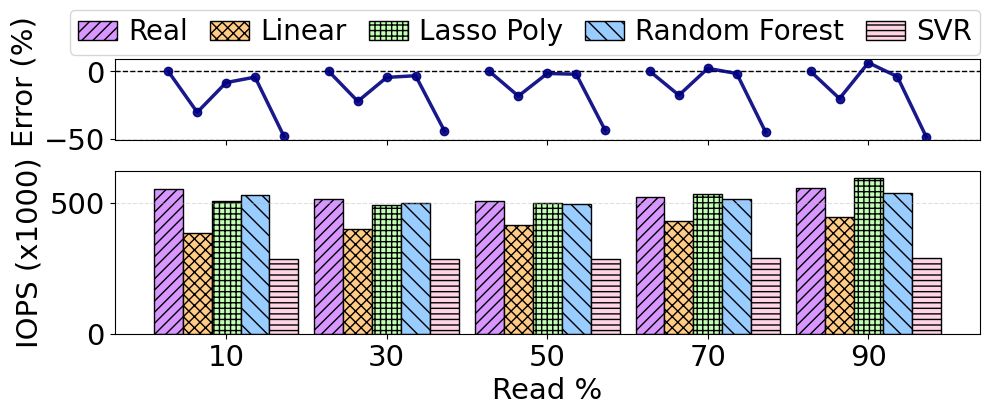

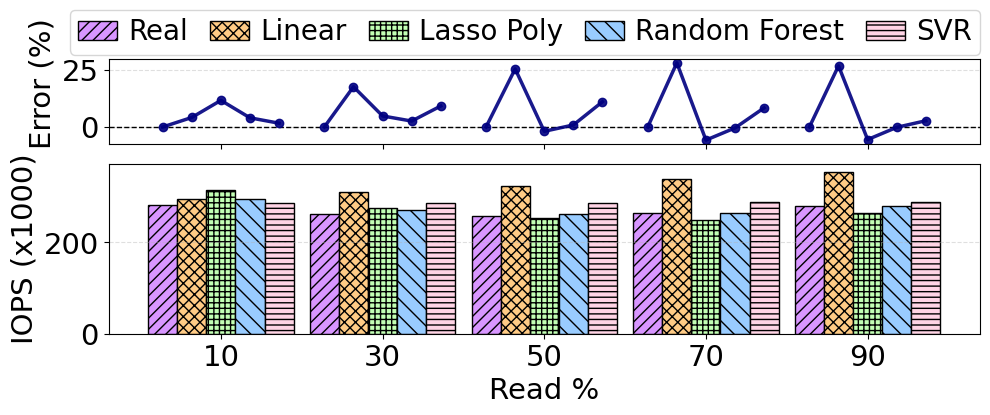

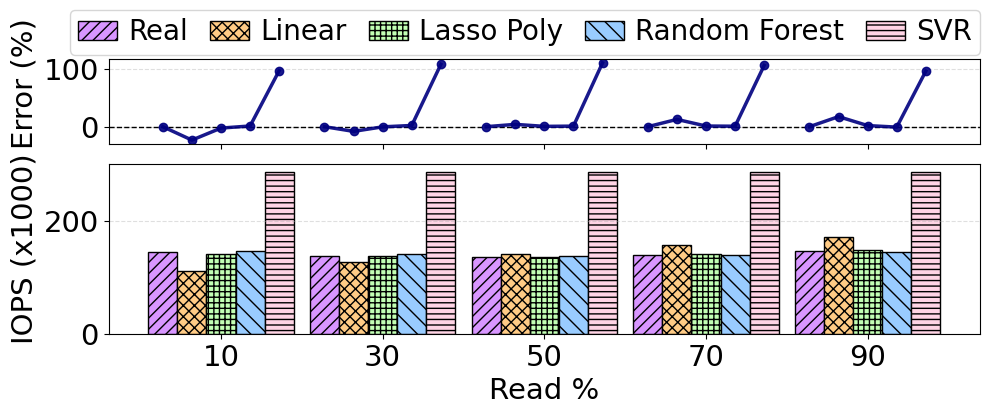

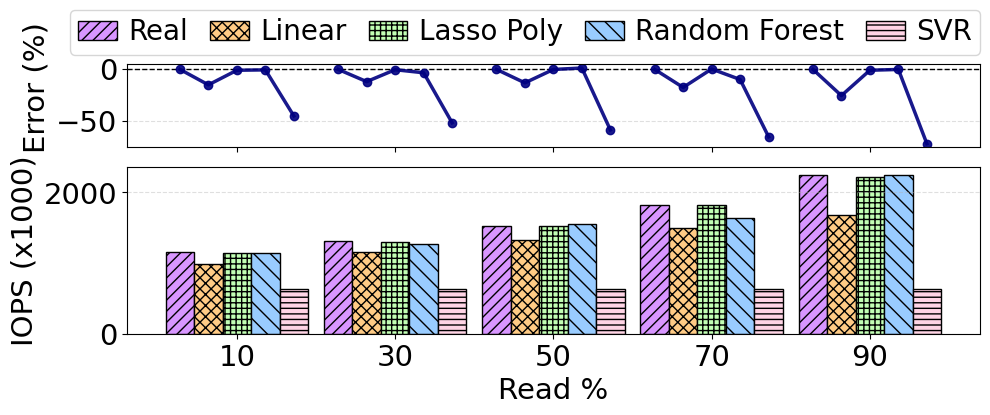

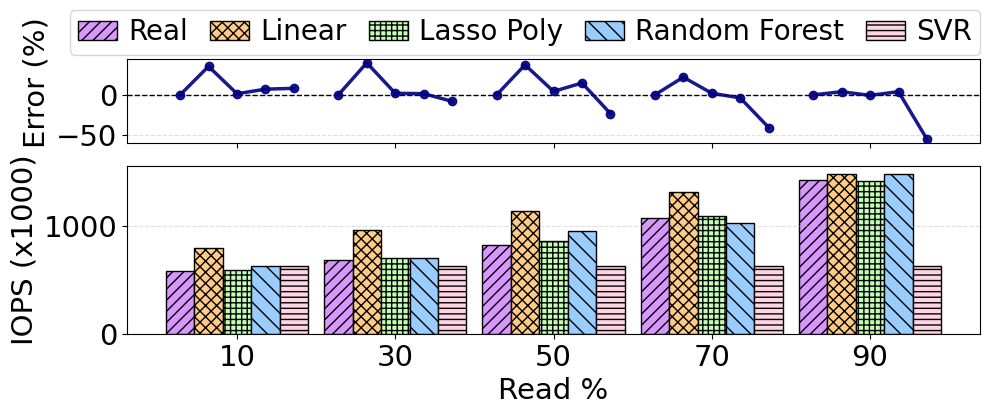

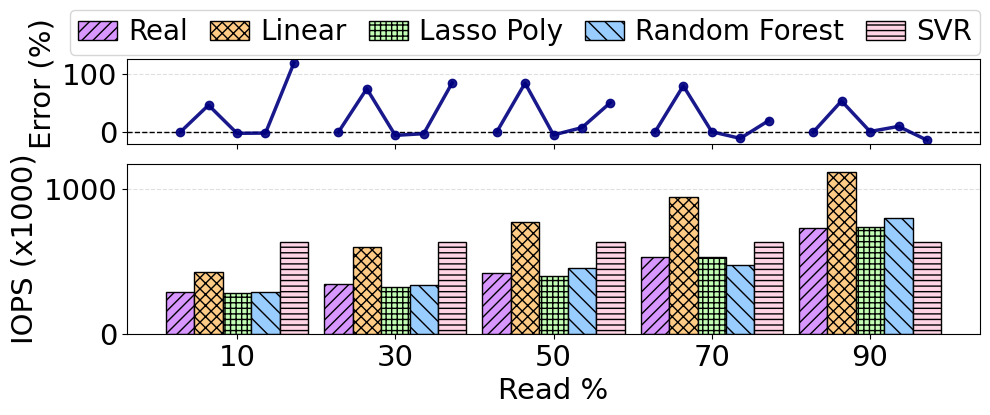

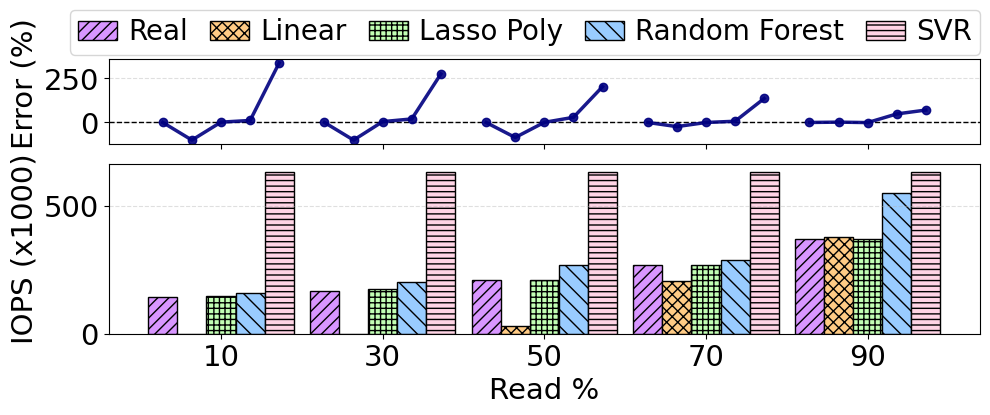

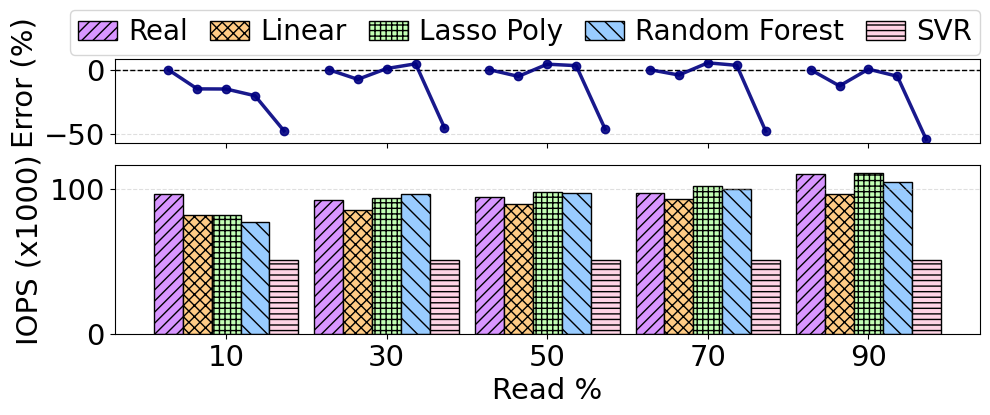

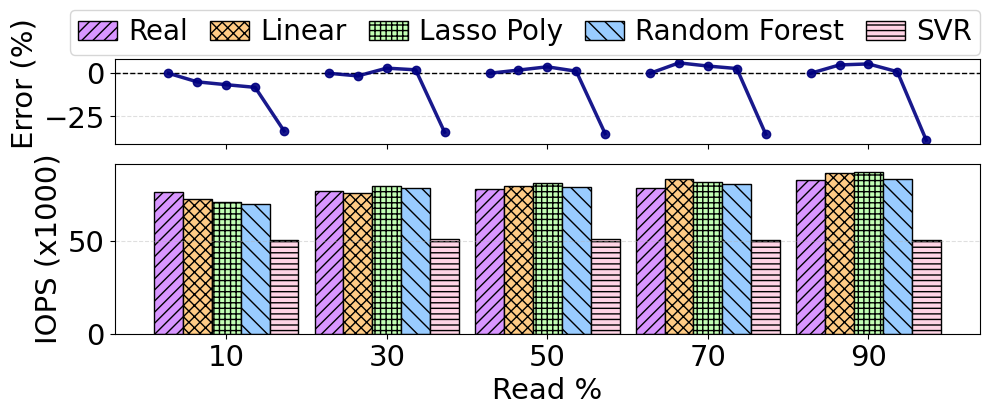

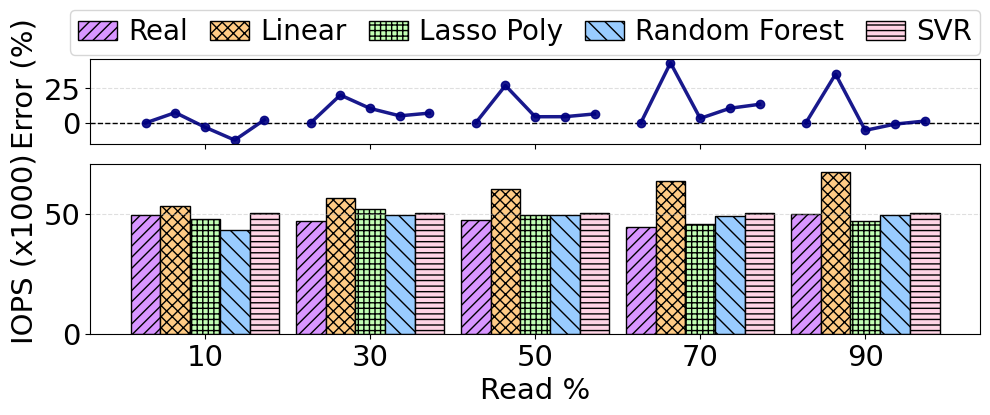

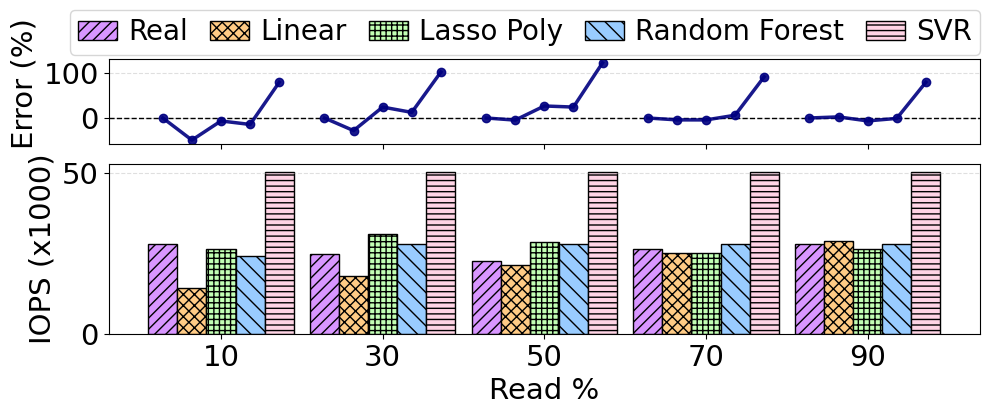


--- 📊 Generating Final Summary Plot ---


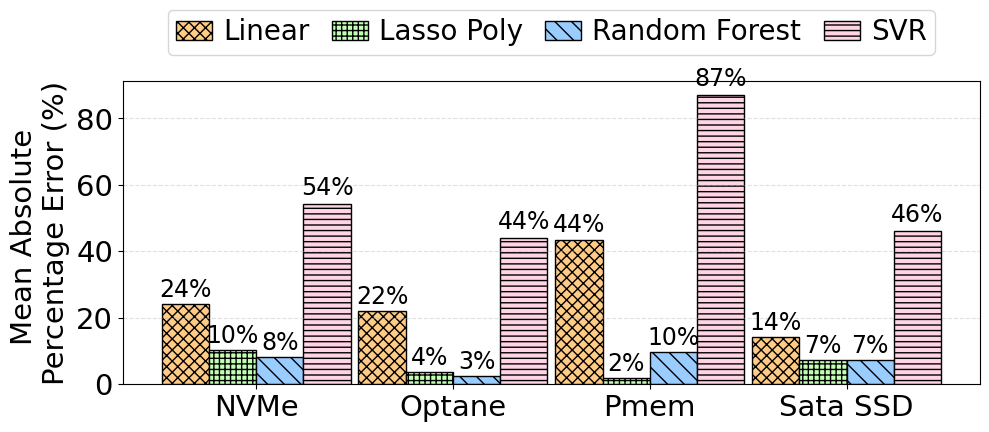

✅ Summary plot saved to barcharts_ordinary/Overall_Error.pdf
✅ Done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import matplotlib.patches as mpatches
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_label': 21,
    'font_size_tick': 21,
    'font_size_legend': 20,
    'plot_dir': 'barcharts_ordinary',
    'plot_ext': 'pdf',
}

# 🔥 NEW OPTIONS
ERROR_PANEL_RATIO = 1.0     # ↑ increase → error plot moves UP
EXPORT_PDF = True           # save PDF + show plot

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# MODELS / STYLES
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5'
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR'
}

# -------------------------------------------------
# DATA LOADING
# -------------------------------------------------
def read_and_prep_data(path, is_test=False):
    try:
        df = pd.read_csv(path, converters={'job options/bs': str}, encoding='latin1')
    except:
        df = pd.read_excel(path, converters={'job options/bs': str})

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)

    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0
    df.loc[(df['job options/rw'] == 'randrw') & df['read_percent'].isna(), 'read_percent'] = 50
    df['read_percent'] = df['read_percent'].fillna(100)

    if is_test:
        df['actual_total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)
        return df

    agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
    df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()
    meta = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates()
    return pd.merge(df_agg, meta, on=agg_cols, how='left')

def engineer_features(df):
    df = df.copy()
    df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
    df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
    df['device'] = df['device'].fillna('unknown')
    return df

# -------------------------------------------------
# TRAIN / PREDICT
# -------------------------------------------------
def train_models(df, features):
    models = {}
    for dev in df['device'].unique():
        if dev == 'unknown':
            continue

        sub = df[df['device'] == dev]
        if len(sub) < 5:
            continue

        X = sub[features]
        y = sub['total_iops']

        models[dev] = {
            'LINEAR': Pipeline([('s', StandardScaler()), ('m', LinearRegression())]),
            'LASSO_POLY': Pipeline([
                ('p', PolynomialFeatures(HYPERPARAMS['lasso_degree'], include_bias=False)),
                ('s', StandardScaler()),
                ('m', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
            ]),
            'RANDOM_FOREST': Pipeline([
                ('s', StandardScaler()),
                ('m', RandomForestRegressor(
                    n_estimators=HYPERPARAMS['rf_n_estimators'],
                    max_depth=HYPERPARAMS['rf_max_depth'],
                    min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                    random_state=42))
            ]),
            'SVR': Pipeline([('s', StandardScaler()), ('m', SVR(C=100))])
        }

        for m in models[dev].values():
            m.fit(X, y)

    return models

def evaluate_and_predict(df, models, features):
    out = []
    for dev, dev_models in models.items():
        sub = df[df['device'] == dev]
        if sub.empty:
            continue

        X = sub[features]
        res = sub[['device', 'read_percent', 'block_size_kb']].copy()
        res['Actual'] = sub['actual_total_iops']

        for name, model in dev_models.items():
            pred = model.predict(X)
            pred[pred < 0] = 0
            res[name] = pred

        out.append(res)

    return pd.concat(out, ignore_index=True) if out else None

# -------------------------------------------------
# PLOTTING (2×1 GRID)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):

    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        # 🔥 dynamic panel sizing
        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(10, 4),
            sharex=True,
            gridspec_kw={
                'height_ratios': [ERROR_PANEL_RATIO, 2.0]
            }
        )

        bar_w = 0.18
        offsets = (np.arange(len(MODEL_ORDER)) - 2) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        # ax_err.yaxis.tick_right()
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].values / 1000,
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        # fig.legend(
        #     handles=legend_handles,
        #     loc='upper center',
        #     bbox_to_anchor=(0.5, 1.06),
        #     ncol=5,
        #     fontsize=CONFIG['font_size_legend'],
        #     frameon=True
        # )
        fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.53, 1.06),
        ncol=5,
        fontsize=CONFIG['font_size_legend'],
        frameon=True,

        handlelength=1.4,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )


        plt.tight_layout(rect=[0, 0, 1, 0.94])

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.show()
        plt.close()

# -------------------------------------------------
# SUMMARY PLOT (FIXED FOREVER)
# -------------------------------------------------
def create_summary_plot(results_df, bar_width=0.24):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem',
        'sda': 'Sata SSD'
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    # ✅ FIX: symmetric centered offsets
    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals = plot_df[plot_df['Model'] == m]['APE'].values

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        # Exact error labels
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + ax.get_ylim()[1] * 0.015,
                f"{h:.0f}%",
                ha='center',
                va='bottom',
                fontsize=CONFIG['font_size_tick'] - 4
            )

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.28),
        ncol=4,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"✅ Summary plot saved to {fname}")


# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    TRAIN = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices.xlsx"
    TEST  = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/limit100.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']

    train = engineer_features(read_and_prep_data(TRAIN, False))
    test  = engineer_features(read_and_prep_data(TEST, True))

    models = train_models(train, FEATURES)
    res = evaluate_and_predict(test, models, FEATURES)

    if res is not None:
        agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean()
        create_plots(agg)
        create_summary_plot(agg)
        print("✅ Done")

if __name__ == "__main__":
    main()


# 📊 **Script: Mentor's Visualization with Generalization Logic**

## 🎯 **Overview**
This script merges the **advanced 2-panel visualization style** (created by the mentor) with our **new Block-Size Generalization logic**. It evaluates how well the models can predict unseen, non-standard block sizes by learning only from standard power-of-2 block sizes.

## ⚙️ **Methodology**
* **Data Source:** Unified `AllDevices2.xlsx` file.
* **Exclusion:** The `sata` device is filtered out.
* **Train/Test Split:**
  * **Train:** Standard block sizes (`2, 4, 8, 16, 32, 64, 128` KB).
  * **Test:** Non-standard block sizes.
* **Visualization (Mentor's Layout):**
  * **Top Panel:** Percentage Error plot for each model across different read/write mixes.
  * **Bottom Panel:** Hatched bar charts comparing Actual vs. Predicted IOPS.
  * **Summary Plot:** A cleanly formatted bar chart showing the Mean Absolute Percentage Error (MAPE) for each device and model.

In [ ]:
# New Script Added

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import matplotlib.patches as mpatches
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
CONFIG = {
    'font_size_label': 21,
    'font_size_tick': 21,
    'font_size_legend': 20,
    'plot_dir': 'barcharts_mentor_generalization', # Changed dir to avoid overwriting
    'plot_ext': 'pdf',
}

# 🔥 NEW OPTIONS
ERROR_PANEL_RATIO = 1.0     # ↑ increase → error plot moves UP
EXPORT_PDF = True           # save PDF + show plot

HYPERPARAMS = {
    'lasso_degree': 3,
    'lasso_alpha': 0.1,
    'rf_n_estimators': 100,
    'rf_max_depth': None,
    'rf_min_samples_leaf': 1
}

# -------------------------------------------------
# MODELS / STYLES
# -------------------------------------------------
MODEL_ORDER = ['Actual', 'LINEAR', 'LASSO_POLY', 'RANDOM_FOREST', 'SVR']

HATCH_MAP = {
    'Actual': '///',
    'LINEAR': 'xxx',
    'LASSO_POLY': '+++',
    'RANDOM_FOREST': '\\\\',
    'SVR': '---',
}

BAR_COLORS = {
    'Actual': '#d896ff',
    'LINEAR': '#ffcb85',
    'LASSO_POLY': '#c2ffb4',
    'RANDOM_FOREST': '#99ccff',
    'SVR': '#ffd4e5'
}

LEGEND_LABELS = {
    'Actual': 'Real',
    'LINEAR': 'Linear',
    'LASSO_POLY': 'Lasso Poly',
    'RANDOM_FOREST': 'Random Forest',
    'SVR': 'SVR'
}

# -------------------------------------------------
# DATA LOADING (Updated for Unified Approach)
# -------------------------------------------------
def load_unified_data(path):
    """
    Loads unified data and calculates the maximum IOPS per configuration.
    """
    print(f"Loading data from: {path}")
    try:
        df = pd.read_csv(path, converters={'job options/bs': str}, encoding='latin1')
    except:
        df = pd.read_excel(path, converters={'job options/bs': str})

    df['job options/filename'] = df['job options/filename'].fillna('unknown')
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '').astype(int)

    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
    df.loc[df['job options/rw'] == 'randread', 'read_percent'] = 100
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0
    df.loc[(df['job options/rw'] == 'randrw') & df['read_percent'].isna(), 'read_percent'] = 50
    df['read_percent'] = df['read_percent'].fillna(100)

    # Calculate total IOPS safely
    df['total_iops'] = df['read/iops'].fillna(0) + df['write/iops'].fillna(0)

    print("Aggregating data (MAX strategy per config)...")
    agg_cols = ['job options/filename', 'read_percent', 'block_size_kb']
    df_agg = df.groupby(agg_cols, as_index=False)['total_iops'].max()
    meta = df[agg_cols + ['job options/rw', 'job options/bs']].drop_duplicates()

    return pd.merge(df_agg, meta, on=agg_cols, how='left')

def engineer_features(df):
    df = df.copy()
    df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
    df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
    df['device'] = df['device'].fillna('unknown')

    # 🔥 Exclude 'sata' device as requested
    df = df[df['device'].str.lower() != 'sata']
    return df

# -------------------------------------------------
# TRAIN / PREDICT
# -------------------------------------------------
def train_models(df, features):
    print("\n--- 🚂 Starting Model Training ---")
    models = {}
    for dev in df['device'].unique():
        if dev == 'unknown':
            continue

        sub = df[df['device'] == dev]
        if len(sub) < 3:
            continue

        X = sub[features]
        y = sub['total_iops']

        models[dev] = {
            'LINEAR': Pipeline([('s', StandardScaler()), ('m', LinearRegression())]),
            'LASSO_POLY': Pipeline([
                ('p', PolynomialFeatures(HYPERPARAMS['lasso_degree'], include_bias=False)),
                ('s', StandardScaler()),
                ('m', Lasso(alpha=HYPERPARAMS['lasso_alpha'], max_iter=10000))
            ]),
            'RANDOM_FOREST': Pipeline([
                ('s', StandardScaler()),
                ('m', RandomForestRegressor(
                    n_estimators=HYPERPARAMS['rf_n_estimators'],
                    max_depth=HYPERPARAMS['rf_max_depth'],
                    min_samples_leaf=HYPERPARAMS['rf_min_samples_leaf'],
                    random_state=42))
            ]),
            'SVR': Pipeline([('s', StandardScaler()), ('m', SVR(C=100))])
        }

        for m in models[dev].values():
            m.fit(X, y)

    return models

def evaluate_and_predict(df, models, features):
    print("\n--- 🧪 Starting Prediction on Test Data ---")
    out = []
    for dev, dev_models in models.items():
        sub = df[df['device'] == dev]
        if sub.empty:
            continue

        X = sub[features]
        res = sub[['device', 'read_percent', 'block_size_kb']].copy()

        # Use total_iops as 'Actual' since we unified the pipeline
        res['Actual'] = sub['total_iops']

        for name, model in dev_models.items():
            pred = model.predict(X)
            pred[pred < 0] = 0
            res[name] = pred

        out.append(res)

    return pd.concat(out, ignore_index=True) if out else None

# -------------------------------------------------
# PLOTTING (2×1 GRID)
# -------------------------------------------------
def create_plots(df,
                 error_line_color='navy',
                 error_line_width=2.5,
                 error_line_alpha=0.9):
    print("\n--- 📊 Generating Detailed Grid Plots ---")
    os.makedirs(CONFIG['plot_dir'], exist_ok=True)

    for (dev, bs), g in df.groupby(['device', 'block_size_kb']):
        g = g.sort_values('read_percent')
        reads = g['read_percent'].values
        x = np.arange(len(reads))

        # 🔥 dynamic panel sizing
        fig, (ax_err, ax_bar) = plt.subplots(
            2, 1, figsize=(10, 4),
            sharex=True,
            gridspec_kw={
                'height_ratios': [ERROR_PANEL_RATIO, 2.0]
            }
        )

        bar_w = 0.18
        offsets = (np.arange(len(MODEL_ORDER)) - 2) * bar_w

        # ---------------- ERROR PLOT ----------------
        ax_err.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_err.set_ylabel("    Error (%)", fontsize=CONFIG['font_size_label'])
        ax_err.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_err.yaxis.tick_left()
        ax_err.yaxis.set_label_position("left")

        for wi, rp in enumerate(reads):
            row = g.iloc[wi]
            errors = []

            for m in MODEL_ORDER:
                if m == 'Actual':
                    errors.append(0)
                else:
                    a = row['Actual']
                    p = row[m]
                    errors.append((p - a) / a * 100 if a > 0 else 0)

            ax_err.plot(
                x[wi] + offsets,
                errors,
                marker='o',
                linewidth=error_line_width,
                alpha=error_line_alpha,
                color=error_line_color
            )

        ax_err.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- BAR PLOT ----------------
        for i, m in enumerate(MODEL_ORDER):
            ax_bar.bar(
                x + offsets[i],
                g[m].values / 1000,
                width=bar_w,
                color=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black'
            )

        ax_bar.set_xlabel("Read %", fontsize=CONFIG['font_size_label'])
        ax_bar.set_ylabel("IOPS (x1000)", fontsize=CONFIG['font_size_label'])
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(reads, fontsize=CONFIG['font_size_tick'])
        ax_bar.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ---------------- LEGEND ----------------
        legend_handles = [
            mpatches.Patch(
                facecolor=BAR_COLORS[m],
                hatch=HATCH_MAP[m],
                edgecolor='black',
                label=LEGEND_LABELS[m]
            ) for m in MODEL_ORDER
        ]

        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.53, 1.06),
            ncol=5,
            fontsize=CONFIG['font_size_legend'],
            frameon=True,
            handlelength=1.4,
            handletextpad=0.4,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3
        )

        plt.tight_layout(rect=[0, 0, 1, 0.94])

        if EXPORT_PDF:
            fname = f"{CONFIG['plot_dir']}/bar_error_grid_{dev}_{bs}k.{CONFIG['plot_ext']}"
            plt.savefig(fname, bbox_inches='tight')

        plt.close()

# -------------------------------------------------
# SUMMARY PLOT (FIXED FOREVER)
# -------------------------------------------------
def create_summary_plot(results_df, bar_width=0.24):
    print("\n--- 📊 Generating Final Summary Plot ---")

    model_cols = [m for m in MODEL_ORDER if m != 'Actual']

    DEVICE_LABELS = {
        'nvme0n': 'NVMe',
        'nvme1n': 'Optane',
        'pmem': 'Pmem',
        'sda': 'Sata SSD' # Will be ignored if sata is filtered out, which is fine
    }

    summary = []
    for m in model_cols:
        tmp = results_df[results_df['Actual'] > 0].copy()
        tmp['APE'] = np.abs((tmp[m] - tmp['Actual']) / tmp['Actual']) * 100
        s = tmp.groupby('device')['APE'].mean().reset_index()
        s['Model'] = m
        summary.append(s)

    plot_df = pd.concat(summary, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    devices = plot_df['device'].unique()
    x = np.arange(len(devices))

    bar_w = bar_width
    n_models = len(model_cols)

    # ✅ FIX: symmetric centered offsets
    offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

    for i, m in enumerate(model_cols):
        vals = plot_df[plot_df['Model'] == m]['APE'].values

        bars = ax.bar(
            x + offsets[i],
            vals,
            width=bar_w,
            color=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black'
        )

        # Exact error labels
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + ax.get_ylim()[1] * 0.015,
                f"{h:.0f}%",
                ha='center',
                va='bottom',
                fontsize=CONFIG['font_size_tick'] - 4
            )

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [DEVICE_LABELS.get(d, d) for d in devices],
        fontsize=CONFIG['font_size_tick']
    )

    ax.set_ylabel("Mean Absolute \nPercentage Error (%)", fontsize=CONFIG['font_size_label'])
    ax.tick_params(axis='y', labelsize=CONFIG['font_size_tick'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    legend_handles = [
        mpatches.Patch(
            facecolor=BAR_COLORS[m],
            hatch=HATCH_MAP[m],
            edgecolor='black',
            label=LEGEND_LABELS[m]
        ) for m in model_cols
    ]

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.28),
        ncol=4,
        fontsize=CONFIG['font_size_legend'],
        handlelength=1.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    fname = f"{CONFIG['plot_dir']}/Overall_Error.{CONFIG['plot_ext']}"
    if EXPORT_PDF:
        plt.savefig(fname, bbox_inches='tight')
    plt.close()

    print(f"✅ Summary plot saved to {fname}")


# -------------------------------------------------
# MAIN
# -------------------------------------------------
def main():
    # File Path
    FILE_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx"
    FEATURES = ['read_percent', 'block_size_kb']

    # 1. Load Data
    df_raw = load_unified_data(FILE_PATH)
    if df_raw is None: return

    # 2. Feature Engineering & Filtering
    df_eng = engineer_features(df_raw)

    # 3. Train / Test Split Logic
    print("Splitting Data based on Block Size (Train=Powers of 2, Test=Others)...")
    powers_of_2 = [2, 4, 8, 16, 32, 64, 128]

    train_df = df_eng[df_eng['block_size_kb'].isin(powers_of_2)].copy()
    test_df = df_eng[~df_eng['block_size_kb'].isin(powers_of_2)].copy()

    print(f"  - Train Data Shape: {train_df.shape}")
    print(f"  - Test Data Shape: {test_df.shape}")

    if test_df.empty:
        print("CRITICAL: No testing data found (no block sizes other than powers of 2). Exiting.")
        return

    # 4. Train Models
    models = train_models(train_df, FEATURES)

    # 5. Predict on Test
    res = evaluate_and_predict(test_df, models, FEATURES)

    if res is not None:
        # ✅ FIX: numeric_only=True prevents pandas TypeError during aggregation
        agg = res.groupby(['device', 'block_size_kb', 'read_percent'], as_index=False).mean(numeric_only=True)

        # Output
        agg.to_excel("predictions_mentor_generalization.xlsx", index=False)
        create_plots(agg)
        create_summary_plot(agg)
        print("\n✅ Script Completed Successfully!")

if __name__ == "__main__":
    main()

Loading data from: drive/MyDrive/Sharif/Papers/ISPASS-2026/AllDevices2.xlsx
Aggregating data (MAX strategy per config)...
Splitting Data based on Block Size (Train=Powers of 2, Test=Others)...
  - Train Data Shape: (221, 7)
  - Test Data Shape: (3926, 7)

--- 🚂 Starting Model Training ---

--- 🧪 Starting Prediction on Test Data ---

--- 📊 Generating Detailed Grid Plots ---

--- 📊 Generating Final Summary Plot ---
✅ Summary plot saved to barcharts_mentor_generalization/Overall_Error.pdf

✅ Script Completed Successfully!


In [3]:
# === TRAIN MODELS ON ALLDEVICES ===
TRAIN_PATH = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices.xlsx"
FEATURES = ['read_percent', 'block_size_kb']

train_df = read_and_prep_data(TRAIN_PATH, is_test_file=False)
df_train_eng = engineer_features(train_df)

models = train_models(df_train_eng, FEATURES)   # <- this is the dict we'll use
print("Trained devices:", list(models.keys()))

Loading data from: /Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/AllDevices.xlsx
...Load successful.
Aggregating training data (MAX strategy)...

--- 🚂 Starting Model Training ---
Training models for device: nvme0n
Training models for device: nvme1n
Training models for device: pmem
Training models for device: sda
Trained devices: ['nvme0n', 'nvme1n', 'pmem', 'sda']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the provided data
df = pd.read_excel(
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v5.xlsx",
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v5.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v5.xlsx",
    sheet_name='Sheet1')

# Set the style for the plot
sns.set_theme(style="whitegrid")

# Set up the figure and axis
plt.figure(figsize=(10, 6))

# Plot the IOstat and Ours data
plt.plot(df['TRUE'], df['IOstat'], label='IOstat Utilization', color='red', linewidth=2)
plt.plot(df['TRUE'], df['Ours'], label='Ours Utilization', color='blue', linewidth=2)

# Labeling and styling
plt.xlabel("True", fontsize=14)
plt.ylabel("Utilization (%)", fontsize=14)
plt.title("Comparison of IOstat vs. Ours Utilization", fontsize=16)
plt.legend(fontsize=12)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Set the y-axis scale from 0% to 100%
plt.ylim(0, 100)

# Display the plot
plt.tight_layout()
plt.show()


KeyError: 'TRUE'

<Figure size 1000x600 with 0 Axes>

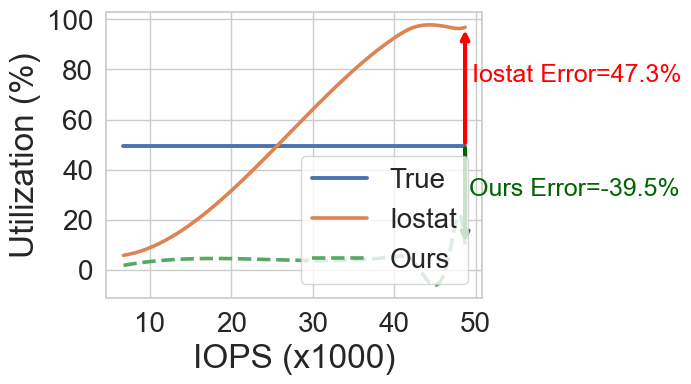

PDF saved as: all_devices_with_lasso.pdf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 20
tick_fontsize = 20
ERROR_TEXT_FONTSIZE = 18

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw10-v1.xlsx",
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD8-v1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING
# -------------------------------------------------------------
devices = df['job options/filename'].unique()
pdf = PdfPages("all_devices_with_lasso.pdf")

for dev_path in devices:
    plt.figure(figsize=(7, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    for rw in ddf['job options/rw'].unique():
        sub = ddf[ddf['job options/rw'] == rw].sort_values("limitation")

        fio_iops = (sub["read/iops"] + sub["write/iops"]) / 1000
        true_util = sub["limitation"]

        iostat_iops = (sub["avg_rps"] + sub["avg_wps"]) / 1000
        iostat_util = sub["avg_util"]

        # ---- Ours (LASSO_POLY) ----
        X = sub[FEATURES].values
        max_iops_pred = lasso_model.predict(X)
        mask = max_iops_pred > 0
        ours_util = (fio_iops.values[mask] * 1000 / max_iops_pred[mask]) * 100

        # ---- Smooth curves ----
        sx_t, sy_t = smooth_curve(fio_iops, true_util)
        sx_i, sy_i = smooth_curve(iostat_iops, iostat_util)
        sx_o, sy_o = smooth_curve(fio_iops.values[mask], ours_util)

        plt.plot(sx_t, sy_t, label="True", linewidth=2.8)
        plt.plot(sx_i, sy_i, label="Iostat", linewidth=2.6)
        plt.plot(sx_o, sy_o, label="Ours", linestyle="--", linewidth=2.6)

        # -------------------------------------------------
        # ERROR ARROWS (TWO)
        # -------------------------------------------------
        if error_point_index < len(fio_iops) and error_point_index < len(ours_util):
            x_true = float(fio_iops.iloc[error_point_index])
            y_true = float(true_util.iloc[error_point_index])

            x_io = float(iostat_iops.iloc[error_point_index])
            y_io = float(iostat_util.iloc[error_point_index])
            err_io = y_io - y_true

            y_ours = float(ours_util[error_point_index])
            err_ours = y_ours - y_true

            # Iostat → True
            plt.annotate(
                "",
                xy=(x_io, y_io),
                xytext=(x_true, y_true),
                arrowprops=dict(arrowstyle="->", lw=3, color=ERROR_COLOR_IOSTAT),
            )
            plt.text(
                (x_true + x_io) / 2,
                (y_true + y_io) / 2 + 2,
                f" Iostat Error={err_io:.1f}%",
                color=ERROR_COLOR_IOSTAT,
                fontsize=ERROR_TEXT_FONTSIZE,
            )

            # Ours → True
            plt.annotate(
                "",
                xy=(x_true, y_ours),
                xytext=(x_true, y_true),
                arrowprops=dict(arrowstyle="->", lw=3, color=ERROR_COLOR_OURS),
            )
            plt.text(
                x_true + 0.5,
                (y_true + y_ours) / 2,
                f"Ours Error={err_ours:.1f}%",
                color=ERROR_COLOR_OURS,
                fontsize=ERROR_TEXT_FONTSIZE,
            )

    # -------------------------------------------------
    # AXES & EXPORT
    # -------------------------------------------------
    plt.xlabel("IOPS (x1000)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.legend(fontsize=legend_fontsize)
    plt.tight_layout()

    pdf.savefig()
    plt.show()

pdf.close()
print("PDF saved as: all_devices_with_lasso.pdf")


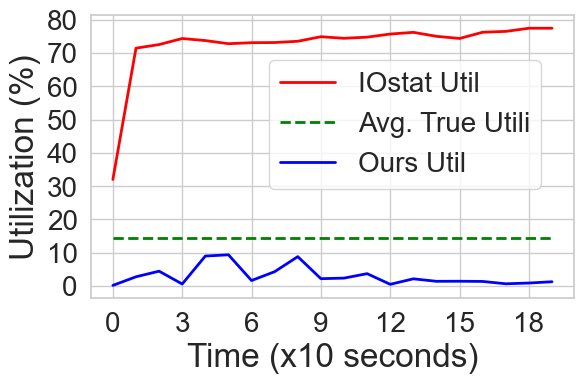

PDF saved as: all_devices_with_lasso.pdf
Prediction values saved to 'predictions_for_each_state.csv'


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v5.xlsx",
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v5.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v5.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v1.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v2.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v3.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v4.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD8-v1.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v3.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD8-v1.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v1.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD8-v1.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v1.xlsx",
    # "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v3.xlsx",

    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A667_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)  # Center the legend at the top
    # plt.title(f"{dev_name}, QD=1, Avg {np.mean(fio_iops):.1f} KIOPS", fontsize=title_fontsize)
    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------

# Store predictions for later
predictions_df = pd.DataFrame({
    'Device': ddf['device'],
    'Block Size (KB)': ddf['block_size_kb'],
    'Read Percent': ddf['read_percent'],
    'RW Mix': ddf['job options/rw'],
    'True IOPS': fio_iops,
    'True Utilization (%)': true_util,
    'Predicted IOPS': max_iops_pred,
    'Predicted Utilization (%)': ours_util
})

# Save to a CSV file for review
predictions_df.to_csv('predictions_for_each_state.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state.csv'")


**New Script Added**


Loading saved models from: saved_models_60_40.joblib
Processing benchmark file: drive/MyDrive/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v1.xlsx


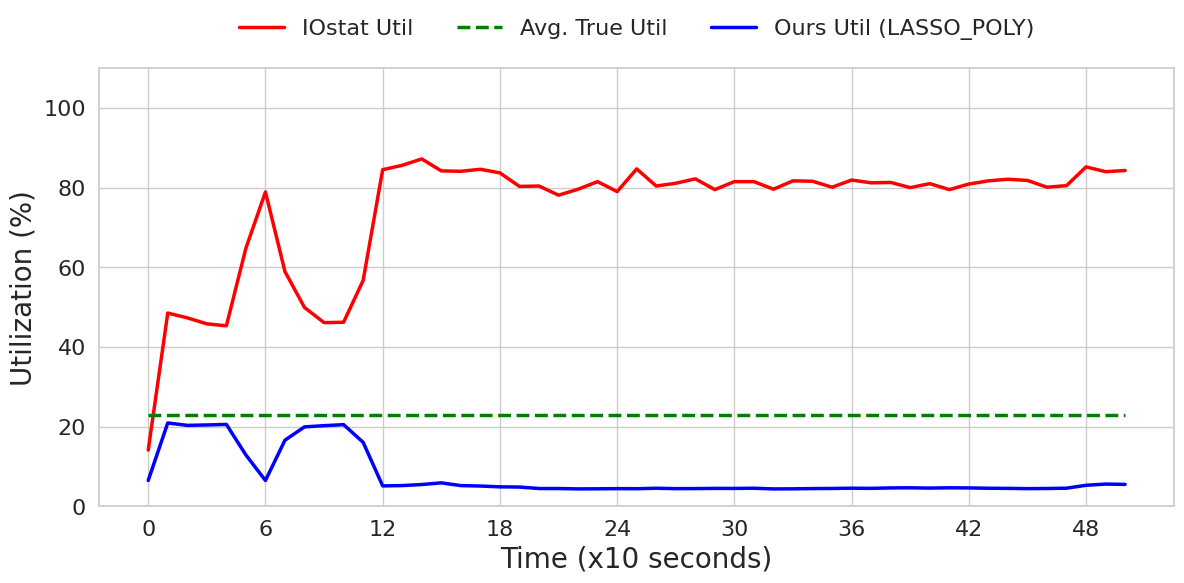

PDF saved as: drive/MyDrive/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v1_LASSO_POLY_plot.pdf
Prediction values saved to 'drive/MyDrive/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v1_LASSO_POLY_predictions.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE & FONT SIZES
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")
axis_label_fontsize = 20  # کمی متعادل‌تر شد تا از کادر بیرون نزند
legend_fontsize = 16
tick_fontsize = 16
iostat_color = 'red'
true_util_color = 'green'
ours_color = 'blue'

# -------------------------------------------------------------
# BENCHMARK EVALUATION
# -------------------------------------------------------------
def process_benchmark(benchmark_file, saved_models_file, target_model="RANDOM_FOREST"):
    print(f"\nLoading saved models from: {saved_models_file}")
    try:
        models = joblib.load(saved_models_file)
    except Exception as e:
        print(f"CRITICAL: Could not load models. Did you run the training script first? Error: {e}")
        return

    print(f"Processing benchmark file: {benchmark_file}")
    df = pd.read_excel(benchmark_file, sheet_name=0)

    # Feature Engineering for Benchmark Data
    df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)
    df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
    df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
    df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
    df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
    df['read_percent'] = df['read_percent'].fillna(100.0)

    df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
    df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
    df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
    df['device'] = df['device'].fillna('unknown')

    FEATURES = ['read_percent', 'block_size_kb']

    pdf_name = benchmark_file.replace('.xlsx', f'_{target_model}_plot.pdf')
    pdf = PdfPages(pdf_name)
    all_predictions = []

    for dev_path in df['job options/filename'].unique():
        # 🔥 تغییر ۱: بزرگتر کردن کادر تصویر
        plt.figure(figsize=(12, 6))

        ddf = df[df['job options/filename'] == dev_path].copy()
        dev_name = ddf['device'].iloc[0]

        dev_models = models.get(dev_name, {})
        chosen_model = dev_models.get(target_model, None)

        if chosen_model is None:
            print(f"Warning: No trained '{target_model}' found for device '{dev_name}'. Skipping.")
            plt.close()
            continue

        time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
        fio_iops = (ddf["read/iops"].fillna(0) + ddf["write/iops"].fillna(0))
        true_util = ddf["limitation"]
        iostat_util = ddf["avg_util"]

        # ---- PREDICTION ----
        X = ddf[FEATURES].values
        max_iops_pred = chosen_model.predict(X)
        mask = max_iops_pred > 0
        ours_util = np.zeros(len(fio_iops))
        ours_util[mask] = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

        # Plotting
        plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2.5)
        plt.plot(time_axis, true_util, label="Avg. True Util", color=true_util_color, linestyle='--', linewidth=2.5)
        plt.plot(time_axis[mask], ours_util[mask], label=f"Ours Util ({target_model})", color=ours_color, linewidth=2.5)

        # Labels & Ticks
        plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
        plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
        plt.xticks(fontsize=tick_fontsize)
        plt.yticks(fontsize=tick_fontsize)
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

        # 🔥 تغییر ۲: تنظیم سقف محور Y برای جلوگیری از چسبیدن خطوط به بالا
        plt.ylim(0, max(110, max(iostat_util.max(), ours_util.max()) + 10))

        # 🔥 تغییر ۳: انتقال Legend به بیرون از کادر نمودار (بالای تصویر)
        plt.legend(
            fontsize=legend_fontsize,
            loc='lower center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=3,
            frameon=False # حذف کادر دور راهنما برای زیبایی بیشتر
        )

        plt.tight_layout()

        pdf.savefig()
        plt.show()

        # Collect data for CSV
        pred_df = pd.DataFrame({
            'Device': ddf['device'],
            'Block Size (KB)': ddf['block_size_kb'],
            'Read Percent': ddf['read_percent'],
            'Time': time_axis,
            'True IOPS': fio_iops,
            'True Utilization (%)': true_util,
            f'Predicted Max IOPS ({target_model})': max_iops_pred,
            'Predicted Utilization (%)': ours_util
        })
        all_predictions.append(pred_df)

    pdf.close()
    print(f"PDF saved as: {pdf_name}")

    if all_predictions:
        final_csv_df = pd.concat(all_predictions, ignore_index=True)
        csv_name = benchmark_file.replace('.xlsx', f'_{target_model}_predictions.csv')
        final_csv_df.to_csv(csv_name, index=False)
        print(f"Prediction values saved to '{csv_name}'")

# -------------------------------------------------------------
# MAIN
# -------------------------------------------------------------
if __name__ == "__main__":
    SAVED_MODELS = "saved_models_60_40.joblib"
    BENCHMARK_FILE = "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v1.xlsx"
    TARGET_MODEL = "LASSO_POLY"

    process_benchmark(BENCHMARK_FILE, SAVED_MODELS, TARGET_MODEL)

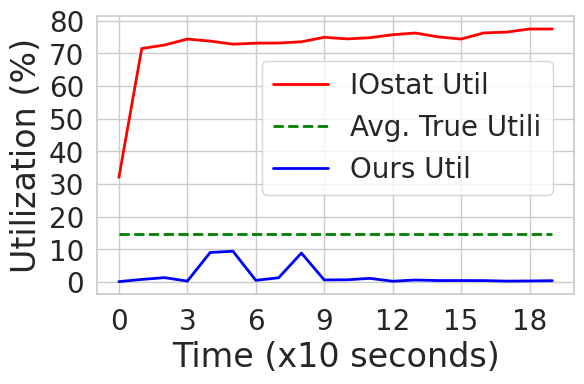

PDF saved as: evaluation_results_nvme_real_A667_QD1_interpolated.pdf
Prediction values saved to 'predictions_for_each_state_interpolated.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 20
tick_fontsize = 20
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v5.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
# حذف k و تبدیل به عدد
df['block_size_kb'] = df['job options/bs'].astype(str).str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].astype(str).str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# ✨ NEW FUNCTION: INTERPOLATED PREDICTION ✨
# -------------------------------------------------------------
def predict_with_interpolation(model, X_input):
    """
    این تابع به جای پیش‌بینی مستقیم روی نقاط پرت (مثل 23KB)،
    نقاط استاندارد اطراف آن (16KB و 32KB) را پیدا کرده و میانگین‌گیری خطی می‌کند.
    """
    # لیست نقاطی که مدل روی آن‌ها آموزش دیده است (استانداردها)
    # اگر در داده‌های ترین 2k هم داشتی، اینجا اضافه کن
    ANCHOR_BS = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
    ANCHOR_BS = sorted(ANCHOR_BS)

    predictions = []

    # X_input یک آرایه است: ستون 0=read_percent, ستون 1=block_size
    for row in X_input:
        r_pct = row[0]
        bs = row[1]

        # اگر بلاک سایز دقیقا یکی از استانداردها بود، مستقیم پیش‌بینی کن
        if bs in ANCHOR_BS:
            pred = model.predict([[r_pct, bs]])[0]

        else:
            # پیدا کردن همسایه‌ها
            lower_bs = None
            upper_bs = None

            for anchor in ANCHOR_BS:
                if anchor < bs:
                    lower_bs = anchor
                if anchor > bs and upper_bs is None:
                    upper_bs = anchor

            # مدیریت نقاط خارج از محدوده (کوچکتر از 4 یا بزرگتر از 4096)
            if lower_bs is None: # مثلا bs=2
                pred = model.predict([[r_pct, bs]])[0]
            elif upper_bs is None: # مثلا bs=5000
                 pred = model.predict([[r_pct, bs]])[0]
            else:
                # درونیابی خطی (Linear Interpolation)
                # محاسبه مقدار برای همسایه پایین (مثلا 16)
                pred_lower = model.predict([[r_pct, lower_bs]])[0]
                # محاسبه مقدار برای همسایه بالا (مثلا 32)
                pred_upper = model.predict([[r_pct, upper_bs]])[0]

                # فرمول خط: y = y1 + (x - x1) * (y2 - y1) / (x2 - x1)
                slope = (pred_upper - pred_lower) / (upper_bs - lower_bs)
                pred = pred_lower + (bs - lower_bs) * slope

        predictions.append(pred)

    return np.array(predictions)

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A667_QD1_interpolated.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'
ours_color = 'blue'

# Define the legend position
legend_bbox_to_anchor = (0.65, .89)

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    if ddf.empty:
        plt.close()
        continue

    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)

    if lasso_model is None:
        print(f"Skipping {dev_name} - Model not found")
        plt.close()
        continue

    # Time axis
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY WITH INTERPOLATION) ----
    X = ddf[FEATURES].values

    # 🔥 CHANGE IS HERE: Use interpolation function instead of direct predict 🔥
    max_iops_pred = predict_with_interpolation(lasso_model, X)

    # Avoid division by zero or negative predictions
    max_iops_pred[max_iops_pred <= 0] = 1

    mask = max_iops_pred > 0
    ours_util = (fio_iops.values / max_iops_pred) * 100

    # Plotting lines
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)
    plt.plot(time_axis, ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()

    plt.show()

if save_as_pdf:
    pdf.close()
    print("PDF saved as: evaluation_results_nvme_real_A667_QD1_interpolated.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
predictions_df = pd.DataFrame({
    'Device': ddf['device'],
    'Block Size (KB)': ddf['block_size_kb'],
    'Read Percent': ddf['read_percent'],
    'RW Mix': ddf['job options/rw'],
    'True IOPS': fio_iops,
    'True Utilization (%)': true_util,
    'Predicted IOPS': max_iops_pred, # Note: using interpolated values
    'Predicted Utilization (%)': ours_util
})

# Save to a CSV file for review
predictions_df.to_csv('predictions_for_each_state_interpolated.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state_interpolated.csv'")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages

# -------------------------------------------------------------
# STYLE (matches attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT CONFIG
# -------------------------------------------------------------
AXIS_LABEL_FONTSIZE = 22
TICK_FONTSIZE = 22
LEGEND_FONTSIZE = 20
ERROR_TEXT_FONTSIZE = 21

ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "blue"

# -------------------------------------------------------------
# LOAD DATA (choose ONE)
# -------------------------------------------------------------

# Optane
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_8k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_16k_rw90-v1.xlsx", sheet_name=0)

# NVMe
df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_16k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_8k_rw70-v1.xlsx", sheet_name=0)

# -------------------------------------------------------------
# FEATURE ENGINEERING (same as training)
# -------------------------------------------------------------
df["block_size_kb"] = df["job options/bs"].str.replace("k", "", regex=False).astype(int)

df["read_percent"] = pd.to_numeric(df["job options/rwmixread"], errors="coerce")
df.loc[df["job options/rw"] == "randread", "read_percent"] = 100
df.loc[df["job options/rw"] == "randwrite", "read_percent"] = 0
df.loc[(df["job options/rw"] == "randrw") & df["read_percent"].isna(), "read_percent"] = 50
df["read_percent"] = df["read_percent"].fillna(100)

df["device"] = df["job options/filename"].str.extract(r"/dev/(\w+)")
df["device"] = df["device"].str.replace(r"\d+$", "", regex=True)
df["device"] = df["device"].str.replace(r"n\d+$", "", regex=True)
df["device"] = df["device"].fillna("unknown")

FEATURES = ["read_percent", "block_size_kb"]

# -------------------------------------------------------------
# SMOOTH CURVE
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    if len(x) < 4:
        return x, y
    x_new = np.linspace(min(x), max(x), n)
    spline = make_interp_spline(x, y, k=3)
    return x_new, spline(x_new)

# -------------------------------------------------------------
# MAX ERROR INDEX (ROBUST)
# -------------------------------------------------------------
def max_error_index(y_true, y_pred):
    errors = np.abs(y_pred - y_true)
    return int(np.argmax(errors))

# -------------------------------------------------------------
# PLOTTING
# -------------------------------------------------------------
devices = df["job options/filename"].unique()
pdf = PdfPages("evaluation_results_optane_4k_rw10.pdf")

for dev_path in devices:
    plt.figure(figsize=(6, 4))
    ddf = df[df["job options/filename"] == dev_path].sort_values("limitation")

    dev_name = ddf["device"].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY")

    if lasso_model is None:
        plt.close()
        continue

    fio_iops = (ddf["read/iops"] + ddf["write/iops"]) / 1000
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"]) / 1000
    iostat_util = ddf["avg_util"]

    # ---- Ours utilization ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] * 1000 / max_iops_pred[mask]) * 100

    # ---- Smooth curves ----
    sx_t, sy_t = smooth_curve(fio_iops, true_util)
    sx_i, sy_i = smooth_curve(iostat_iops, iostat_util)
    sx_o, sy_o = smooth_curve(fio_iops.values[mask], ours_util)

    plt.plot(sx_t, sy_t, label="True", linewidth=2.5)
    plt.plot(sx_i, sy_i, label="Iostat", linewidth=2.5)
    plt.plot(sx_o, sy_o, label="Ours", linewidth=2.5, linestyle="--")

    # ---------------------------------------------------------
    # AUTOMATIC ERROR SELECTION
    # ---------------------------------------------------------

    # Iostat max error
    idx_iostat = max_error_index(true_util.values, iostat_util.values)
    x1, y1 = fio_iops.iloc[idx_iostat], true_util.iloc[idx_iostat]
    x2, y2 = iostat_iops.iloc[idx_iostat], iostat_util.iloc[idx_iostat]
    err_iostat = y2 - y1

    plt.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=3, color=ERROR_COLOR_IOSTAT),
    )
    plt.text(
        (x1 + x2) / 2,
        (y1 + y2) / 2 + 2,
        f" IOstat Error={err_iostat:.1f}%",
        color=ERROR_COLOR_IOSTAT,
        fontsize=ERROR_TEXT_FONTSIZE,
        ha="left",
    )


    # Ours max error
    idx_ours = max_error_index(true_util.values[mask], ours_util)
    xo, yt = fio_iops.values[mask][idx_ours], true_util.values[mask][idx_ours]
    yo = ours_util[idx_ours]
    err_ours = yo - yt

    plt.annotate(
        "",
        xy=(xo, yo),
        xytext=(xo, yt),
        arrowprops=dict(arrowstyle="->", lw=3, color=ERROR_COLOR_OURS),
    )
    # plt.text(
    #     xo + 0.5,
    #     (yo + yt) / 2,
    #     f"Ours Error={err_ours:.1f}%",
    #     color=ERROR_COLOR_OURS,
    #     fontsize=ERROR_TEXT_FONTSIZE,
    # )

    plt.text(
    xo, yo,
    f"Ours Error={err_ours:.1f}%",
    color="blue",
    fontsize=ERROR_TEXT_FONTSIZE,
    ha="right",     # ⬅ end at (xo, yo)
    va="top"
    )


    # ---------------------------------------------------------
    # FORMATTING
    # ---------------------------------------------------------
    plt.xlabel("IOPS (x1000)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel("Utilization (%)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.tight_layout()

    pdf.savefig()
    plt.show()
    plt.close()

pdf.close()
print("✅ PDF saved as: all_devices_utilization_errors.pdf")


ValueError: Expect x to be a 1D strictly increasing sequence.

<Figure size 600x400 with 0 Axes>

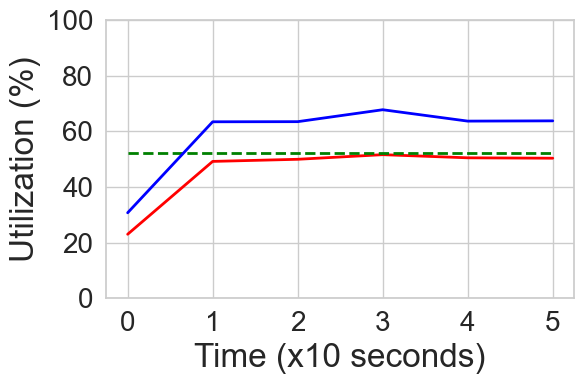

PDF saved as: all_devices_with_lasso.pdf
Prediction values saved to 'predictions_for_each_state_42.csv'


In [ ]:
#42
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A42_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
# df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A42_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state_42.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state_42.csv'")

✅ Successfully loaded 60/40 models from disk.


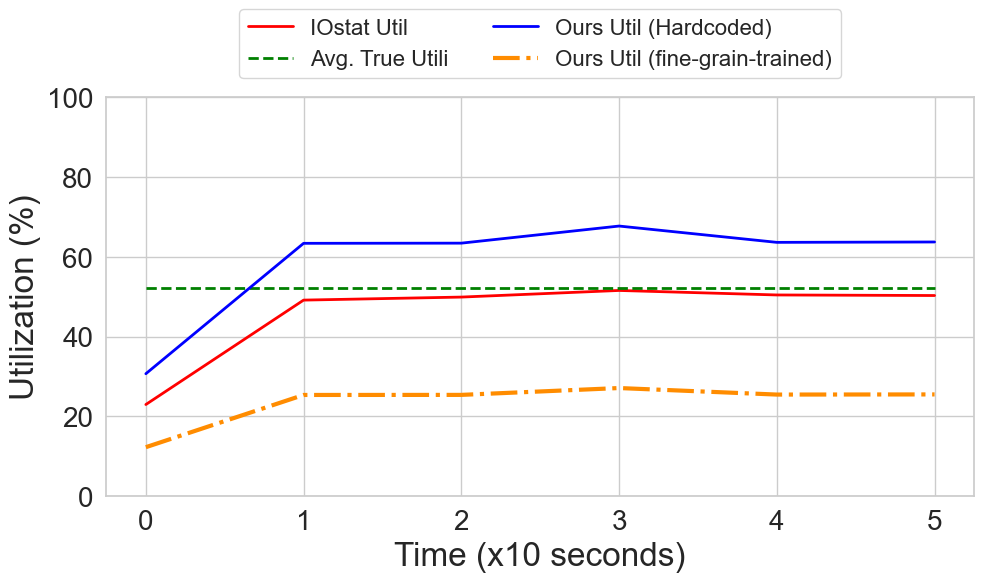

✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf
✅ Prediction values saved to 'predictions_for_each_state_comparison.csv'


In [64]:
# Final workload #42


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib # برای لود کردن مدل جدید
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 16  # کمی کوچکتر شد تا در کادر جا شود
tick_fontsize = 20
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A42_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A42_QD1.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ جدید برای مدل 60/40 که کاملا متمایز است

# Hardcoded values (from user)
predicted_values = [
    30.71919714, 63.41900943, 63.46192839, 67.7510765, 63.66108931, 63.75432706
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # برای خروجی تمیزتر CSV

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(10, 6)) # کمی عریض تر برای جا شدن لِجِند

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- گرفتن مدل قبلی از رم (مطابق درخواست شما) ---
    # فرض بر این است که متغیر models در محیط کولب شما زنده است
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        print("Warning: Variable 'models' not found in memory. Skipping old model.")
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل قدیمی (جهت خروجی اکسل) ---
    max_iops_pred_old = np.zeros(len(fio_iops))
    ours_util_old = np.zeros(len(fio_iops))
    if lasso_model_old is not None:
        max_iops_pred_old = lasso_model_old.predict(X)
        mask_old = max_iops_pred_old > 0
        ours_util_old[mask_old] = (fio_iops.values[mask_old] / max_iops_pred_old[mask_old]) * 100

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)

    # 1. رسم مقادیر هاردکد شده شما
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2)

    # 2. رسم مدل 60/40 جدید
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain-trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان با کل دیتافریم یکی نیست، با NaN پر میکنیم تا سایزش یکی شود
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_comparison.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

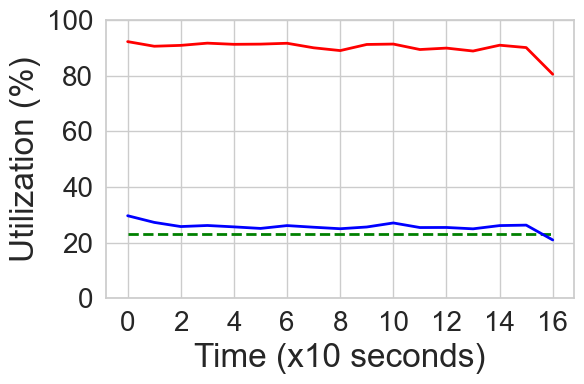

PDF saved as: all_devices_with_lasso.pdf
Saved 17 rows to 'predictions_for_each_state_FIUMail_J4_QD1.csv'


In [4]:
#FIUMail_1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_FIUMail_J4_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
# df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_FIUMail_J4_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    max_iops_pred_raw = lasso_model.predict(X)
    max_iops_pred = np.maximum(max_iops_pred_raw, 1.0)  # Force ≥ 1
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT ALL PREDICTIONS TO CSV (32 rows expected)
# -------------------------------------------------------------
all_predictions = []

for dev_path in df['job options/filename'].dropna().unique():
    ddf = df[df['job options/filename'] == dev_path].copy()
    if ddf.empty:
        continue

    dev_name = ddf['device'].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        print(f"Skipping device (no model): {dev_name}")
        continue

    # Feature matrix
    X = ddf[FEATURES].values
    try:
        max_iops_pred = lasso_model.predict(X)
    except Exception as e:
        print(f"Error predicting for {dev_name}: {e}")
        continue

    # Compute utilization even if prediction is invalid (use NaN)
    fio_iops = ddf["read/iops"] + ddf["write/iops"]
    true_util = ddf["limitation"]

    # Compute predicted utilization: safe division
    predicted_util = np.full_like(max_iops_pred, np.nan, dtype=float)
    valid_mask = max_iops_pred > 0
    predicted_util[valid_mask] = (fio_iops[valid_mask] / max_iops_pred[valid_mask]) * 100

    # Build DataFrame with ALL rows (32 in your case)
    pred_df = pd.DataFrame({
        'Device': ddf['device'].values,
        'Block Size (KB)': ddf['block_size_kb'].values,
        'Read Percent': ddf['read_percent'].values,
        'RW Mix': ddf['job options/rw'].values,
        'True IOPS': fio_iops.values,
        'True Utilization (%)': true_util.values,
        'Predicted IOPS': max_iops_pred,  # Include all, even <= 0
        'Predicted Utilization (%)': predicted_util  # NaN where invalid
    })

    all_predictions.append(pred_df)

# Combine all devices
if all_predictions:
    predictions_df = pd.concat(all_predictions, ignore_index=True)
    predictions_df.to_csv('predictions_for_each_state_FIUMail_J4_QD1.csv', index=False)
    print(f"Saved {len(predictions_df)} rows to 'predictions_for_each_state_FIUMail_J4_QD1.csv'")
else:
    print("No predictions to save.")

# Optional: Show how many were invalid
invalid_count = predictions_df['Predicted IOPS'].le(0).sum()
print(f"Warning: {invalid_count} rows have Predicted IOPS ≤ 0 (check model calibration)")

✅ Successfully loaded 60/40 models from disk.


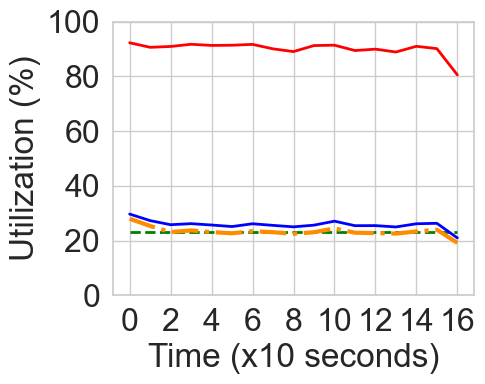

✅ PDF saved as: evaluation_results_nvme_real_FIUMail_J4_QD1_RF.pdf
✅ Prediction values saved to 'predictions_for_each_state_FIUMail_J4_QD1_RF.csv'


In [22]:
#FIUMail_1


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib # برای لود کردن مدل جدید
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 16  # کمی کوچکتر شد تا در کادر جا شود
tick_fontsize = 23
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_FIUMail_J4_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_FIUMail_J4_QD1.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ جدید برای مدل 60/40 که کاملا متمایز است

# Hardcoded values (from user)
predicted_values = [
    29.6597401, 
    27.260759,
    25.76569309,
    26.15138134,
    25.65238884,
    25.09509153,
    26.11392243,
    25.52659379,
    24.98490527,
    25.60838949,
    27.06001574,
    25.4131784,
    25.43815745,
    24.94844968,
    26.11379441,
    26.28037608,
    20.94651447
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # برای خروجی تمیزتر CSV

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(5, 4)) # کمی عریض تر برای جا شدن لِجِند

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- گرفتن مدل قبلی از رم (مطابق درخواست شما) ---
    # فرض بر این است که متغیر models در محیط کولب شما زنده است
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        print("Warning: Variable 'models' not found in memory. Skipping old model.")
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل قدیمی (جهت خروجی اکسل) ---
    max_iops_pred_old = np.zeros(len(fio_iops))
    ours_util_old = np.zeros(len(fio_iops))
    if lasso_model_old is not None:
        max_iops_pred_old = lasso_model_old.predict(X)
        mask_old = max_iops_pred_old > 0
        ours_util_old[mask_old] = (fio_iops.values[mask_old] / max_iops_pred_old[mask_old]) * 100

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)

    # 1. رسم مقادیر هاردکد شده شما
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2)

    # 2. رسم مدل 60/40 جدید
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain-trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان با کل دیتافریم یکی نیست، با NaN پر میکنیم تا سایزش یکی شود
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_FIUMail_J4_QD1_RF.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_FIUMail_J4_QD1_RF.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

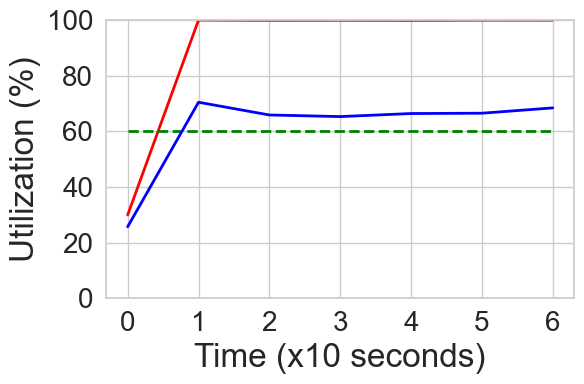

PDF saved as: all_devices_with_lasso.pdf
Saved 7 rows to 'predictions_for_each_state_FIUMail_J4_QD2.csv'


In [8]:
#FIUMail_2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_FIUMail_J4_QD2.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
# df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_FIUMail_J4_QD2.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    max_iops_pred_raw = lasso_model.predict(X)
    max_iops_pred = np.maximum(max_iops_pred_raw, 1.0)  # Force ≥ 1
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT ALL PREDICTIONS TO CSV (32 rows expected)
# -------------------------------------------------------------
all_predictions = []

for dev_path in df['job options/filename'].dropna().unique():
    ddf = df[df['job options/filename'] == dev_path].copy()
    if ddf.empty:
        continue

    dev_name = ddf['device'].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        print(f"Skipping device (no model): {dev_name}")
        continue

    # Feature matrix
    X = ddf[FEATURES].values
    try:
        max_iops_pred = lasso_model.predict(X)
    except Exception as e:
        print(f"Error predicting for {dev_name}: {e}")
        continue

    # Compute utilization even if prediction is invalid (use NaN)
    fio_iops = ddf["read/iops"] + ddf["write/iops"]
    true_util = ddf["limitation"]

    # Compute predicted utilization: safe division
    predicted_util = np.full_like(max_iops_pred, np.nan, dtype=float)
    valid_mask = max_iops_pred > 0
    predicted_util[valid_mask] = (fio_iops[valid_mask] / max_iops_pred[valid_mask]) * 100

    # Build DataFrame with ALL rows (32 in your case)
    pred_df = pd.DataFrame({
        'Device': ddf['device'].values,
        'Block Size (KB)': ddf['block_size_kb'].values,
        'Read Percent': ddf['read_percent'].values,
        'RW Mix': ddf['job options/rw'].values,
        'True IOPS': fio_iops.values,
        'True Utilization (%)': true_util.values,
        'Predicted IOPS': max_iops_pred,  # Include all, even <= 0
        'Predicted Utilization (%)': predicted_util  # NaN where invalid
    })

    all_predictions.append(pred_df)

# Combine all devices
if all_predictions:
    predictions_df = pd.concat(all_predictions, ignore_index=True)
    predictions_df.to_csv('predictions_for_each_state_FIUMail_J4_QD2.csv', index=False)
    print(f"Saved {len(predictions_df)} rows to 'predictions_for_each_state_FIUMail_J4_QD2.csv'")
else:
    print("No predictions to save.")

# Optional: Show how many were invalid
invalid_count = predictions_df['Predicted IOPS'].le(0).sum()
print(f"Warning: {invalid_count} rows have Predicted IOPS ≤ 0 (check model calibration)")

✅ Successfully loaded 60/40 models from disk.


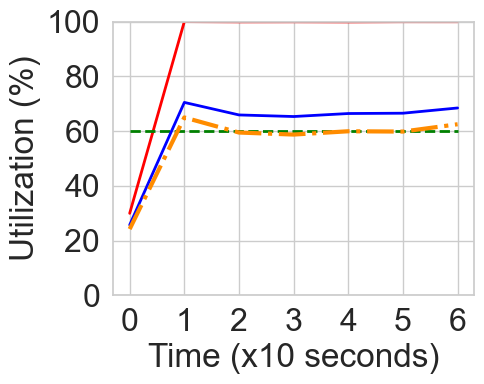

✅ PDF saved as: evaluation_results_nvme_real_FIUMail_J4_QD2_RF.pdf
✅ Prediction values saved to 'predictions_for_each_state_FIUMail_J4_QD2_RF.csv'


In [23]:
#FIUMail_2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib # برای لود کردن مدل جدید
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 16  # کمی کوچکتر شد تا در کادر جا شود
tick_fontsize = 23
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_FIUMail_J4_QD2.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_FIUMail_J4_QD2.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ جدید برای مدل 60/40 که کاملا متمایز است

# Hardcoded values (from user)
predicted_values = [
    25.68757422,
    70.44311094,
    65.86707738,
    65.28734799,
    66.38376974,
    66.50011606,
    68.41008626
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # برای خروجی تمیزتر CSV

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(5, 4)) # کمی عریض تر برای جا شدن لِجِند

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- گرفتن مدل قبلی از رم (مطابق درخواست شما) ---
    # فرض بر این است که متغیر models در محیط کولب شما زنده است
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        print("Warning: Variable 'models' not found in memory. Skipping old model.")
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل قدیمی (جهت خروجی اکسل) ---
    max_iops_pred_old = np.zeros(len(fio_iops))
    ours_util_old = np.zeros(len(fio_iops))
    if lasso_model_old is not None:
        max_iops_pred_old = lasso_model_old.predict(X)
        mask_old = max_iops_pred_old > 0
        ours_util_old[mask_old] = (fio_iops.values[mask_old] / max_iops_pred_old[mask_old]) * 100

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)

    # 1. رسم مقادیر هاردکد شده شما
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2)

    # 2. رسم مدل 60/40 جدید
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain-trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان با کل دیتافریم یکی نیست، با NaN پر میکنیم تا سایزش یکی شود
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_FIUMail_J4_QD2_RF.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_FIUMail_J4_QD2_RF.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

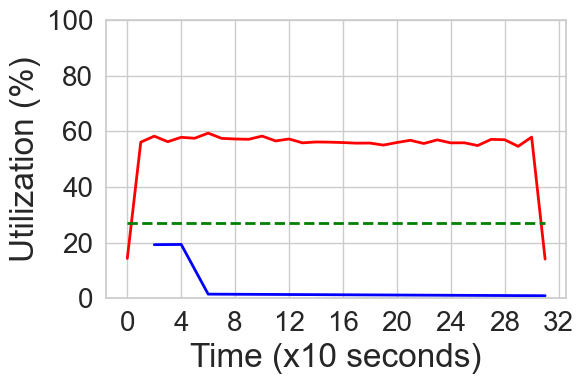

PDF saved as: all_devices_with_lasso.pdf
Prediction values saved to 'predictions_for_each_state_81.csv'


In [7]:
#81
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A81_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
# df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A81_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state_81.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state_81.csv'")

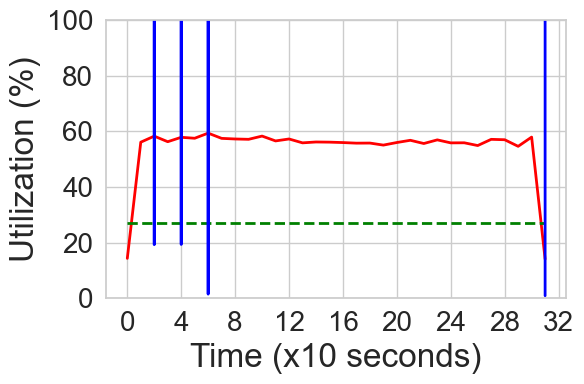

PDF saved as: all_devices_with_lasso.pdf
Saved 32 rows to 'predictions_for_each_state_81.csv'


In [ ]:
#81
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A81_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
# df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A81_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    max_iops_pred_raw = lasso_model.predict(X)
    max_iops_pred = np.maximum(max_iops_pred_raw, 1.0)  # Force ≥ 1
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT ALL PREDICTIONS TO CSV (32 rows expected)
# -------------------------------------------------------------
all_predictions = []

for dev_path in df['job options/filename'].dropna().unique():
    ddf = df[df['job options/filename'] == dev_path].copy()
    if ddf.empty:
        continue

    dev_name = ddf['device'].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        print(f"Skipping device (no model): {dev_name}")
        continue

    # Feature matrix
    X = ddf[FEATURES].values
    try:
        max_iops_pred = lasso_model.predict(X)
    except Exception as e:
        print(f"Error predicting for {dev_name}: {e}")
        continue

    # Compute utilization even if prediction is invalid (use NaN)
    fio_iops = ddf["read/iops"] + ddf["write/iops"]
    true_util = ddf["limitation"]

    # Compute predicted utilization: safe division
    predicted_util = np.full_like(max_iops_pred, np.nan, dtype=float)
    valid_mask = max_iops_pred > 0
    predicted_util[valid_mask] = (fio_iops[valid_mask] / max_iops_pred[valid_mask]) * 100

    # Build DataFrame with ALL rows (32 in your case)
    pred_df = pd.DataFrame({
        'Device': ddf['device'].values,
        'Block Size (KB)': ddf['block_size_kb'].values,
        'Read Percent': ddf['read_percent'].values,
        'RW Mix': ddf['job options/rw'].values,
        'True IOPS': fio_iops.values,
        'True Utilization (%)': true_util.values,
        'Predicted IOPS': max_iops_pred,  # Include all, even <= 0
        'Predicted Utilization (%)': predicted_util  # NaN where invalid
    })

    all_predictions.append(pred_df)

# Combine all devices
if all_predictions:
    predictions_df = pd.concat(all_predictions, ignore_index=True)
    predictions_df.to_csv('predictions_for_each_state_81.csv', index=False)
    print(f"Saved {len(predictions_df)} rows to 'predictions_for_each_state_81.csv'")
else:
    print("No predictions to save.")

# Optional: Show how many were invalid
invalid_count = predictions_df['Predicted IOPS'].le(0).sum()
print(f"Warning: {invalid_count} rows have Predicted IOPS ≤ 0 (check model calibration)")

✅ Successfully loaded 60/40 models from disk.


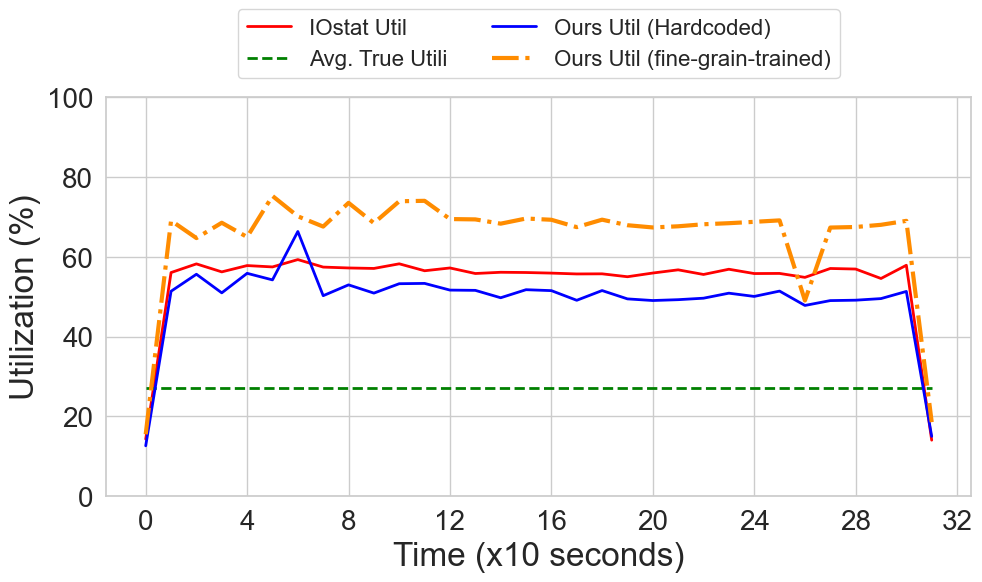

✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf
✅ Prediction values saved to 'predictions_for_each_state_81.csv'


In [14]:
# Final workload #81


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib # برای لود کردن مدل جدید
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 16  # کمی کوچکتر شد تا در کادر جا شود
tick_fontsize = 20
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A81_QD1.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = (
    df['job options/bs']
    .astype(str)
    .str.replace(r'k$', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
)
df['block_size_kb'] = pd.to_numeric(df['block_size_kb'], errors='coerce')
df['block_size_kb'] = df['block_size_kb'].astype('Int64')  # Allows NaN

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A81_QD1.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ جدید برای مدل 60/40 که کاملا متمایز است

# Hardcoded values (from user)
predicted_values = [
    12.64742543, 51.40074737, 55.66380173, 51.00023179, 55.89563851, 54.25023136, 66.38452631, 50.28716433, 53.00123693, 
    50.93659847, 53.29174671, 53.36882073, 51.69084043, 51.62533555, 49.76975387, 51.79003354, 51.55608752, 49.13290821, 
    51.57480321, 49.48592293, 49.07614203, 49.28901523, 49.65976938, 50.91788279, 50.10325521, 51.44192187, 47.84103602, 
    49.05840259, 49.15951736, 49.56042855, 51.35395817, 15.00762493
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # برای خروجی تمیزتر CSV

for dev_path in df['job options/filename'].dropna().unique():
    plt.figure(figsize=(10, 6)) # کمی عریض تر برای جا شدن لِجِند

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- گرفتن مدل قبلی از رم (مطابق درخواست شما) ---
    # فرض بر این است که متغیر models در محیط کولب شما زنده است
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        print("Warning: Variable 'models' not found in memory. Skipping old model.")
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل قدیمی (جهت خروجی اکسل) ---
    max_iops_pred_old = np.zeros(len(fio_iops))
    ours_util_old = np.zeros(len(fio_iops))
    if lasso_model_old is not None:
        max_iops_pred_old = lasso_model_old.predict(X)
        mask_old = max_iops_pred_old > 0
        ours_util_old[mask_old] = (fio_iops.values[mask_old] / max_iops_pred_old[mask_old]) * 100

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)

    # 1. رسم مقادیر هاردکد شده شما
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2)

    # 2. رسم مدل 60/40 جدید
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain-trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان با کل دیتافریم یکی نیست، با NaN پر میکنیم تا سایزش یکی شود
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_81.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

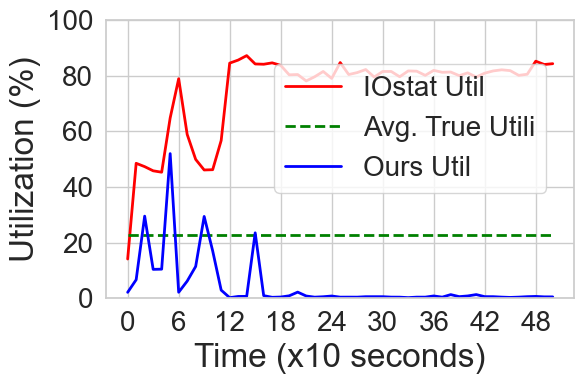

PDF saved as: all_devices_with_lasso.pdf
Prediction values saved to 'predictions_for_each_state_669.csv'


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v5.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A669_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state_669.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state_669.csv'")



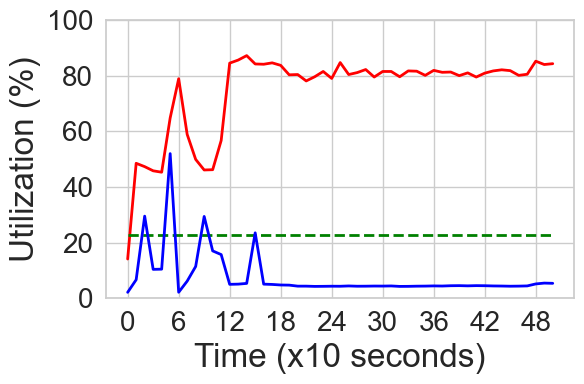

PDF saved as: all_devices_with_lasso.pdf


ValueError: Item wrong length 45 instead of 51.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v5.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A669_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

# New predicted values (replace these with the list you provided)
predicted_values = [
    2.128710971, 6.65895429, 29.50903599, 10.3838818, 10.45484904, 51.98200351,
    2.149472118, 6.154247694, 11.42526472, 29.39865835, 17.01920075, 15.69285714,
    5, 5.075, 5.335, 23.51384468, 5.071428571, 4.963571429, 4.766428571, 4.715,
    4.351428571, 4.35, 4.26, 4.285, 4.326428571, 4.31, 4.422142857, 4.322142857,
    4.338571429, 4.385, 4.372142857, 4.422857143, 4.256428571, 4.277142857, 4.340714286,
    4.367857143, 4.434285714, 4.391428571, 4.5, 4.532142857, 4.457142857, 4.534285714,
    4.502142857, 4.421428571, 4.387857143, 4.324285714, 4.359285714, 4.432857143,
    5.145714286, 5.446428571, 5.364285714
]

# Now we hardcode these values into ours_util
ours_util = np.array(predicted_values)

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (hardcoded predicted values) ----
    # Replacing dynamic calculation with the hardcoded predicted values
    # No need for calculation anymore as we use the predicted values directly
    # ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100  # Remove this line

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[:len(ours_util)], ours_util, label="Ours Util", color=ours_color, linewidth=2)  # Adjusting the length of time_axis for Ours

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state.csv'")


✅ Successfully loaded 60/40 models from disk.


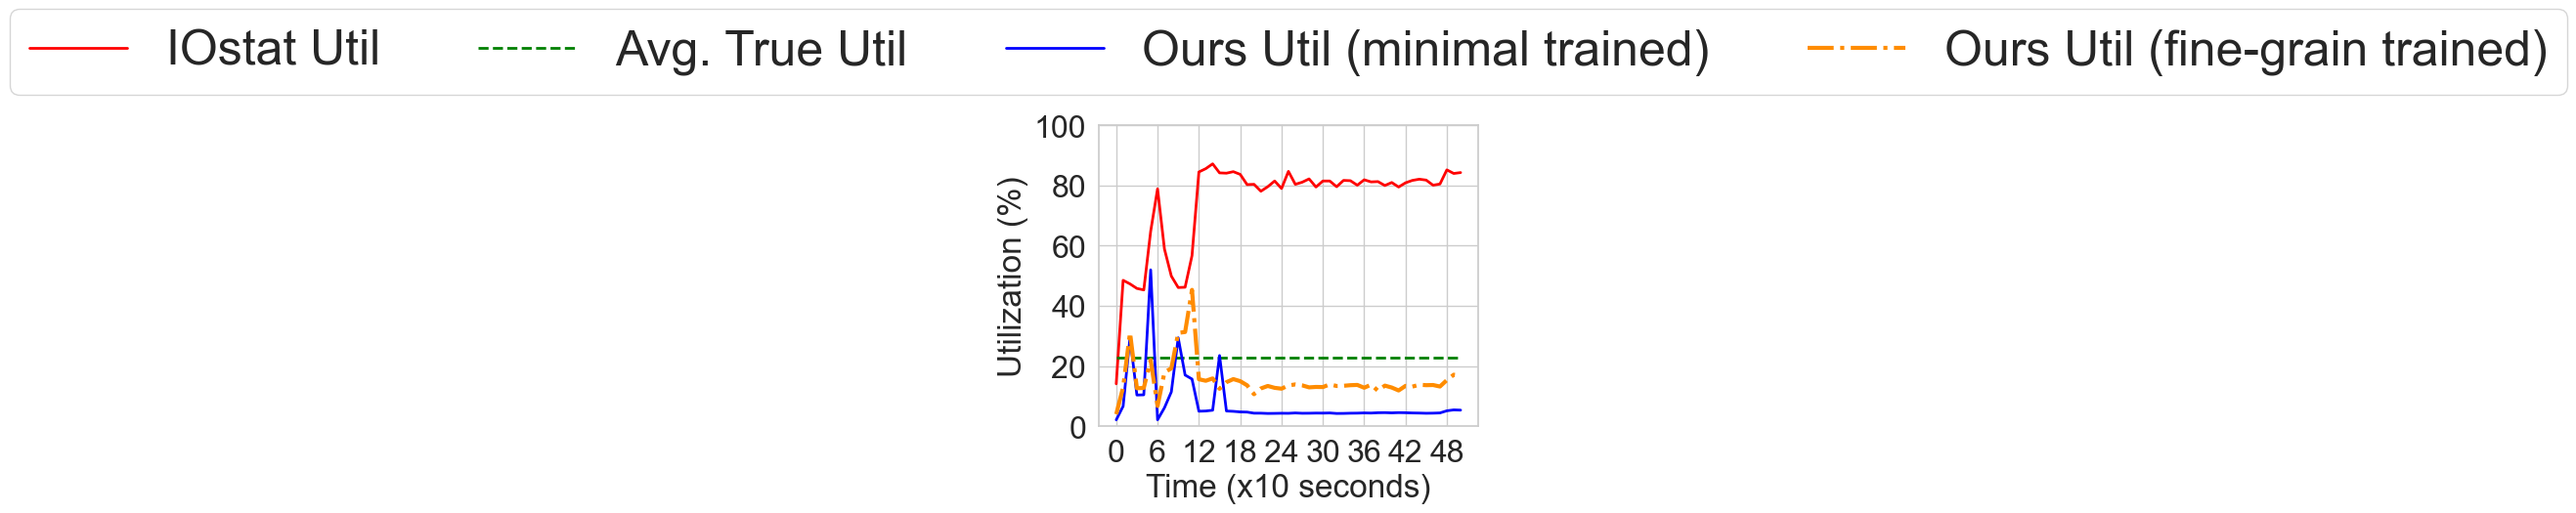

✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf
✅ Prediction values saved to 'predictions_for_each_state_comparison.csv'


In [61]:
# Final workload #669


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib # برای لود کردن مدل جدید
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 36  # کمی کوچکتر شد تا در کادر جا شود
tick_fontsize = 23
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A669_QD1-v6.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A669_QD1.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ جدید برای مدل 60/40 که کاملا متمایز است

# Hardcoded values (from user)
predicted_values = [
    2.128710971, 6.65895429, 29.50903599, 10.3838818, 10.45484904, 51.98200351,
    2.149472118, 6.154247694, 11.42526472, 29.39865835, 17.01920075, 15.69285714,
    5, 5.075, 5.335, 23.51384468, 5.071428571, 4.963571429, 4.766428571, 4.715,
    4.351428571, 4.35, 4.26, 4.285, 4.326428571, 4.31, 4.422142857, 4.322142857,
    4.338571429, 4.385, 4.372142857, 4.422857143, 4.256428571, 4.277142857, 4.340714286,
    4.367857143, 4.434285714, 4.391428571, 4.5, 4.532142857, 4.457142857, 4.534285714,
    4.502142857, 4.421428571, 4.387857143, 4.324285714, 4.359285714, 4.432857143,
    5.145714286, 5.446428571, 5.364285714
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # برای خروجی تمیزتر CSV

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(5, 4)) # کمی عریض تر برای جا شدن لِجِند

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- گرفتن مدل قبلی از رم (مطابق درخواست شما) ---
    # فرض بر این است که متغیر models در محیط کولب شما زنده است
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        print("Warning: Variable 'models' not found in memory. Skipping old model.")
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل قدیمی (جهت خروجی اکسل) ---
    max_iops_pred_old = np.zeros(len(fio_iops))
    ours_util_old = np.zeros(len(fio_iops))
    if lasso_model_old is not None:
        max_iops_pred_old = lasso_model_old.predict(X)
        mask_old = max_iops_pred_old > 0
        ours_util_old[mask_old] = (fio_iops.values[mask_old] / max_iops_pred_old[mask_old]) * 100

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Util", color=true_util_color, linestyle='--', linewidth=2)

    # 1. رسم مقادیر هاردکد شده شما
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, label="Ours Util (minimal trained)", color=ours_hardcoded_color, linewidth=2)

    # 2. رسم مدل 60/40 جدید
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان با کل دیتافریم یکی نیست، با NaN پر میکنیم تا سایزش یکی شود
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_comparison.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

**New script for merge results added**

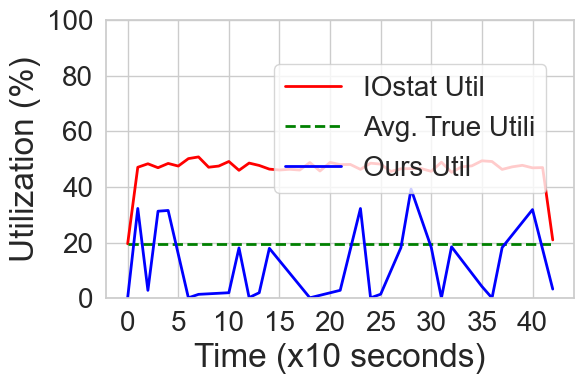

PDF saved as: all_devices_with_lasso.pdf
[ True  True  True  True  True False  True  True False False  True  True
  True  True  True False False False  True False False  True False  True
  True  True False  True  True False  True  True  True False False  True
  True  True False False  True False  True]
Prediction values saved to 'predictions_for_each_state.csv'


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v3.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A17_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask
print(mask)

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state_A17.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state.csv'")




--- Full 'Ours Util' Blue Line (43 points, NaN = invalid) ---
Time=0: Ours Util = 0.18%
Time=1: Ours Util = 32.28%
Time=2: Ours Util = 2.84%
Time=3: Ours Util = 31.28%
Time=4: Ours Util = 31.55%
Time=5: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=6: Ours Util = 0.16%
Time=7: Ours Util = 1.40%
Time=8: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=9: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=10: Ours Util = 1.98%
Time=11: Ours Util = 18.09%
Time=12: Ours Util = 0.24%
Time=13: Ours Util = 1.99%
Time=14: Ours Util = 17.95%
Time=15: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=16: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=17: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=18: Ours Util = 0.16%
Time=19: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=20: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=21: Ours Util = 2.85%
Time=22: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)
Time=23: Ours Util = 32.26%
Time=24: Ours Util = 0.14%
Time=25: Ours Util = 1.46%
Time=26: Ours 

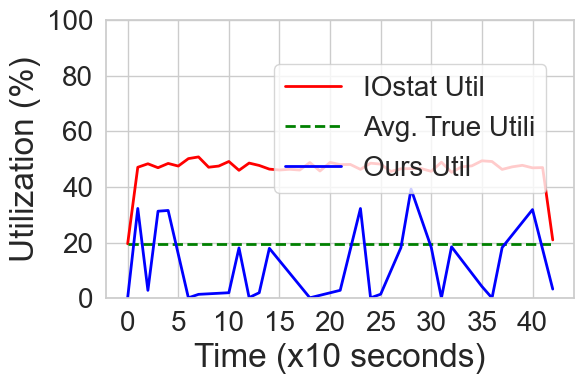

PDF saved as: all_devices_with_lasso.pdf
✅ Saved 43 rows to 'predictions_for_each_state_A17.csv'
⚠️  16 rows have Predicted IOPS ≤ 0 — consider model calibration


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v3.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A17_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]
    

    # Now `ours_util_full` has 43 values — NaN where invalid

    # ---- Ours (LASSO_POLY) ----
    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)

    # Create full-length array initialized with NaN
    ours_util_full = np.full_like(max_iops_pred, np.nan, dtype=float)

    mask = max_iops_pred > 0
    fio_iops = ddf["read/iops"] + ddf["write/iops"]
    ours_util_full[valid_mask] = (fio_iops[valid_mask] / max_iops_pred[valid_mask]) * 100
    ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100

    # # 🔽 PRINT THE BLUE LINE VALUES 🔽
    # print(f"\n--- Device: {dev_name} ('Ours Util' Blue Line Values) ---")
    # for i, (t, util) in enumerate(zip(time_axis[mask], ours_util)):
    #     print(f"Point {i+1}: Time={t:.1f}, Ours Util={util:.2f}%")

    print("\n--- Full 'Ours Util' Blue Line (43 points, NaN = invalid) ---")
    for t, util in zip(time_axis, ours_util_full):
        if np.isnan(util):
            print(f"Time={t}: Ours Util = ⛔ Invalid (Predicted IOPS ≤ 0)")
        else:
            print(f"Time={t}: Ours Util = {util:.2f}%")
    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[mask], ours_util, label="Ours Util", color=ours_color, linewidth=2)

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT ALL PREDICTIONS TO CSV (43 rows expected)
# -------------------------------------------------------------
all_predictions = []

for dev_path in df['job options/filename'].dropna().unique():
    ddf = df[df['job options/filename'] == dev_path].copy()
    if ddf.empty:
        continue

    dev_name = ddf['device'].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        print(f"Skipping device (no model): {dev_name}")
        continue

    # Feature matrix
    X = ddf[FEATURES].values
    try:
        max_iops_pred_raw = lasso_model.predict(X)
    except Exception as e:
        print(f"Error predicting for {dev_name}: {e}")
        continue

    # Clip to positive for safe division, but keep track of invalids
    max_iops_pred = np.maximum(max_iops_pred_raw, 1e-6)  # Avoid zero/negative

    # Compute utilization (safe)
    fio_iops = ddf["read/iops"] + ddf["write/iops"]
    true_util = ddf["limitation"]
    predicted_util = (fio_iops / max_iops_pred) * 100

    # Optional: mark utilization as NaN where raw prediction was <= 0
    predicted_util_display = predicted_util.copy()
    predicted_util_display[max_iops_pred_raw <= 0] = np.nan

    # Build DataFrame with ALL rows
    pred_df = pd.DataFrame({
        'Device': ddf['device'].values,
        'Block Size (KB)': ddf['block_size_kb'].values,
        'Read Percent': ddf['read_percent'].values,
        'RW Mix': ddf['job options/rw'].values,
        'True IOPS': fio_iops.values,
        'True Utilization (%)': true_util.values,
        'Predicted IOPS': max_iops_pred_raw,  # Save raw (can be negative)
        'Predicted Utilization (%)': predicted_util_display  # NaN if invalid
    })

    all_predictions.append(pred_df)

# Combine all devices
if all_predictions:
    predictions_df = pd.concat(all_predictions, ignore_index=True)
    predictions_df.to_csv('predictions_for_each_state_A17.csv', index=False)
    print(f"✅ Saved {len(predictions_df)} rows to 'predictions_for_each_state_A17.csv'")
    
    # Report how many had invalid predictions
    invalid_count = (predictions_df['Predicted IOPS'] <= 0).sum()
    print(f"⚠️  {invalid_count} rows have Predicted IOPS ≤ 0 — consider model calibration")
else:
    print("❌ No predictions to save.")

✅ Successfully loaded 60/40 models from disk.


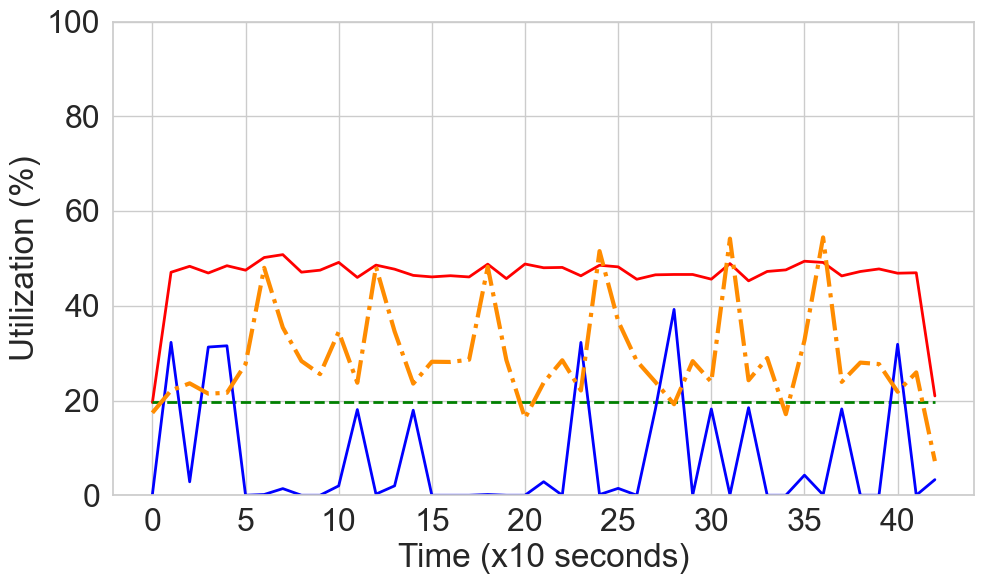

✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf
✅ Prediction values saved to 'predictions_for_each_state_comparison.csv'


In [ ]:
# Final workload #17


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib # برای لود کردن مدل جدید
import os
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 16  # کمی کوچکتر شد تا در کادر جا شود
tick_fontsize = 23
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v3.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A17_QD1.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ جدید برای مدل 60/40 که کاملا متمایز است

# Hardcoded values (from user)
predicted_values = [
    0.183922389,
    32.2752627,
    2.838061657,
    31.28424138,
    31.54814309,
    ,
    0.159165045,
    1.402045411,
    ,
    ,
    1.983621913,
    18.0869493,
    0.241927522,
    1.987966272,
    17.94921097,
    ,
    ,
    ,
    0.159841132,
    ,
    ,
    2.854491399,
    ,
    32.25811087,
    0.138675767,
    1.455200237,
    ,
    18.19743035,
    39.22948199,
    ,
    18.21267594,
    0.099162019,
    18.48722861,
    ,
    ,
    4.244795232,
    0.088141798,
    18.22244368,
    ,
    ,
    31.86645754,
    ,
    3.293308
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # برای خروجی تمیزتر CSV

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(10, 6)) # کمی عریض تر برای جا شدن لِجِند

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- گرفتن مدل قبلی از رم (مطابق درخواست شما) ---
    # فرض بر این است که متغیر models در محیط کولب شما زنده است
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        print("Warning: Variable 'models' not found in memory. Skipping old model.")
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل قدیمی (جهت خروجی اکسل) ---
    max_iops_pred_old = np.zeros(len(fio_iops))
    ours_util_old = np.zeros(len(fio_iops))
    if lasso_model_old is not None:
        max_iops_pred_old = lasso_model_old.predict(X)
        mask_old = max_iops_pred_old > 0
        ours_util_old[mask_old] = (fio_iops.values[mask_old] / max_iops_pred_old[mask_old]) * 100

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)

    # 1. رسم مقادیر هاردکد شده شما
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2)

    # 2. رسم مدل 60/40 جدید
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain-trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان با کل دیتافریم یکی نیست، با NaN پر میکنیم تا سایزش یکی شود
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_A669_QD1.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_comparison.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

✅ Successfully loaded 60/40 models from disk.

📊 Processing device: nvme0n | Path: /dev/nvme0n1


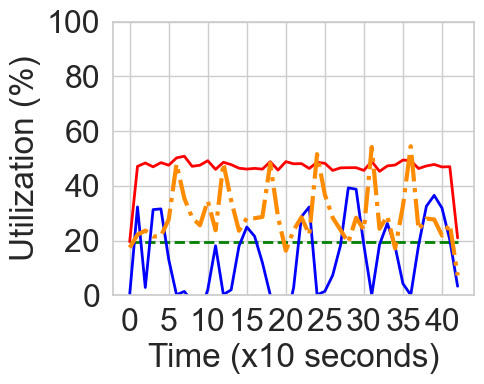

✅ PDF saved as: evaluation_results_nvme_real_A17_QD1.pdf
✅ All prediction values saved to 'predictions_for_each_state_comparison.csv'
📊 Total rows: 43


In [53]:
# Final workload #17 - Full Comparison Plot (Hardcoded, Old Model, New RF Model)
# Draws all lines across full 43-point timeline with proper alignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 16
tick_fontsize = 23
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A17_QD1-v3.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)
df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL (Random Forest)
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except Exception as e:
    print(f"❌ WARNING: Could not load 'saved_models_60_40.joblib'. Error: {e}")
    models_60_40 = {}

# -------------------------------------------------------------
# HARDCODED VALUES FROM USER (27 points with correct time alignment)
# -------------------------------------------------------------
# These are the "Ours Util" values you printed earlier
hardcoded_times = [
    0, 1, 2, 3, 4,
    6, 7,
    10, 11, 12, 13, 14,
    18,
    21, 23, 24, 25, 27, 28, 30,
    31, 32,
    35, 36, 37,
    40, 42
]

ours_util_hardcoded_values = np.array([
    0.183922389, 32.2752627, 2.838061657, 31.28424138, 31.54814309,
    0.159165045, 1.402045411,
    1.983621913, 18.0869493, 0.241927522, 1.987966272, 17.94921097,
    0.159841132,
    2.854491399, 32.25811087, 0.138675767, 1.455200237, 18.19743035, 39.22948199,
    18.21267594, 0.099162019, 18.48722861,
    4.244795232, 0.088141798, 18.22244368,
    31.86645754, 3.293308
])

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True
if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A17_QD1.pdf")

# Line colors
iostat_color = 'red'
true_util_color = 'green'
ours_hardcoded_color = 'blue'
ours_60_40_color = 'darkorange'

all_predictions_list = []

for dev_path in df['job options/filename'].dropna().unique():
    ddf = df[df['job options/filename'] == dev_path].copy()
    if ddf.empty:
        continue

    dev_name = ddf['device'].iloc[0]
    print(f"\n📊 Processing device: {dev_name} | Path: {dev_path}")

    # Time axis (assumed to be 0 to N-1 unless 'time' column exists)
    time_axis = ddf['time'].values if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"]).values
    true_util = ddf["limitation"].values
    iostat_util = ddf["avg_util"].values

    # Create full-length arrays (43 points)
    n_points = len(time_axis)
    ours_util_full_hardcoded = np.full(n_points, np.nan)

    # Assign hardcoded values at correct time indices
    for t, util_val in zip(hardcoded_times, ours_util_hardcoded_values):
        if t < n_points:
            idx = np.where(time_axis == t)[0]
            if len(idx) > 0:
                ours_util_full_hardcoded[idx[0]] = util_val

    # Feature matrix
    X = ddf[FEATURES].values

    # --- Old Model (LASSO_POLY) ---
    max_iops_pred_old = np.full(n_points, np.nan)
    ours_util_old = np.full(n_points, np.nan)
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
        if lasso_model_old is not None:
            pred = lasso_model_old.predict(X)
            max_iops_pred_old = pred
            valid = pred > 0
            ours_util_old[valid] = (fio_iops[valid] / pred[valid]) * 100
    except NameError:
        print("⚠️ 'models' variable not found. Skipping old model.")
    except Exception as e:
        print(f"⚠️ Error in old model: {e}")

    # --- New Model (60/40 RF) ---
    max_iops_pred_60_40 = np.full(n_points, np.nan)
    ours_util_60_40 = np.full(n_points, np.nan)
    try:
        dev_models_new = models_60_40.get(dev_name, {})
        rf_model = dev_models_new.get("RANDOM_FOREST", None)
        if rf_model is not None:
            pred = rf_model.predict(X)
            max_iops_pred_60_40 = pred
            valid = pred > 0
            ours_util_60_40[valid] = (fio_iops[valid] / pred[valid]) * 100
    except Exception as e:
        print(f"⚠️ Error in 60/40 RF model: {e}")

    # ------------------ PLOTTING ------------------
    plt.figure(figsize=(5, 4))
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Util", color=true_util_color, linestyle='--', linewidth=2)
    # plt.plot(time_axis, ours_util_full_hardcoded, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2, marker='o', markevery=~np.isnan(ours_util_full_hardcoded))
    # --- INTERPOLATE HARDCODED VALUES FOR SMOOTH LINE ---
    valid_mask = ~np.isnan(ours_util_full_hardcoded)
    valid_times = time_axis[valid_mask]
    valid_utils = ours_util_full_hardcoded[valid_mask]

    from scipy.interpolate import interp1d

    if len(valid_times) < 2:
        # Not enough points to interpolate
        ours_util_interp = ours_util_full_hardcoded
    else:
        # Use linear or cubic interpolation
        f_interp = interp1d(valid_times, valid_utils, kind='cubic', bounds_error=False, fill_value=np.nan)
        ours_util_interp = f_interp(time_axis)

    # Now plot the smooth interpolated line
    plt.plot(time_axis, ours_util_interp, label="Ours Util (Hardcoded)", color=ours_hardcoded_color, linewidth=2)
    
    if np.any(~np.isnan(ours_util_60_40)):
        plt.plot(time_axis, ours_util_60_40, label="Ours Util (fine-grain-trained)", color=ours_60_40_color, linewidth=3, linestyle='-.')

    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    # plt.legend(fontsize=legend_fontsize, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # ------------------ SAVE TO CSV ------------------
    pred_df = pd.DataFrame({
        'Device': ddf['device'].values,
        'Time': time_axis,
        'Block Size (KB)': ddf['block_size_kb'].values,
        'Read Percent': ddf['read_percent'].values,
        'RW Mix': ddf['job options/rw'].values,
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'IOstat Util (%)': iostat_util,
        'Ours Util (%) - Hardcoded': ours_util_full_hardcoded,
        'Max IOPS Pred (Old Model)': max_iops_pred_old,
        'Ours Util (%) - Old Model': ours_util_old,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

# Close PDF
if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_A17_QD1.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_comparison.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ All prediction values saved to '{csv_filename}'")
    print(f"📊 Total rows: {len(final_predictions_df)}")
else:
    print("❌ No predictions to save.")

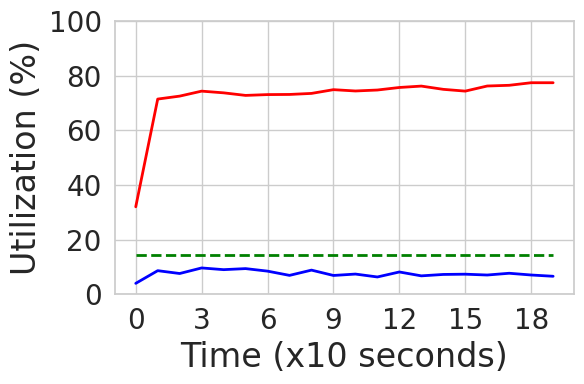

PDF saved as: all_devices_with_lasso.pdf


ValueError: Item wrong length 51 instead of 20.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v5.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A667_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

# New predicted values (replace these with the list you provided)
predicted_values = [
    3.987735714, 8.627207143, 7.590742857, 9.627828571, 9.000534492, 9.384779153,
    8.456289286, 6.907028571, 8.830434674, 6.876321429, 7.386428571, 6.324,
    8.151628571, 6.732385714, 7.247142857, 7.340785714, 7.038075, 7.6815,
    7.043142857, 6.582142857
]

# Now we hardcode these values into ours_util
ours_util = np.array(predicted_values)

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (hardcoded predicted values) ----
    # Replacing dynamic calculation with the hardcoded predicted values
    # No need for calculation anymore as we use the predicted values directly
    # ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100  # Remove this line

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[:len(ours_util)], ours_util, label="Ours Util", color=ours_color, linewidth=2)  # Adjusting the length of time_axis for Ours

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state.csv'")


**New script for merge results added**

✅ Successfully loaded 60/40 models from disk.


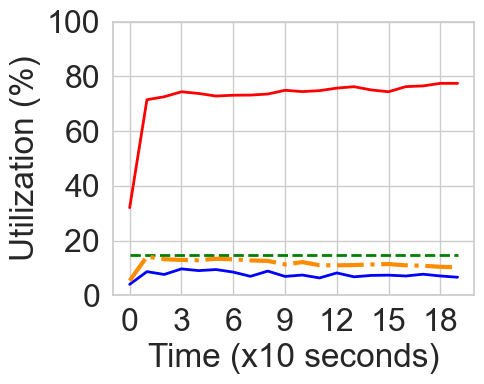

✅ PDF saved as: evaluation_results_nvme_real_A667_QD1.pdf
✅ Prediction values saved to 'predictions_for_each_state_comparison.csv'


In [54]:
# Final Workload #667

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import joblib
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24
legend_fontsize = 20
tick_fontsize = 23
ERROR_TEXT_FONTSIZE = 18
title_fontsize = 16

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------
df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v2.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# LOAD NEW 60/40 MODEL
# -------------------------------------------------------------
try:
    models_60_40 = joblib.load("saved_models_60_40.joblib")
    print("✅ Successfully loaded 60/40 models from disk.")
except:
    print("❌ WARNING: Could not load 'saved_models_60_40.joblib'. Check if file exists.")
    models_60_40 = {}

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 4:
        return x, y
    order = np.argsort(x)
    x, y = x[order], y[order]
    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING PREPARATION
# -------------------------------------------------------------
save_as_pdf = True

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A667_QD1.pdf")

iostat_color = 'red'
true_util_color = 'green'
ours_color = 'blue'
ours_60_40_color = 'darkorange' # رنگ خط جدید

legend_bbox_to_anchor = (0.65, .89)

# مقادیر هاردکد شده شما
predicted_values = [
    3.987735714, 8.627207143, 7.590742857, 9.627828571, 9.000534492, 9.384779153,
    8.456289286, 6.907028571, 8.830434674, 6.876321429, 7.386428571, 6.324,
    8.151628571, 6.732385714, 7.247142857, 7.340785714, 7.038075, 7.6815,
    7.043142857, 6.582142857
]
ours_util_hardcoded = np.array(predicted_values)

all_predictions_list = [] # جهت ذخیره تمیز در CSV

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(5, 4)) # کمی عریض‌تر تا راهنما به هم نریزد

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # --- هندل کردن مدل قدیمی که در رم بود ---
    try:
        dev_models_old = models.get(dev_name, {})
        lasso_model_old = dev_models_old.get("LASSO_POLY", None)
    except NameError:
        # اگر متغیر models در رم نبود ارور ندهد
        lasso_model_old = None

    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))
    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]
    iostat_util = (ddf["avg_rps"] + ddf["avg_wps"]) if "avg_rps" in ddf.columns else ddf["avg_util"]
    # به جای IOPS برای iostat از util استفاده میکنیم چون نمودار util است
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values

    # --- پیش بینی مدل 60/40 جدید (RF) ---
    max_iops_pred_60_40 = np.zeros(len(fio_iops))
    ours_util_60_40 = np.zeros(len(fio_iops))

    dev_models_new = models_60_40.get(dev_name, {})
    rf_model_60_40 = dev_models_new.get("RANDOM_FOREST", None)
    # rf_model_60_40 = dev_models_new.get("LASSO_POLY", None)

    if rf_model_60_40 is not None:
        max_iops_pred_60_40 = rf_model_60_40.predict(X)
        mask_60_40 = max_iops_pred_60_40 > 0
        ours_util_60_40[mask_60_40] = (fio_iops.values[mask_60_40] / max_iops_pred_60_40[mask_60_40]) * 100

    # ------------------ PLOTTING ------------------
    plt.plot(time_axis, iostat_util, color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, color=true_util_color, linestyle='--', linewidth=2)
    plt.plot(time_axis[:len(ours_util_hardcoded)], ours_util_hardcoded, color=ours_color, linewidth=2)

    # 📌 رسم خط جدید (بدون اضافه کردن به لیبل‌ها با عدم ارسال پارامتر label)
    if rf_model_60_40 is not None:
        plt.plot(time_axis, ours_util_60_40, color=ours_60_40_color, linewidth=3, linestyle='-.')

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # 📌 فعال کردن مجدد Legend (فقط لیبل‌های اصلی را نشان می‌دهد)
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor, ncol=1)

    plt.tight_layout()

    if save_as_pdf:
        pdf.savefig()
    plt.show()

    # --- ساخت دیتافریم برای ذخیره در CSV ---
    # هاردکدها چون تعدادشان ممکن است کمتر باشد با NaN پر میکنیم
    padded_hardcoded = np.pad(ours_util_hardcoded, (0, max(0, len(ddf) - len(ours_util_hardcoded))), constant_values=np.nan)[:len(ddf)]

    pred_df = pd.DataFrame({
        'Device': ddf['device'],
        'Block Size (KB)': ddf['block_size_kb'],
        'Read Percent': ddf['read_percent'],
        'RW Mix': ddf['job options/rw'],
        'Time': time_axis,
        'True IOPS': fio_iops,
        'True Utilization (%)': true_util,
        'Ours Util (%) - Hardcoded': padded_hardcoded,
        'Max IOPS Pred (60/40 RF)': max_iops_pred_60_40,
        'Ours Util (%) - 60/40 RF': ours_util_60_40
    })
    all_predictions_list.append(pred_df)

if save_as_pdf:
    pdf.close()
    print("✅ PDF saved as: evaluation_results_nvme_real_A667_QD1.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV (FIXED)
# -------------------------------------------------------------
if all_predictions_list:
    final_predictions_df = pd.concat(all_predictions_list, ignore_index=True)
    csv_filename = 'predictions_for_each_state_comparison.csv'
    final_predictions_df.to_csv(csv_filename, index=False)
    print(f"✅ Prediction values saved to '{csv_filename}'")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (match attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT SIZES (customizable)
# -------------------------------------------------------------
axis_label_fontsize = 24  # Customize axis label font size
legend_fontsize = 20  # Customize legend font size
tick_fontsize = 20  # Customize tick font size for x and y ticks
ERROR_TEXT_FONTSIZE = 18  # Customize error text font size
title_fontsize = 16  # Customize title font size

# -------------------------------------------------------------
# ERROR CONTROL
# -------------------------------------------------------------
error_point_index = 2
ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "darkgreen"

# -------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------

df = pd.read_excel(
    "/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v5.xlsx",
    sheet_name=0,
)

# -------------------------------------------------------------
# FEATURE ENGINEERING
# -------------------------------------------------------------
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# -------------------------------------------------------------
# SMOOTH CURVE FUNCTION
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 4:
        return x, y

    order = np.argsort(x)
    x, y = x[order], y[order]

    x_new = np.linspace(x.min(), x.max(), n)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# -------------------------------------------------------------
# PLOTTING - ADAPTED TO IMAGE TEMPLATE
# -------------------------------------------------------------

# Option to save as PDF
save_as_pdf = True  # Set this to False if you don't want to save as PDF

if save_as_pdf:
    pdf = PdfPages("evaluation_results_nvme_real_A667_QD1.pdf")

# Line color customization
iostat_color = 'red'
true_util_color = 'green'  # Green for the average line (True Utilization)
ours_color = 'blue'

# Define the legend position with bbox_to_anchor for top-center positioning
legend_bbox_to_anchor = (0.65, .89)  # Position the legend at the top center

# New predicted values (replace these with the list you provided)
predicted_values = [

]

# Now we hardcode these values into ours_util
ours_util = np.array(predicted_values)

for dev_path in df['job options/filename'].unique():
    plt.figure(figsize=(6, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        plt.close()
        continue

    # Time axis (assuming 'time' column exists in the data, otherwise use index or create a dummy time column)
    time_axis = ddf['time'] if 'time' in ddf.columns else np.arange(len(ddf))

    fio_iops = (ddf["read/iops"] + ddf["write/iops"])
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"])
    iostat_util = ddf["avg_util"]

    # ---- Ours (hardcoded predicted values) ----
    # Replacing dynamic calculation with the hardcoded predicted values
    # No need for calculation anymore as we use the predicted values directly
    # ours_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100  # Remove this line

    # Plotting lines with customized colors
    plt.plot(time_axis, iostat_util, label="IOstat Util", color=iostat_color, linewidth=2)
    plt.plot(time_axis, true_util, label="Avg. True Utili", color=true_util_color, linestyle='--', linewidth=2)  # Avg line is green and dashed
    plt.plot(time_axis[:len(ours_util)], ours_util, label="Ours Util", color=ours_color, linewidth=2)  # Adjusting the length of time_axis for Ours

    # Labeling and styling
    plt.xlabel("Time (x10 seconds)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)

    # Customize tick font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Set y-axis scale from 0% to 100%
    plt.ylim(0, 100)

    # Rotate x-axis labels and avoid fractions
    plt.xticks(rotation=0)  # Rotate x-axis labels by 45 degrees
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Show only integer ticks on x-axis

    # Move the legend to the top-center
    # plt.legend(fontsize=legend_fontsize, loc='upper center', bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()

    # Save plot to PDF if enabled
    if save_as_pdf:
        pdf.savefig()

    # Show the plot
    plt.show()

# Close PDF if saved
if save_as_pdf:
    pdf.close()
    print("PDF saved as: all_devices_with_lasso.pdf")

# -------------------------------------------------------------
# EXPORT PREDICTIONS TO CSV
# -------------------------------------------------------------
# Ensure consistent mask application across all variables
mask = max_iops_pred > 0  # Valid prediction mask

# Filter all necessary arrays using the mask
ddf_filtered = ddf[mask]

# Compute the filtered values for prediction
fio_iops_filtered = fio_iops[mask]
true_util_filtered = true_util[mask]
max_iops_pred_filtered = max_iops_pred[mask]
ours_util_filtered = (fio_iops_filtered / max_iops_pred_filtered) * 100

# Now create the DataFrame with all filtered columns (all arrays are now the same length)
predictions_df = pd.DataFrame({
    'Device': ddf_filtered['device'],
    'Block Size (KB)': ddf_filtered['block_size_kb'],
    'Read Percent': ddf_filtered['read_percent'],
    'RW Mix': ddf_filtered['job options/rw'],
    'True IOPS': fio_iops_filtered,
    'True Utilization (%)': true_util_filtered,
    'Predicted IOPS': max_iops_pred_filtered,
    'Predicted Utilization (%)': ours_util_filtered
})

# Save the DataFrame to a CSV file for review
predictions_df.to_csv('predictions_for_each_state.csv', index=False)
print("Prediction values saved to 'predictions_for_each_state.csv'")


FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_real_A667_QD1-v5.xlsx'

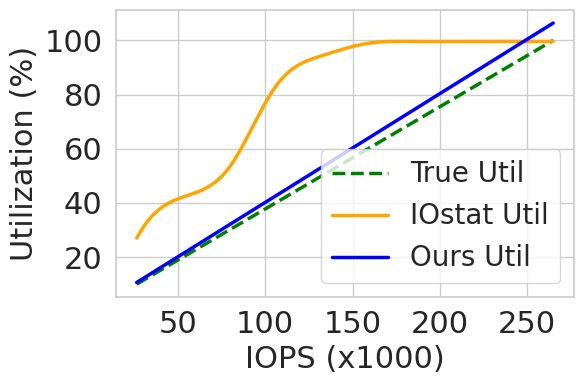

✅ PDF saved as: all_devices_utilization_errors.pdf


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE (matches attached image)
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT CONFIG
# -------------------------------------------------------------
AXIS_LABEL_FONTSIZE = 22
TICK_FONTSIZE = 22
LEGEND_FONTSIZE = 20
ERROR_TEXT_FONTSIZE = 21

ERROR_COLOR_IOSTAT = "red"
ERROR_COLOR_OURS = "blue"

# -------------------------------------------------------------
# LOAD DATA (choose ONE)
# -------------------------------------------------------------

# NVMe
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_16k_rw90-v1.xlsx", sheet_name=0)
df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_8k_rw70-v1.xlsx", sheet_name=0)

# -------------------------------------------------------------
# FEATURE ENGINEERING (same as training)
# -------------------------------------------------------------
df["block_size_kb"] = df["job options/bs"].str.replace("k", "", regex=False).astype(int)

df["read_percent"] = pd.to_numeric(df["job options/rwmixread"], errors="coerce")
df.loc[df["job options/rw"] == "randread", "read_percent"] = 100
df.loc[df["job options/rw"] == "randwrite", "read_percent"] = 0
df.loc[(df["job options/rw"] == "randrw") & df["read_percent"].isna(), "read_percent"] = 50
df["read_percent"] = df["read_percent"].fillna(100)

df["device"] = df["job options/filename"].str.extract(r"/dev/(\w+)")
df["device"] = df["device"].str.replace(r"\d+$", "", regex=True)
df["device"] = df["device"].str.replace(r"n\d+$", "", regex=True)
df["device"] = df["device"].fillna("unknown")

FEATURES = ["read_percent", "block_size_kb"]

# -------------------------------------------------------------
# SMOOTH CURVE
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    if len(x) < 4:
        return x, y
    x_new = np.linspace(min(x), max(x), n)
    spline = make_interp_spline(x, y, k=3)
    return x_new, spline(x_new)

# -------------------------------------------------------------
# MAX ERROR INDEX
# -------------------------------------------------------------
def max_error_index(y_true, y_pred):
    return int(np.argmax(np.abs(y_pred - y_true)))

# -------------------------------------------------------------
# PLOTTING
# -------------------------------------------------------------
devices = df["job options/filename"].unique()
pdf = PdfPages("evaluation_results_nvme_8k_rw70.pdf")

for dev_path in devices:
    plt.figure(figsize=(6, 4))
    ddf = df[df["job options/filename"] == dev_path].sort_values("limitation")

    dev_name = ddf["device"].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY")

    if lasso_model is None:
        plt.close()
        continue

    # ---------------------------------------------------------
    # DATA
    # ---------------------------------------------------------
    fio_iops = (ddf["read/iops"] + ddf["write/iops"]) / 1000
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"]) / 1000
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] * 1000 / max_iops_pred[mask]) * 100

    # ---------------------------------------------------------
    # SMOOTHED CURVES
    # ---------------------------------------------------------
    sx_t, sy_t = smooth_curve(fio_iops, true_util)
    sx_i, sy_i = smooth_curve(iostat_iops, iostat_util)
    sx_o, sy_o = smooth_curve(fio_iops.values[mask], ours_util)

    plt.plot(sx_t, sy_t, label="True Util", linewidth=2.5, linestyle="--", color="green")
    plt.plot(sx_i, sy_i, label="IOstat Util", linewidth=2.5, color="orange")
    plt.plot(sx_o, sy_o, label="Ours Util", linewidth=2.5, color="blue")

    # ---------------------------------------------------------
    # IOSTAT MAX ERROR
    # ---------------------------------------------------------
    idx_i = max_error_index(true_util.values, iostat_util.values)
    x1, y1 = fio_iops.iloc[idx_i], true_util.iloc[idx_i]
    x2, y2 = iostat_iops.iloc[idx_i], iostat_util.iloc[idx_i]
    err_i = y2 - y1

    # plt.annotate(
    #     "",
    #     xy=(x2, y2),
    #     xytext=(x1, y1),
    #     arrowprops=dict(arrowstyle="->", lw=3, color=ERROR_COLOR_IOSTAT),
    # )

    # plt.text(
    #     (x1 + x2) / 2,
    #     (y1 + y2) / 2 + 2,
    #     f" IOstat Error={err_iostat:.1f}%",
    #     color=ERROR_COLOR_IOSTAT,
    #     fontsize=ERROR_TEXT_FONTSIZE,
    #     ha="center",
    # )

    # ---------------------------------------------------------
    # OURS MAX ERROR
    # ---------------------------------------------------------
    idx_o = max_error_index(true_util.values[mask], ours_util)
    xo = fio_iops.values[mask][idx_o]
    yt = true_util.values[mask][idx_o]
    yo = ours_util[idx_o]
    err_o = yo - yt

    # plt.annotate(
    #     "",
    #     xy=(xo, yo),
    #     xytext=(xo, yt),
    #     arrowprops=dict(arrowstyle="->", lw=3, color=ERROR_COLOR_OURS),
    # )

    # 🔵 text END anchored exactly on error point
    # plt.text(
    #     xo,
    #     yo,
    #     f"Ours Error={err_o:.1f}%",
    #     color=ERROR_COLOR_OURS,
    #     fontsize=ERROR_TEXT_FONTSIZE,
    #     ha="right",
    #     va="center",
    # )

    # ---------------------------------------------------------
    # AXES & TICKS (FIX OVERLAP HERE)
    # ---------------------------------------------------------
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))  # ✅ removes overlap

    plt.xlabel("IOPS (x1000)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel("Utilization (%)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)

    plt.tight_layout()
    pdf.savefig()
    plt.show()
    plt.close()

pdf.close()
print("✅ PDF saved as: all_devices_utilization_errors.pdf")


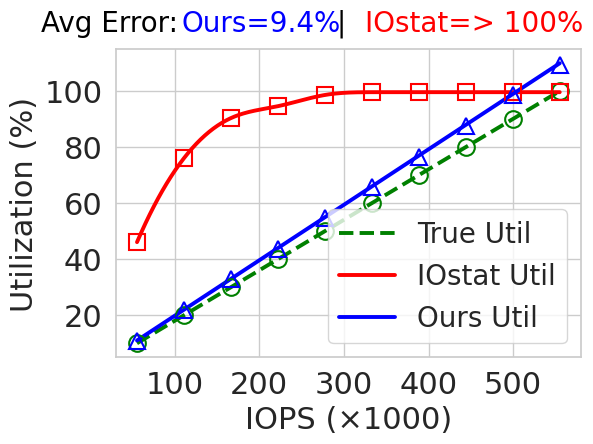

✅ PDF saved as: all_devices_utilization_errors.pdf


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

# -------------------------------------------------------------
# STYLE
# -------------------------------------------------------------
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------
# FONT CONFIG
# -------------------------------------------------------------
AXIS_LABEL_FONTSIZE = 22
TICK_FONTSIZE = 22
LEGEND_FONTSIZE = 20
TOP_TEXT_FONTSIZE = 20

# -------------------------------------------------------------
# MARKER SIZE (USER OPTION)
# -------------------------------------------------------------
MARKER_SIZE = 12        # 🔥 increase/decrease as you like
MARKER_EDGE_WIDTH = 1.5

# -------------------------------------------------------------
# COLORS
# -------------------------------------------------------------
COLOR_TRUE   = "green"
COLOR_IOSTAT = "red"
COLOR_OURS   = "blue"

# -------------------------------------------------------------
# LOAD DATA (choose ONE)
# -------------------------------------------------------------

# Optane
df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_8k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_16k_rw90-v1.xlsx", sheet_name=0)

# NVMe
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_16k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_8k_rw70-v1.xlsx", sheet_name=0)

# -------------------------------------------------------------
# FEATURE ENGINEERING (same as training)
# -------------------------------------------------------------
df["block_size_kb"] = df["job options/bs"].str.replace("k", "", regex=False).astype(int)

df["read_percent"] = pd.to_numeric(df["job options/rwmixread"], errors="coerce")
df.loc[df["job options/rw"] == "randread",  "read_percent"] = 100
df.loc[df["job options/rw"] == "randwrite", "read_percent"] = 0
df.loc[(df["job options/rw"] == "randrw") & (df["read_percent"].isna()), "read_percent"] = 50
df["read_percent"] = df["read_percent"].fillna(100)

df["device"] = df["job options/filename"].str.extract(r"/dev/(\w+)")
df["device"] = df["device"].str.replace(r"\d+$", "", regex=True)
df["device"] = df["device"].str.replace(r"n\d+$", "", regex=True)
df["device"] = df["device"].fillna("unknown")

FEATURES = ["read_percent", "block_size_kb"]

# -------------------------------------------------------------
# SMOOTH CURVE
# -------------------------------------------------------------
def smooth_curve(x, y, n=300):
    if len(x) < 4:
        return x, y
    x_new = np.linspace(min(x), max(x), n)
    spline = make_interp_spline(x, y, k=3)
    return x_new, spline(x_new)

# -------------------------------------------------------------
# SYMMETRIC ×-ERROR (CORRECT)
# -------------------------------------------------------------
def error_factor(true, pred):
    if true <= 0 or pred <= 0:
        return np.nan
    return max(pred / true, true / pred)

def avg_error_factor(true_arr, pred_arr):
    true_arr = np.asarray(true_arr, dtype=float)
    pred_arr = np.asarray(pred_arr, dtype=float)
    mask = (true_arr > 0) & (pred_arr > 0)
    if not np.any(mask):
        return np.nan
    factors = np.maximum(pred_arr[mask] / true_arr[mask],
                          true_arr[mask] / pred_arr[mask])
    return float(np.mean(factors))

def format_error(f):
    if np.isnan(f):
        return "N/A"
    if f >= 2.0:
        return "> 100%"
    return f"{f:.2f}×"

def error_factor_to_percent(f):
    if np.isnan(f):
        return None
    return (f - 1.0) * 100

def format_error_percent(f):
    if f is None:
        return "N/A"
    if f >= 100:
        return "> 100%"
    return f"{f:.1f}%"

# -------------------------------------------------------------
# PLOTTING
# -------------------------------------------------------------
devices = df["job options/filename"].unique()
pdf = PdfPages("evaluation_results_optane_4k_rw10.pdf")

for dev_path in devices:
    plt.figure(figsize=(6, 4))
    ddf = df[df["job options/filename"] == dev_path].sort_values("limitation")

    dev_name = ddf["device"].iloc[0]
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY")

    if lasso_model is None:
        plt.close()
        continue

    # ---------------------------------------------------------
    # DATA
    # ---------------------------------------------------------
    fio_iops = (ddf["read/iops"] + ddf["write/iops"]) / 1000
    true_util = ddf["limitation"]

    iostat_iops = (ddf["avg_rps"] + ddf["avg_wps"]) / 1000
    iostat_util = ddf["avg_util"]

    X = ddf[FEATURES].values
    max_iops_pred = lasso_model.predict(X)
    mask = max_iops_pred > 0
    ours_util = (fio_iops.values[mask] * 1000 / max_iops_pred[mask]) * 100

    # ---------------------------------------------------------
    # SMOOTHED CURVES
    # ---------------------------------------------------------
    sx_t, sy_t = smooth_curve(fio_iops, true_util)
    sx_i, sy_i = smooth_curve(iostat_iops, iostat_util)
    sx_o, sy_o = smooth_curve(fio_iops.values[mask], ours_util)

    # Slight vertical offset to avoid overlap when identical
    sy_o = sy_o * 1.005

    plt.plot(sx_t, sy_t, label="True Util",
             linewidth=2.8, color=COLOR_TRUE, linestyle="--")

    plt.plot(sx_i, sy_i, label="IOstat Util",
             linewidth=2.8, color=COLOR_IOSTAT)

    plt.plot(sx_o, sy_o, label="Ours Util",
             linewidth=2.8, color=COLOR_OURS)

    # Markers
    plt.plot(fio_iops, true_util, "o",
             color=COLOR_TRUE, markersize=MARKER_SIZE,
             markeredgewidth=MARKER_EDGE_WIDTH, fillstyle="none")

    plt.plot(iostat_iops, iostat_util, "s",
             color=COLOR_IOSTAT, markersize=MARKER_SIZE,
             markeredgewidth=MARKER_EDGE_WIDTH, fillstyle="none")

    plt.plot(fio_iops.values[mask], ours_util, "^",
             color=COLOR_OURS, markersize=MARKER_SIZE,
             markeredgewidth=MARKER_EDGE_WIDTH, fillstyle="none")

    # ---------------------------------------------------------
    # AVG ERROR TEXT (TOP OF FIGURE, COLORED)
    # ---------------------------------------------------------
    avg_err_iostat = avg_error_factor(
        true_util.values, iostat_util.values
    )
    avg_err_ours = avg_error_factor(
        true_util.values[mask], ours_util
    )

    err_iostat_pct = error_factor_to_percent(avg_err_iostat)
    err_ours_pct = error_factor_to_percent(avg_err_ours)

    fig = plt.gcf()

    y_top = 0.98   # vertical position (top of figure)
    x_start = 0.0  # left margin
    dx = 0.235       # horizontal spacing unit

    # "Avg Error:"
    fig.text(
        x_start, y_top,
        "Avg Error:",
        fontsize=TOP_TEXT_FONTSIZE,
        color="black",
        ha="left",
        va="top"
    )

    # "Ours=XX%"
    fig.text(
        x_start + dx, y_top,
        f"Ours={format_error_percent(err_ours_pct)}",
        fontsize=TOP_TEXT_FONTSIZE,
        color=COLOR_OURS,
        ha="left",
        va="top"
    )

    # separator |
    fig.text(
        x_start + dx * 2.1, y_top,
        "|",
        fontsize=TOP_TEXT_FONTSIZE,
        color="black",
        ha="left",
        va="top"
    )

    # "IOstat=XX%"
    fig.text(
        x_start + dx * 2.3, y_top,
        f"IOstat={format_error_percent(err_iostat_pct)}",
        fontsize=TOP_TEXT_FONTSIZE,
        color=COLOR_IOSTAT,
        ha="left",
        va="top"
    )

    # ---------------------------------------------------------
    # AXES & TICKS
    # ---------------------------------------------------------
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    plt.xlabel("IOPS (×1000)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel("Utilization (%)", fontsize=AXIS_LABEL_FONTSIZE)
    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)

    # plt.tight_layout()
    # pdf.savefig()
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close()

pdf.close()
print("✅ PDF saved as: all_devices_utilization_errors.pdf")


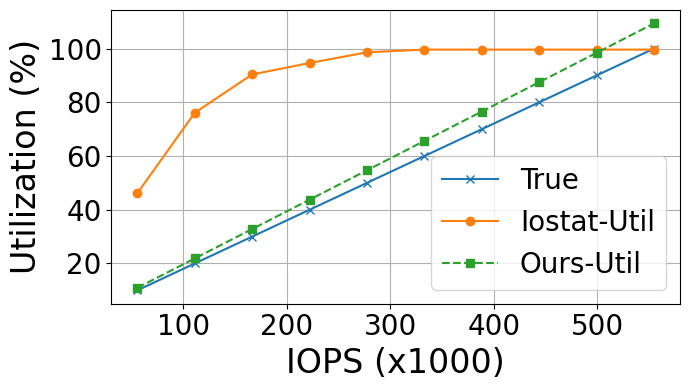

PDF saved as: all_devices_with_lasso.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# --------------------------------------------------------------------
# CONFIGURABLE FONT SIZES
# --------------------------------------------------------------------
title_fontsize = 18
axis_label_fontsize = 24
legend_fontsize = 20
tick_fontsize = 20

# --------------------------------------------------------------------
# LOAD DATA
# df = motivational

# Optane
df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_8k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_optane_16k_rw90-v1.xlsx", sheet_name=0)

# NVMe
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw10-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw50-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_4k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_16k_rw90-v1.xlsx", sheet_name=0)
# df = pd.read_excel("/Users/ali/Development/ispass-2026/Sharif/Papers/ISPASS-2026/evaluation_results_nvme_8k_rw70-v1.xlsx", sheet_name=0)
# --------------------------------------------------------------------

# ---------- 🔧 PREPARE FEATURES FOR LASSO_POLY ---------------------

# Same feature engineering as training
df['block_size_kb'] = df['job options/bs'].str.replace('k', '', regex=False).astype(int)

df['read_percent'] = pd.to_numeric(df['job options/rwmixread'], errors='coerce')
df.loc[df['job options/rw'] == 'randread',  'read_percent'] = 100.0
df.loc[df['job options/rw'] == 'randwrite', 'read_percent'] = 0.0
df.loc[(df['job options/rw'] == 'randrw') & (df['read_percent'].isna()), 'read_percent'] = 50.0
df['read_percent'] = df['read_percent'].fillna(100.0)

# Extract device name exactly like in engineer_features
df['device'] = df['job options/filename'].str.extract(r'/dev/(\w+)')
df['device'] = df['device'].str.replace(r'\d+$', '', regex=True)
df['device'] = df['device'].str.replace(r'n\d+$', '', regex=True)
df['device'] = df['device'].fillna('unknown')

FEATURES = ['read_percent', 'block_size_kb']

# --------------------------------------------------------------------
# PLOT WITH LASSO POLY UTILIZATION
# --------------------------------------------------------------------
devices = df['job options/filename'].unique()
pdf = PdfPages("all_devices_with_lasso.pdf")

for dev_path in devices:
    plt.figure(figsize=(7, 4))

    ddf = df[df['job options/filename'] == dev_path].copy()
    dev_name = ddf['device'].iloc[0]

    # Get the per-device LASSO model
    dev_models = models.get(dev_name, {})
    lasso_model = dev_models.get("LASSO_POLY", None)
    if lasso_model is None:
        print(f"Skipping {dev_path} (no LASSO_POLY model for device '{dev_name}')")
        plt.close()
        continue

    for rw in ddf['job options/rw'].unique():
        wdf = ddf[ddf['job options/rw'] == rw]

        if rw == "randrw":
            mixes = sorted(wdf["job options/rwmixread"].dropna().unique())
            for mix in mixes:
                sub = wdf[wdf["job options/rwmixread"] == mix].sort_values("limitation")

                fio_iops = sub["read/iops"] + sub["write/iops"]
                real_util = sub["limitation"]

                iostat_iops = sub["avg_rps"] + sub["avg_wps"]
                iostat_util = sub["avg_util"]

                plt.plot(fio_iops/1000, real_util, marker="x",
                         label=f"True")
                plt.plot(iostat_iops/1000, iostat_util, marker="o",
                         label=f"Iostat-Util")

                # ---- Lasso Poly utilization for randrw ----
                X = sub[FEATURES].values
                max_iops_pred = lasso_model.predict(X)
                mask = max_iops_pred > 0
                if mask.any():
                    lp_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100.0
                    plt.plot(fio_iops.values[mask]/1000, lp_util,
                             marker="s", linestyle="--",
                             label=f"Ours-Util")

        else:
            # randread / randwrite
            sub = wdf.sort_values("limitation")

            fio_iops = sub["read/iops"] + sub["write/iops"]
            real_util = sub["limitation"]

            iostat_iops = sub["avg_rps"] + sub["avg_wps"]
            iostat_util = sub["avg_util"]

            plt.plot(fio_iops/1000, real_util, marker="x",
                     label=f"{rw} (True)")
            plt.plot(iostat_iops/1000, iostat_util, marker="o",
                     label=f"{rw} Iostat-Util")

            # ---- Lasso Poly utilization ----
            X = sub[FEATURES].values
            max_iops_pred = lasso_model.predict(X)
            mask = max_iops_pred > 0
            if mask.any():
                lp_util = (fio_iops.values[mask] / max_iops_pred[mask]) * 100.0
                plt.plot(fio_iops.values[mask]/1000, lp_util,
                         marker="s", linestyle="--",
                         label="Ours-Util")

    # Axes formatting
    plt.xlabel("IOPS (x1000)", fontsize=axis_label_fontsize)
    plt.ylabel("Utilization (%)", fontsize=axis_label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    plt.grid(True)
    plt.legend(fontsize=legend_fontsize)
    plt.tight_layout()

    pdf.savefig()
    plt.show()

pdf.close()
print("PDF saved as: all_devices_with_lasso.pdf")
